In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.lib.stride_tricks import sliding_window_view

def calc_cyclic_mean(data, nyear, yearlyNt, shape_rest, smooth,smooth_window=1):
    # data [time spatials]
    c_mean = np.mean(data[:nyear*yearlyNt].reshape(nyear, yearlyNt, *shape_rest), axis=0)
    if smooth == 1:
        c_mean = cyclic_smooth_modern(c_mean, smooth_window)
    return c_mean


def calc_cyclic_mean2(data, yearlyNt, shape_rest, smooth, smooth_window=1):
    # 此方法考虑了不足一个cycle的数据，但会导致气候态不一致而引入误差
    """
    data: [time, spatials]
    nyear: 完整年份数
    yearlyNt: 每年的时间步数
    """
    total_nt = data.shape[0]
    
    # 1. 计算实际需要的总行数（向上取整的年份）
    # 比如 12年零3天，nyear_eff 就是 13
    nyear_eff = int(np.ceil(total_nt / yearlyNt))
    
    # 2. 构建一个能够容纳所有数据的标准矩阵，未填充部分设为 NaN
    # 形状为 (nyear_eff, yearlyNt, *spatials)
    # 这样可以自动处理“最后一年不完整”的情况
    full_shape = (nyear_eff * yearlyNt, *shape_rest)
    padded_data = np.full(full_shape, np.nan)
    
    # 将原始数据填入
    padded_data[:total_nt] = data
    
    # 3. Reshape 并计算忽略 NaN 的平均值
    # 这比手动 concatenate 要快且不容易出错
    c_reshape = padded_data.reshape(nyear_eff, yearlyNt, *shape_rest)
    c_mean = np.nanmean(c_reshape, axis=0)
    
    # 4. 周期性平滑
    if smooth == 1:
        c_mean = cyclic_smooth_modern(c_mean, smooth_window)
        
    return c_mean

    
# Handle remainders
def handle_remainder(full_data, cyclic_data, ntotal):
    # data [time spatials]

    if ntotal > full_data.shape[0]:
        diff = ntotal - full_data.shape[0]
        return np.concatenate([full_data, cyclic_data[:diff]], axis=0)
    return full_data

def cyclic_smooth_modern(data, window):
    # data [time spatials]
    if window <= 1: return data
    pad_size = window // 2
    padding = [(0, 0)] * data.ndim
    padding[0] = (pad_size, pad_size)
    padded = np.pad(data, padding, mode='wrap')
    windows = sliding_window_view(padded, window, axis=0)
    return np.mean(windows, axis=-1)

def cal_cyclic_mean_pure(data, nyear, yearlyNt, shape_rest, smooth=0,smooth_window=1):
    # data [time spatials]

    ntotal = data.shape[0]
    datac = calc_cyclic_mean(data, nyear, yearlyNt, shape_rest, smooth, smooth_window)
    rep = (nyear,) + (1,) * len(shape_rest)
    datac_pure = np.tile(datac, rep)
    datac_pure = handle_remainder(datac_pure, datac, ntotal)
    return datac_pure

def get_trend_info(data,dt):
    # data [time spatials]
    nt = data.shape[0]
    t = np.arange(nt) * dt
    data_2d = data.reshape(nt, -1)
    coeffs = np.polyfit(t, data_2d, 1)
    trend_full = (coeffs[0] * t[:, np.newaxis] + coeffs[1]).reshape(data.shape)
    return trend_full

def compute_running_climatology_fast(data, yearlyNt, window_years=10):
    ntotal = data.shape[0]
    nyear_full = ntotal // yearlyNt  # 8000 // 200 = 40
    shape_rest = data.shape[1:]
    
    # 1. 整理整年数据: (40, 200, 2001)
    reshaped = data[:nyear_full*yearlyNt].reshape(nyear_full, yearlyNt, *shape_rest)
    
    # 2. 准备填充
    half_w = window_years // 2 # 10年则为 5
    
    # 在年份轴(axis 0)进行填充: (50, 200, 2001)
    padded = np.pad(reshaped, ((half_w, half_w), (0, 0)) + ((0, 0),)*len(shape_rest), mode='edge')
    
    # 3. 滑动窗口视图 
    # 注意：我们只在 axis 0 上滑动
    # windows 形状: (nyear_full + 2*half_w - window_years + 1, 200, 2001, window_years)
    # 对于 40年, 窗口10年: 40 + 10 - 10 + 1 = 41
    # 这就是多出来的来源！
    windows = sliding_window_view(padded, window_shape=window_years, axis=0)
    
    # 4. 求均值并严格截取中心年份
    # 我们只需要前 nyear_full 个窗口
    mean_reshaped = np.mean(windows, axis=-1)[:nyear_full, ...] # <--- 核心修复：强制截断到 40
    
    # 5. 还原为时间轴: (8000, 2001)
    mean_full = mean_reshaped.reshape(-1, *shape_rest)
    
    # 6. 处理第 8001 点 (相位 0)
    if ntotal > mean_full.shape[0]:
        diff = ntotal - mean_full.shape[0]
        # 取平均后的矩阵中，最后一年的对应相位 (即相位0)
        tail = mean_reshaped[-1, :diff, ...] 
        mean_full = np.concatenate([mean_full, tail], axis=0)
        
    return mean_full
    

(8001, 2001)

In [3]:
# Time grid
dt = 0.005
t_max = 41
t = np.arange(1, t_max, dt)
t = np.concatenate((t, [t[-1]+dt] ))


omega1 = 2*np.pi
omega2 = 2*np.pi/2.7     #### original  3
warming_rate_annual = 0.25

a1 = 1.
a2 = 1.
c  = 5.

yearlyNt = int(2*np.pi/omega1/dt)   # timesteps per year
nyear = int(len(t)/yearlyNt)       # number of years

ntotal = len(t)
if yearlyNt is None:
    yearlyNt = ntotal // nyear


T = a1*np.sin(omega1*t) + a2*np.sin(omega2*t) + warming_rate_annual*t + c
Tdot = a1*omega1*np.cos(omega1*t) + a2*omega2*np.cos(omega2*t) + warming_rate_annual
Tdotdaily = (T[1:] - T[0:-1])/dt



# detrend polyfit  wrong way 
Tbar = (T[-1]-T[0])/(t[-1]-t[0])
Ttrend_fit= get_trend_info(T, dt)    
Tdotdailytrend = get_trend_info(Tdotdaily, dt)    

#detrend correct ！！！
Ttrend = Tbar*(t-t[0]) 




## T anom
Twave = T - Ttrend   # detrend
#Twave = T - Tbar*t    

shape_rest = T.shape[1:] 
Twavebar = calc_cyclic_mean(Twave, nyear, yearlyNt, shape_rest, smooth=0, smooth_window=1)
Twavebar_pure = cal_cyclic_mean_pure(Twave, nyear, yearlyNt, shape_rest, smooth=0)
Tanom = Twave - Twavebar_pure

## dTdt
dTadt =  (Tanom[1:] - Tanom[0:-1])/dt

## Tdot anom
#Tdotwave = Tdot - np.mean(Tdot)
#Tdotwave = Tdotdaily - np.mean(Tdotdaily)
Tdotwave = Tdotdaily - Tdotdailytrend  # detrend

Tdotwavebar = calc_cyclic_mean(Tdotwave, nyear, yearlyNt, shape_rest, smooth=0, smooth_window=1)
Tdotwavebar_pure = cal_cyclic_mean_pure(Tdotwave, nyear, yearlyNt, shape_rest, smooth=0)
Tdotanom = Tdotwave - Tdotwavebar_pure

In [4]:
T_bar_pure = cal_cyclic_mean_pure(T, nyear, yearlyNt, shape_rest, smooth=0)
Tanom = T - T_bar_pure
dTadt =  (Tanom[1:] - Tanom[0:-1])/dt
dT_bardt =  (T_bar_pure[1:] - T_bar_pure[0:-1])/dt

dTdt = (T[1:] - T[0:-1])/dt
dTdt_bar_pure = cal_cyclic_mean_pure(dTdt, nyear, yearlyNt, shape_rest, smooth=0)
dTdt_anom = dTdt - dTdt_bar_pure

Trend_bar_pure = cal_cyclic_mean_pure(Ttrend, nyear, yearlyNt, shape_rest, smooth=0)
Ttrend_anom = Ttrend - Trend_bar_pure
datbardt = (Trend_bar_pure[1:] - Trend_bar_pure[0:-1])/dt
datanomdt = (Ttrend_anom[1:] - Ttrend_anom[0:-1])/dt
Trendbar_bar_pure = cal_cyclic_mean_pure(datbardt, nyear, yearlyNt, shape_rest, smooth=0)
Trendanom_bar_pure = cal_cyclic_mean_pure(datanomdt, nyear, yearlyNt, shape_rest, smooth=0)

dTtrenddt = (Ttrend[1:] - Ttrend[0:-1])/dt
dTtrenddt_bar_pure = cal_cyclic_mean_pure(dTtrenddt, nyear, yearlyNt, shape_rest, smooth=0)
dTtrenddt_anom = dTtrenddt - dTtrenddt_bar_pure


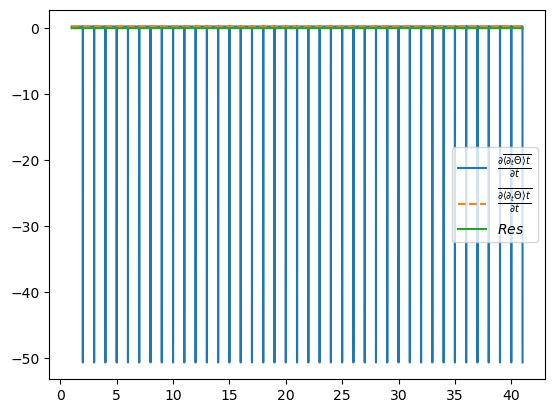

In [8]:
import matplotlib.pyplot as plt

plt.plot(t[:-1], datbardt,label=r'$\frac{\partial \overline{\langle \partial_t \Theta \rangle t}}{\partial t}$')
plt.plot(t[:-1], dTtrenddt_bar_pure,label=r'$\overline{\frac{\partial \langle \partial_t \Theta \rangle t}{\partial t}} $',linestyle='--')
plt.plot(t[:-1], datbardt-Trendbar_bar_pure,'-',label=r'$Res$')
plt.legend()

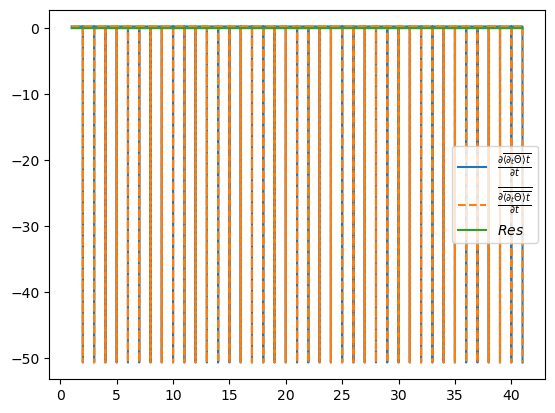

In [6]:
import matplotlib.pyplot as plt

plt.plot(t[:-1], datbardt,label=r'$\frac{\partial \overline{\langle \partial_t \Theta \rangle t}}{\partial t}$')
plt.plot(t[:-1], Trendbar_bar_pure,label=r'$\overline{\frac{\partial \overline{\langle \partial_t \Theta \rangle t}}{\partial t}} $',linestyle='--')
plt.plot(t[:-1], datbardt-Trendbar_bar_pure,'-',label=r'$Res$')
plt.legend()

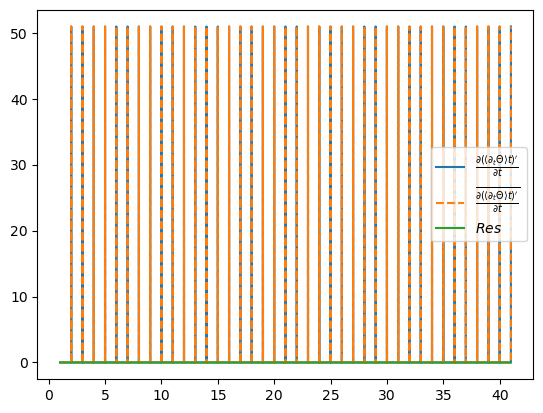

In [25]:
import matplotlib.pyplot as plt

plt.plot(t[:-1], datanomdt,label=r'$\frac{\partial (\langle \partial_t \Theta \rangle t)^{\prime}}{\partial t}$')
plt.plot(t[:-1], Trendanom_bar_pure,label=r'$\overline{\frac{\partial (\langle \partial_t \Theta \rangle t)^{\prime}}{\partial t}} $',linestyle='--')
plt.plot(t[:-1], Trendanom_bar_pure-datanomdt,'-',label=r'$Res$')
plt.legend()

(1.0, 4.0)

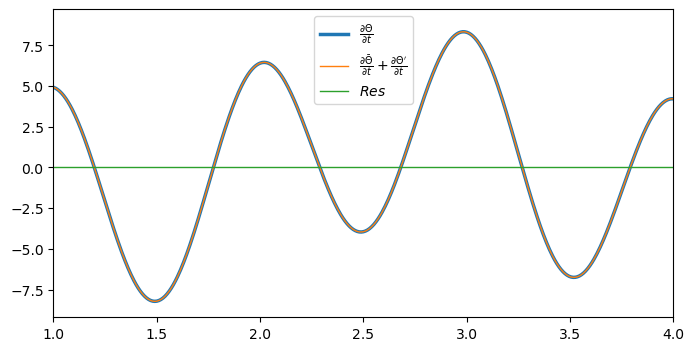

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# 设置两行一列的画布
fig, ax1 = plt.subplots(1, 1, figsize=(8, 4),sharex=True)

FS = 14
theta_expr_multiline = r'$\Theta = \sin\omega_{1} t + \sin\omega_{2}t$' + '\n' + r'$\quad + 0.25t + 5$'

# --- (a) 上图: 原始温度、趋势及分解 ---
ax1.plot(t[:-1], dTdt, label=r'$\frac{\partial \Theta}{\partial t}$', color='tab:blue', linewidth=2.5)  # 深蓝
ax1.plot(t[:-1], dT_bardt + dTadt, label=r'$\frac{\partial \bar{\Theta}}{\partial t} + \frac{\partial \Theta^{\prime}}{\partial t}$', color='tab:orange', linewidth=1.)  # 深蓝
ax1.plot(t[:-1], dT_bardt + dTadt - dTdt, label=r'$Res$', color='tab:green', linewidth=1)  # 深蓝

plt.legend()
ax1.set_xlim(1,4)

✅ 图片已成功保存至: temperature_raw_check.pdf


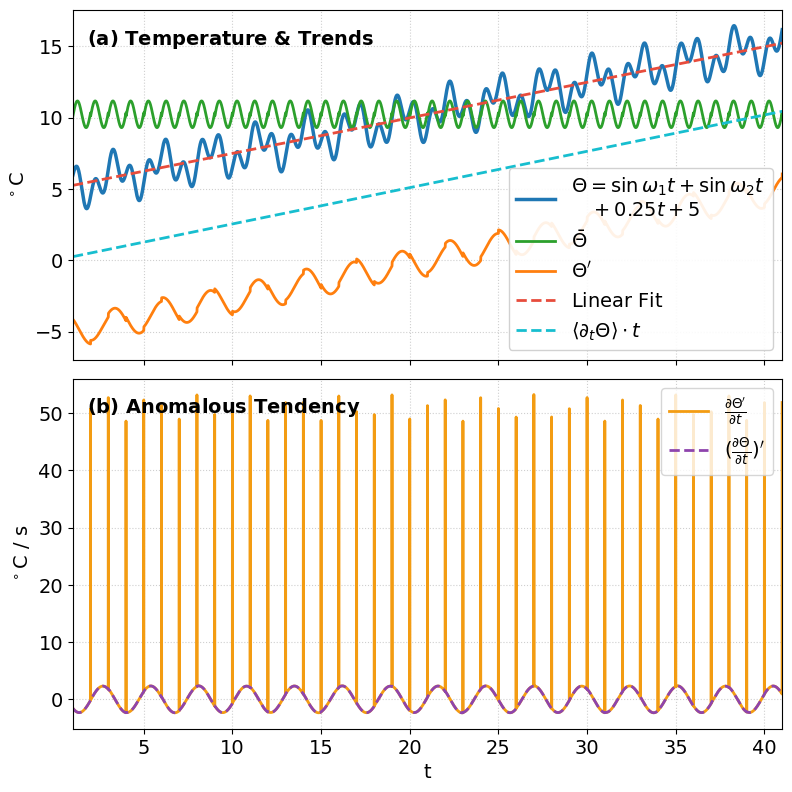

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# 设置两行一列的画布
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8),sharex=True)

FS = 14
theta_expr_multiline = r'$\Theta = \sin\omega_{1} t + \sin\omega_{2}t$' + '\n' + r'$\quad + 0.25t + 5$'

# --- (a) 上图: 原始温度、趋势及分解 ---
theta_expr = r'$\Theta = \sin(2\pi t) + \sin\left(\frac{2\pi}{2.7}t\right) + 0.25t + 5$'
ax1.plot(t, T, label=theta_expr_multiline, color='#1f77b4', linewidth=2.5)  # 深蓝
ax1.plot(t, T_bar_pure, label=r'$\bar{\Theta}$', color='tab:green', linewidth=2) 
ax1.plot(t, Tanom, label=r'$\Theta^{\prime}$', color='tab:orange', linewidth=2) 
ax1.plot(t, Ttrend_fit, label=r'$\mathrm{Linear\ Fit}$', color='#e74c3c', linewidth=2, linestyle='--') 
ax1.plot(t, Tbar * t, label=r'$\langle \partial_t{\Theta} \rangle \cdot t$', color='tab:cyan', linewidth=2, linestyle='--') 

ax1.text(0.02, 0.95, r'$\mathbf{(a)}$ Temperature & Trends', transform=ax1.transAxes, 
         fontsize=FS, verticalalignment='top', fontweight='bold')
ax1.set_ylabel(r'${^\circ}$C', fontsize=FS)
ax1.set_xlim(t[0], t[-1])
# 如果图例遮挡曲线，可以考虑设置 ncol=2
ax1.legend(loc='lower right', fontsize=FS, framealpha=0.9)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.tick_params(labelsize=FS)

# --- (b) 下图: 异常项倾向演变 ---
ax2.plot(t[:-1], dTadt, label=r'$\frac{\partial \Theta^{\prime}}{\partial t}$', color='#f39c12', linewidth=2) 
ax2.plot(t[:-1], dTdt_anom, label=r'$(\frac{\partial \Theta}{\partial t})^{\prime}$', color='#8e44ad', linewidth=2, linestyle='--') 

ax2.text(0.02, 0.95, r'$\mathbf{(b)}$ Anomalous Tendency', transform=ax2.transAxes, 
         fontsize=FS, verticalalignment='top', fontweight='bold')
ax2.set_xlabel('t', fontsize=FS)
ax2.set_ylabel(r'${^\circ}$C / s', fontsize=FS)
#ax2.set_xlim(1, 40) # 保持局部范围以看清波动
ax2.legend(loc='upper right', fontsize=FS)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.tick_params(labelsize=FS)

plt.tight_layout(pad=1.0)
save_path = "temperature_raw_check.png"
plt.savefig(save_path, dpi=1000, bbox_inches='tight')
save_path = "temperature_raw_check.pdf"
plt.savefig(save_path, dpi=1000, bbox_inches='tight')
print(f"✅ 图片已成功保存至: {save_path}")
plt.show()

✅ 图片已成功保存至: temperature_tendency_check.pdf


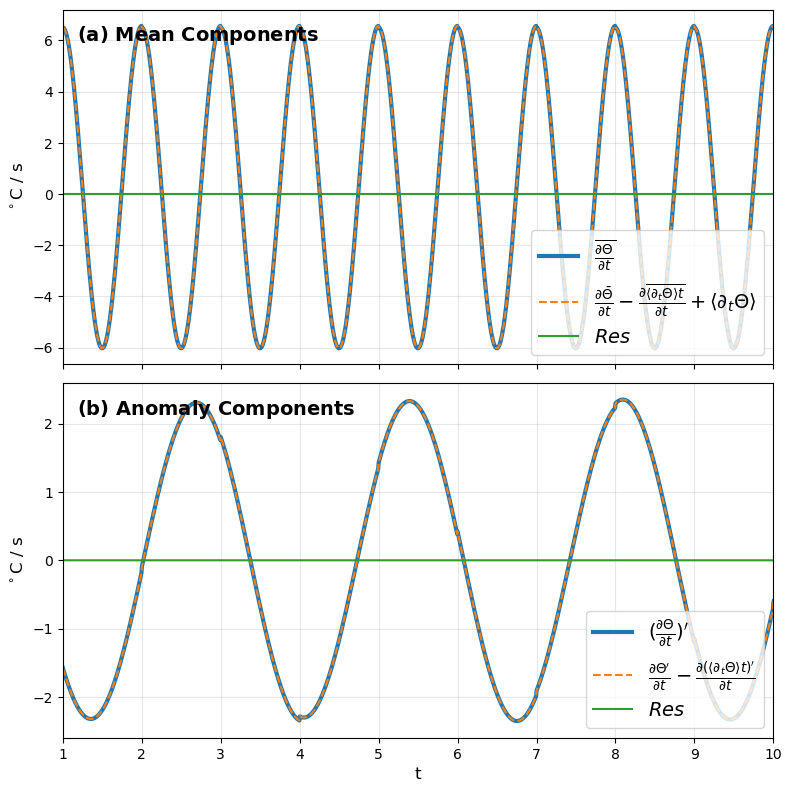

In [22]:
import matplotlib.pyplot as plt

# 修改为两行一列 (2 rows, 1 column)
# 增加高度 (figsize)，确保两张图都有足够的纵向空间
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8),sharex=True)

# --- 第一张子图 (上方：Mean Components) ---
ax1.plot(t[:-1], dTdt_bar_pure, label=r'$\overline{\frac{\partial \Theta}{\partial t}}$', linewidth=3)
ax1.plot(t[:-1], dT_bardt-datbardt+Tbar, label=r'$\frac{\partial \bar{\Theta}}{\partial t}-\frac{\partial \overline{\langle \partial_t{\Theta} \rangle t}}{\partial t}+\langle \partial_t{\Theta} \rangle$', linestyle='--')
ax1.plot(t[:-1], dT_bardt-datbardt-dTdt_bar_pure+Tbar, label=r'$Res$')

# 内部左上角标题: (a)
ax1.text(0.02, 0.96, r'$\mathbf{(a)}$ Mean Components', transform=ax1.transAxes, 
         fontsize=14, verticalalignment='top', fontweight='bold')

ax1.set_xlim(1, 10)
#ax1.set_xlabel('t', fontsize=12)
ax1.set_ylabel(r'${^\circ}$C / s', fontsize=12)
ax1.legend(loc='lower right', fontsize=14)
ax1.grid(True, alpha=0.3)

# --- 第二张子图 (下方：Anomaly Components) ---
ax2.plot(t[:-1], dTdt_anom, label=r'$(\frac{\partial \Theta}{\partial t})^{\prime}$', linewidth=3)
ax2.plot(t[:-1], dTadt-datanomdt, label=r'$\frac{\partial \Theta^{\prime}}{\partial t}-\frac{\partial (\langle \partial_t{\Theta} \rangle t)^{\prime}}{\partial t}$', linestyle='--')
ax2.plot(t[:-1], dTadt-datanomdt-dTdt_anom, label=r'$Res$')

# 内部左上角标题: (b)
ax2.text(0.02, 0.96, r'$\mathbf{(b)}$ Anomaly Components', transform=ax2.transAxes, 
         fontsize=14, verticalalignment='top', fontweight='bold')

ax2.set_xlim(1, 10)
ax2.set_xlabel('t', fontsize=12)
ax2.set_ylabel(r'${^\circ}$C / s', fontsize=12)
ax2.legend(loc='lower right', fontsize=14)
ax2.grid(True, alpha=0.3)

# 调整子图间的间距，避免第一张图的 xlabel 被第二张图遮挡
plt.tight_layout(pad=1.0)
save_path = "temperature_tendency_check.png"
plt.savefig(save_path, dpi=1000, bbox_inches='tight')
save_path = "temperature_tendency_check.pdf"
plt.savefig(save_path, dpi=1000, bbox_inches='tight')
print(f"✅ 图片已成功保存至: {save_path}")
plt.show()

(1.8, 2.2)

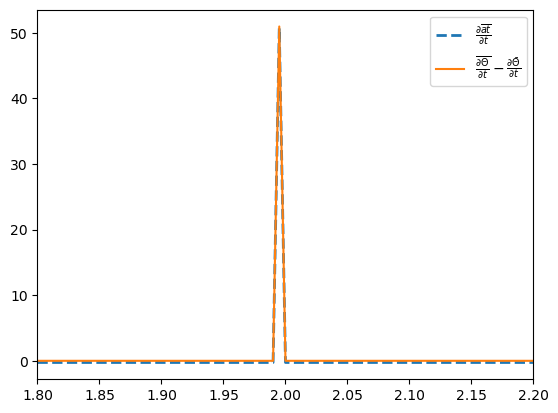

In [52]:
plt.plot(t[:-1],-datbardt, label=r'$\frac{\partial \overline{at}}{\partial t}$',linewidth=2,linestyle='--')
plt.plot(t[:-1],dTdt_bar_pure-dT_bardt, label=r'$\overline{\frac{\partial \Theta}{\partial t}}-\frac{\partial \bar{\Theta}}{\partial t}$')

#plt.plot(t[:-1],dTadt-datanomdt, label=r'$\frac{\partial \Theta^{\prime}}{\partial t}-\frac{\partial (at)^{\prime}}{\partial t}$')
plt.legend()
plt.xlim(1.8,2.2)

(1.8, 2.2)

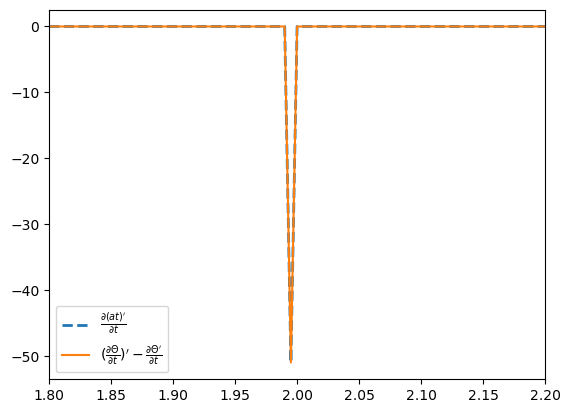

In [45]:
#plt.plot(t[:-1],dTdt_anom, label='dTdt anom',linewidth=3)
#plt.plot(t[:-1],dTadt, label='dTadt',linestyle='--')
plt.plot(t[:-1],-datanomdt, label=r'$\frac{\partial (at)^{\prime}}{\partial t}$',linewidth=2,linestyle='--')
plt.plot(t[:-1],dTdt_anom-dTadt, label=r'$(\frac{\partial \Theta}{\partial t})^{\prime}-\frac{\partial \Theta^{\prime}}{\partial t}$')

#plt.plot(t[:-1],dTadt-datanomdt, label=r'$\frac{\partial \Theta^{\prime}}{\partial t}-\frac{\partial (at)^{\prime}}{\partial t}$')
plt.legend()
plt.xlim(1.8,2.2)

✅ 图片已成功保存至: temperature_raw_check.png


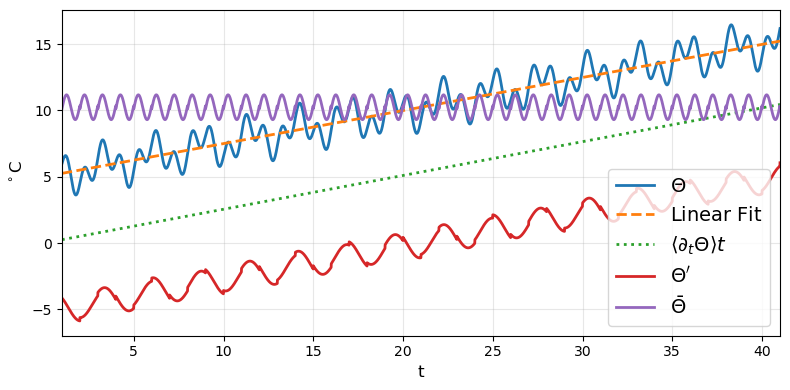

In [93]:
Ttrend = get_trend_info(T, dt)    

import matplotlib.pyplot as plt

# 创建一个新的图和子图
fig, ax = plt.subplots(1, 1, figsize=(8, 4)) # 单张图，尺寸可以灵活调整

# 绘制曲线
ax.plot(t, T, label=r'$\Theta$', linewidth=2)
ax.plot(t, Ttrend, label=r'$\mathrm{Linear\ Fit}$', linewidth=2, linestyle='--')
ax.plot(t, Tbar * t, label=r'$\langle \partial_t{\Theta} \rangle t$', linewidth=2, linestyle=':')
ax.plot(t, Tanom, label=r'$\Theta^{\prime}$', linewidth=2)
ax.plot(t, T_bar_pure, label=r'$\bar{\Theta}$', linewidth=2)

# 内部左上角标题: (c) Mean Temperature and Trends
#ax.text(0.02, 0.95, r'$\mathbf{(c)}$ Mean Temperature and Trends', transform=ax.transAxes, 
#        fontsize=14, verticalalignment='top', fontweight='bold')

# 设置轴标签
ax.set_xlabel('t', fontsize=12)
ax.set_ylabel(r'${^\circ}$C', fontsize=12) # 假设 T 的单位是摄氏度

# 设置图例
ax.legend(loc='lower right', fontsize=14)

# 添加网格
ax.grid(True, alpha=0.3)
ax.set_xlim(t[0],t[-1])
# 自动调整布局，防止标签重叠
plt.tight_layout()

# === 保存图片配置 ===
save_path = "temperature_raw_check.png"
#plt.savefig(save_path, dpi=300, bbox_inches='tight')

print(f"✅ 图片已成功保存至: {save_path}")

# 显示图片
plt.show()

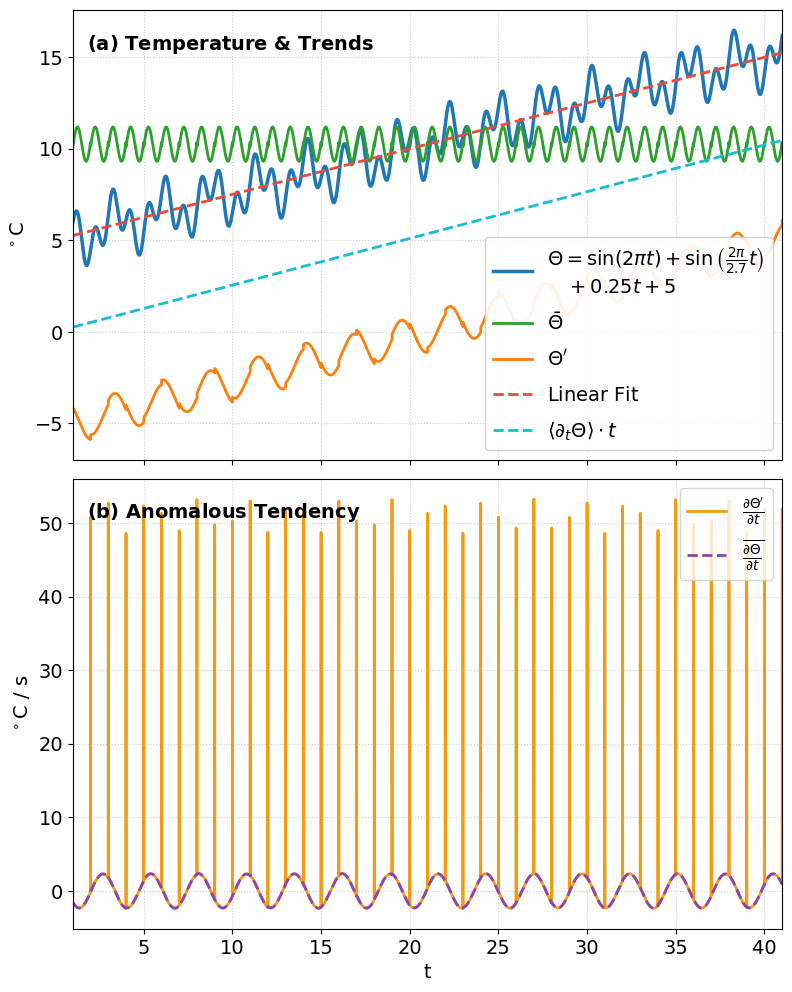

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# 设置两行一列的画布
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10), sharex=True)

FS = 14

# --- (a) 上图 ---
# 使用 \n 来实现物理换行，每一行分别用 $ $ 包裹公式
theta_expr_multiline = r'$\Theta = \sin(2\pi t) + \sin\left(\frac{2\pi}{2.7}t\right)$' + '\n' + r'$\quad + 0.25t + 5$'

ax1.plot(t, T, label=theta_expr_multiline, color='#1f77b4', linewidth=2.5) 
ax1.plot(t, T_bar_pure, label=r'$\bar{\Theta}$', color='tab:green', linewidth=2) 
ax1.plot(t, Tanom, label=r'$\Theta^{\prime}$', color='tab:orange', linewidth=2) 
ax1.plot(t, Ttrend_fit, label=r'$\mathrm{Linear\ Fit}$', color='#e74c3c', linewidth=2, linestyle='--') 
ax1.plot(t, Tbar * t, label=r'$\langle \partial_t{\Theta} \rangle \cdot t$', color='tab:cyan', linewidth=2, linestyle='--') 

ax1.text(0.02, 0.95, r'$\mathbf{(a)}$ Temperature & Trends', transform=ax1.transAxes, 
         fontsize=FS, verticalalignment='top', fontweight='bold')
ax1.set_ylabel(r'${^\circ}$C', fontsize=FS)
ax1.set_xlim(t[0], t[-1])

# 设置图例，labelspacing 可以让行距稍微紧凑或宽松一点
ax1.legend(loc='lower right', fontsize=FS, framealpha=0.9, labelspacing=0.8)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.tick_params(labelsize=FS)

# --- (b) 下图 ---
ax2.plot(t[:-1], dTadt, label=r'$\frac{\partial \Theta^{\prime}}{\partial t}$', color='#f39c12', linewidth=2) 
ax2.plot(t[:-1], dTdt_anom, label=r'$\overline{\frac{\partial \Theta}{\partial t}}$', color='#8e44ad', linewidth=2, linestyle='--') 

ax2.text(0.02, 0.95, r'$\mathbf{(b)}$ Anomalous Tendency', transform=ax2.transAxes, 
         fontsize=FS, verticalalignment='top', fontweight='bold')
ax2.set_xlabel('t', fontsize=FS)
ax2.set_ylabel(r'${^\circ}$C / s', fontsize=FS)
ax2.legend(loc='upper right', fontsize=FS)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.tick_params(labelsize=FS)

plt.tight_layout(pad=1.0)
plt.show()

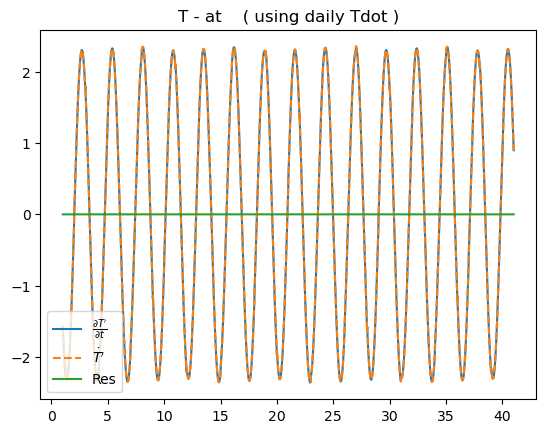

In [16]:
plt.figure()
#plt.plot(t, Tanom , label=r'$T^{\prime}$')
plt.plot(t[:-1], dTadt , label=r'$\frac{\partial{T^{\prime}} }{\partial{t}}$',)
plt.plot(t[:-1], Tdotanom , linestyle='--',label=r'$\dot{T}^{\prime}$')
plt.plot(t[0:-1], dTadt - Tdotanom,label='Res' )
plt.title("T - at    ( using daily Tdot )")
plt.legend()


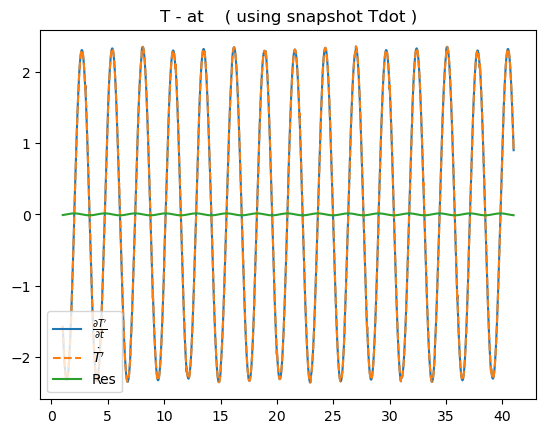

In [22]:
plt.figure()
plt.plot(t[:-1], dTadt , label=r'$\frac{\partial{T^{\prime}} }{\partial{t}}$',)
plt.plot(t, Tdotanom , linestyle='--',label=r'$\dot{T}^{\prime}$')
plt.plot(t[0:-1], dTadt - Tdotanom[0:-1],label='Res' )
plt.legend()
plt.title("T - at    ( using snapshot Tdot )")
plt.show()

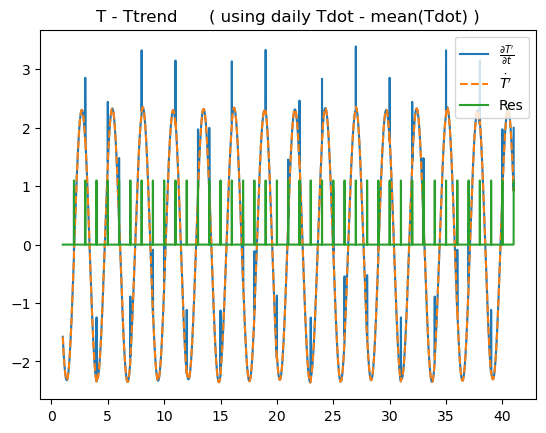

In [27]:
plt.figure()
plt.plot(t[:-1], dTadt , label=r'$\frac{\partial{T^{\prime}} }{\partial{t}}$',)
plt.plot(t[:-1], Tdotanom , linestyle='--',label=r'$\dot{T}^{\prime}$')
plt.plot(t[0:-1], dTadt - Tdotanom,label='Res' )
plt.title("T - Ttrend      ( using daily Tdot - mean(Tdot) )")
plt.legend()
plt.show()

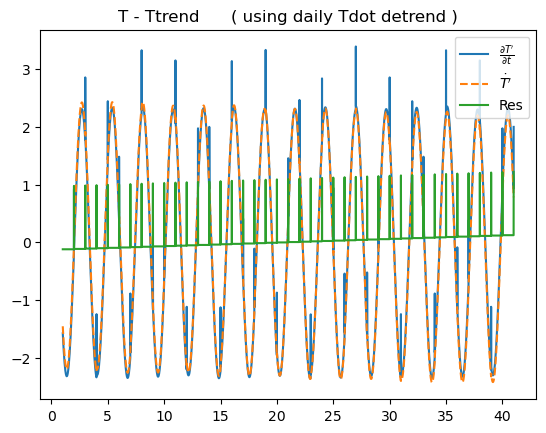

In [29]:
plt.figure()
plt.plot(t[:-1], dTadt , label=r'$\frac{\partial{T^{\prime}} }{\partial{t}}$',)
plt.plot(t[:-1], Tdotanom , linestyle='--',label=r'$\dot{T}^{\prime}$')
plt.plot(t[0:-1], dTadt - Tdotanom,label='Res' )
plt.title("T - Ttrend      ( using daily Tdot detrend )")
plt.legend()
plt.show()

In [54]:
0.07*86400*365/1000

2207.5200000000004

# $T(t,x)$

In [64]:
import numpy as np
import matplotlib.pyplot as plt

# =================================================================
# 1. Grid Configuration
# =================================================================
dt = 0.005          # Time step (Years)
t_max = 41          # Total duration
t = np.arange(1, t_max, dt)
t = np.concatenate((t, [t[-1]+dt]))
ntotal = len(t)

dx = 0.0015         # Spatial step (Normalized)
x_max = 3.0         # Basin width
x = np.arange(0, x_max + dx, dx)
Nx = len(x)

# Meshgrid for vectorized calculations
x2, t2 = np.meshgrid(x,t, indexing='ij')

# =================================================================
# 2. Parameters (Params Dictionary)
# =================================================================
params = {
    # Frequencies (rad/year)
    'omega1': 2 * np.pi,               # Annual cycle
    'omega2': 2 * np.pi / 2.7,         # Interannual cycle (~2.7 yrs)
    'omega3': 2 * np.pi / 3,       # Velocity oscillation (4 months)
    
    # Amplitudes
    'a1': 1.0, 'a2': 0.5, 'a3': 0.8, 'a5': 0.3,
    
    # Constants
    'c': 15.0,
    'warming_rate_annual': 0.05,
    
    # Propagation
    'cp': 0.1,                         # Phase speed
    'u0': 0.05,                        # Mean velocity
}

# Calculate Wavenumber k1 to fit exactly 20 wave cycles
params['k1'] = (2 * np.pi) / (x_max / 20.0)

# =================================================================
# 3. Core Physics and Derivatives
# =================================================================
p = params
phase = p['k1'] * (x2 - p['cp'] * t2)

# Velocity u(t)
u_t = p['u0'] * (1 + p['a5'] * np.sin(p['omega3'] * t2))

# Temperature T(x, t)
T = (p['a1'] * np.cos(p['omega1'] * t2) + 
     p['a2'] * np.cos(p['omega2'] * t2) + 
     p['a3'] * np.sin(phase) + 
     p['warming_rate_annual'] * t2 + p['c'])

# Spatial Gradient Tx
Tx = p['a3'] * p['k1'] * np.cos(phase)

# Local Time Derivative Tt
Tt = (-p['a1'] * p['omega1'] * np.sin(p['omega1'] * t2) - 
       p['a2'] * p['omega2'] * np.sin(p['omega2'] * t2) - 
       p['a3'] * p['k1'] * p['cp'] * np.cos(phase) + 
       p['warming_rate_annual'])

# Advection term uTx
uTx = u_t * Tx

Tdot = Tt + uTx

# =================================================================
# 4. Analytical Antiderivatives (Integration over Time)
# =================================================================
def get_integrated_fields(x_mesh, t_mesh, p):
    phi = p['k1'] * (x_mesh - p['cp'] * t_mesh)
    
    # --- int_T dt ---
    int_T = ( (p['a1']/p['omega1']) * np.sin(p['omega1']*t_mesh) +
              (p['a2']/p['omega2']) * np.sin(p['omega2']*t_mesh) +
              (p['a3']/(p['k1']*p['cp'])) * np.cos(phi) +
              0.5 * p['warming_rate_annual'] * t_mesh**2 + p['c']*t_mesh )
    
    # Integral of u
    int_u = p['u0'] * t_mesh - (p['u0'] * p['a5'] / p['omega3']) * np.cos(p['omega3'] * t_mesh)
    
    # --- int_Tt dt (Original T) ---
    int_Tt = ( p['a1']*np.cos(p['omega1']*t_mesh) + 
               p['a2']*np.cos(p['omega2']*t_mesh) + 
               p['a3']*np.sin(phi) + 
               p['warming_rate_annual']*t_mesh + p['c'] )
    
    # --- int_Tx dt ---
    int_Tx = -(p['a3'] / p['cp']) * np.sin(phi)
    
    # --- int_uTx dt ---
    term_const = p['u0'] * int_Tx
    f_plus, f_minus = p['omega3'] - p['k1']*p['cp'], p['omega3'] + p['k1']*p['cp']
    phi_plus = p['omega3']*t_mesh + p['k1']*(x_mesh - p['cp']*t_mesh)
    phi_minus = p['omega3']*t_mesh - p['k1']*(x_mesh - p['cp']*t_mesh)
    coeff = (p['u0'] * p['a5'] * p['a3'] * p['k1']) / 2.0
    term_osc = coeff * (-np.cos(phi_plus)/f_plus - np.cos(phi_minus)/f_minus)
    int_uTx = term_const + term_osc
    
    # --- int_Tdot dt (The Sum) ---
    int_Tdot = int_Tt + int_uTx
    
    return int_T, int_Tx, int_uTx, int_Tdot, int_u

# Execute calculation
int_T, int_Tx, int_uTx, int_Tdot, int_u  = get_integrated_fields(x2, t2, params)

# daily average
T_daily = (int_T[:,1:]-int_T[:,0:-1])/dt
Tx_daily = (int_Tx[:,1:]-int_Tx[:,0:-1])/dt
u_daily = (int_u[:,1:]-int_u[:,0:-1])/dt
Tdot_daily = (int_Tdot[:,1:]-int_Tdot[:,0:-1])/dt
uTx_daily = (int_uTx[:,1:]-int_uTx[:,0:-1])/dt

t_daily = (t[1:] + t[:-1])/2

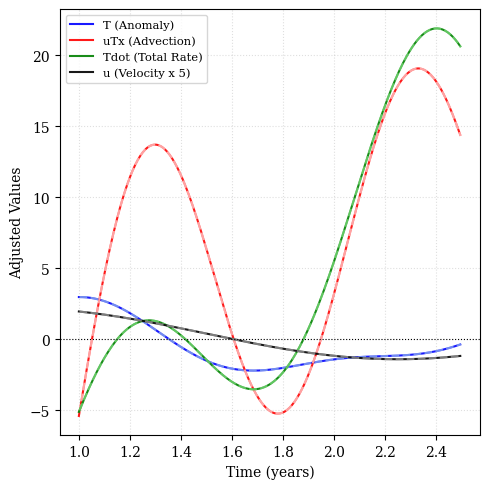

In [71]:
import matplotlib.pyplot as plt
# Adjusted size to ensure the legend and waves are readable
plt.figure(figsize=(5, 5))

# Define index range
idx = slice(0, 300)
x_pos = 100  # Spatial index

# Baseline for T
T_mean = 15.0

# 1. Temperature T (Blue)
# High-res: solid blue, Daily: very light blue dashed
plt.plot(t[idx], T[x_pos, idx] - T_mean, color='blue', linestyle='-', label='T (Anomaly)', alpha=0.9)
plt.plot(t_daily[idx], T_daily[x_pos, idx] - T_mean, color='lightblue', linestyle='--', alpha=0.6)

# 2. Advection term uTx (Red)
# High-res: solid red, Daily: light coral dashed
plt.plot(t[idx], uTx[x_pos, idx], color='red', linestyle='-', label='uTx (Advection)', alpha=0.9)
plt.plot(t_daily[idx], uTx_daily[x_pos, idx], color='white', linestyle='--', alpha=0.6)

# 3. Total source Tdot (Green)
# High-res: solid green, Daily: light green/lime dashed
plt.plot(t[idx], Tdot[x_pos, idx], color='green', linestyle='-', label='Tdot (Total Rate)', alpha=0.9)
plt.plot(t_daily[idx], Tdot_daily[x_pos, idx], color='lightgreen', linestyle='--', alpha=0.6)

# 4. Velocity u (Black/Grey)
# High-res: solid black, Daily: light grey dashed
plt.plot(t[idx], u_t[x_pos, idx] * 5, color='black', linestyle='-', label='u (Velocity x 5)', alpha=0.9)
plt.plot(t_daily[idx], u_daily[x_pos, idx] * 5, color='silver', linestyle='--', alpha=0.6)

# Decorations
plt.axhline(0, color='black', linewidth=0.8, linestyle=':')
#plt.title(f'High-Res vs Daily Comparison at x={x_pos}')
plt.xlabel('Time (years)')
plt.ylabel('Adjusted Values')

# Place legend outside or in a clear spot
plt.legend(loc='best', fontsize='small', frameon=True)
plt.grid(True, which='both', linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()


# method 1 - minus \<at\>

In [143]:
# detrend
Tanb = ((T[:, -1] - T[:, 0]) / (t[-1] - t[0]))[:, np.newaxis] * t2
Tdotanb = np.mean(Tdot_daily - uTx_daily, axis=1)[:, np.newaxis] * np.ones([x.shape[0],t_daily.shape[0]])
Twave = T - Tanb   # detrend

## T anom
yearlyNt = int(2*np.pi/p['omega1']/dt)   # timesteps per year
nyear = int(len(t)/yearlyNt)       # number of years
shape_rest = T.shape[0:1] 

Twave_bar = calc_cyclic_mean(Twave.T, nyear, yearlyNt, shape_rest, smooth=0, smooth_window=1)
Twave_bar_pure = cal_cyclic_mean_pure(Twave.T, nyear, yearlyNt, shape_rest, smooth=0).T
Twave_anom = Twave - Twave_bar_pure

T_bar_pure = cal_cyclic_mean_pure(T.T, nyear, yearlyNt, shape_rest, smooth=0).T
T_anom = T - T_bar_pure

## dTdt
dTadt  =  (T_anom[:,1:] - T_anom[:,0:-1])/dt
dTwadt =  (Twave_anom[:,1:] - Twave_anom[:,0:-1])/dt

## 
Tanb_bar_pure = cal_cyclic_mean_pure(Tanb.T, nyear, yearlyNt, shape_rest, smooth=0).T
Tanb_anom = Tanb - Tanb_bar_pure

## u_bar Tx_bar uTx_bar
udaily_bar_pure   = cal_cyclic_mean_pure(u_daily.T, nyear, yearlyNt, shape_rest, smooth=0).T
uTxdaily_bar_pure = cal_cyclic_mean_pure(uTx_daily.T, nyear, yearlyNt, shape_rest, smooth=0).T
Txdaily_bar_pure  = cal_cyclic_mean_pure(Tx_daily.T, nyear, yearlyNt, shape_rest, smooth=0).T

udaily_anom = u_daily - udaily_bar_pure
Txdaily_anom = Tx_daily - Txdaily_bar_pure

upTxp_bar = uTxdaily_bar_pure - udaily_bar_pure*Txdaily_bar_pure
upTxbar = -(udaily_anom * Txdaily_bar_pure)
uTxanom = -(u_daily * Txdaily_anom)

## Tdot
Tdotdaily_bar_pure  = cal_cyclic_mean_pure(Tdot_daily.T, nyear, yearlyNt, shape_rest, smooth=0).T
Tdotdaily_anom = Tdot_daily - Tdotdaily_bar_pure

## RHS
RHS = uTxanom + upTxbar + upTxp_bar + Tdotdaily_anom 


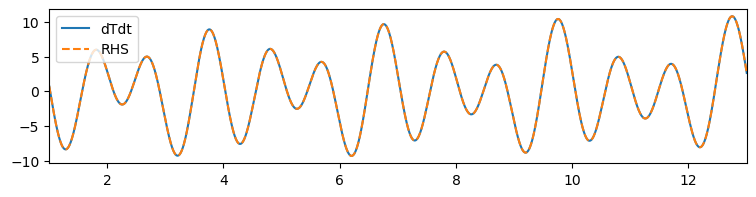

In [25]:
plt.figure(figsize=(9, 2))
plt.plot(t_daily, (T[100,1:]-T[100,0:-1])/dt, label='dTdt' )
plt.plot(t_daily, (Tdot_daily[100,:]-uTx_daily[100,:]), label='RHS',linestyle='--' )
plt.xlim(1,13)
plt.legend()
plt.show()

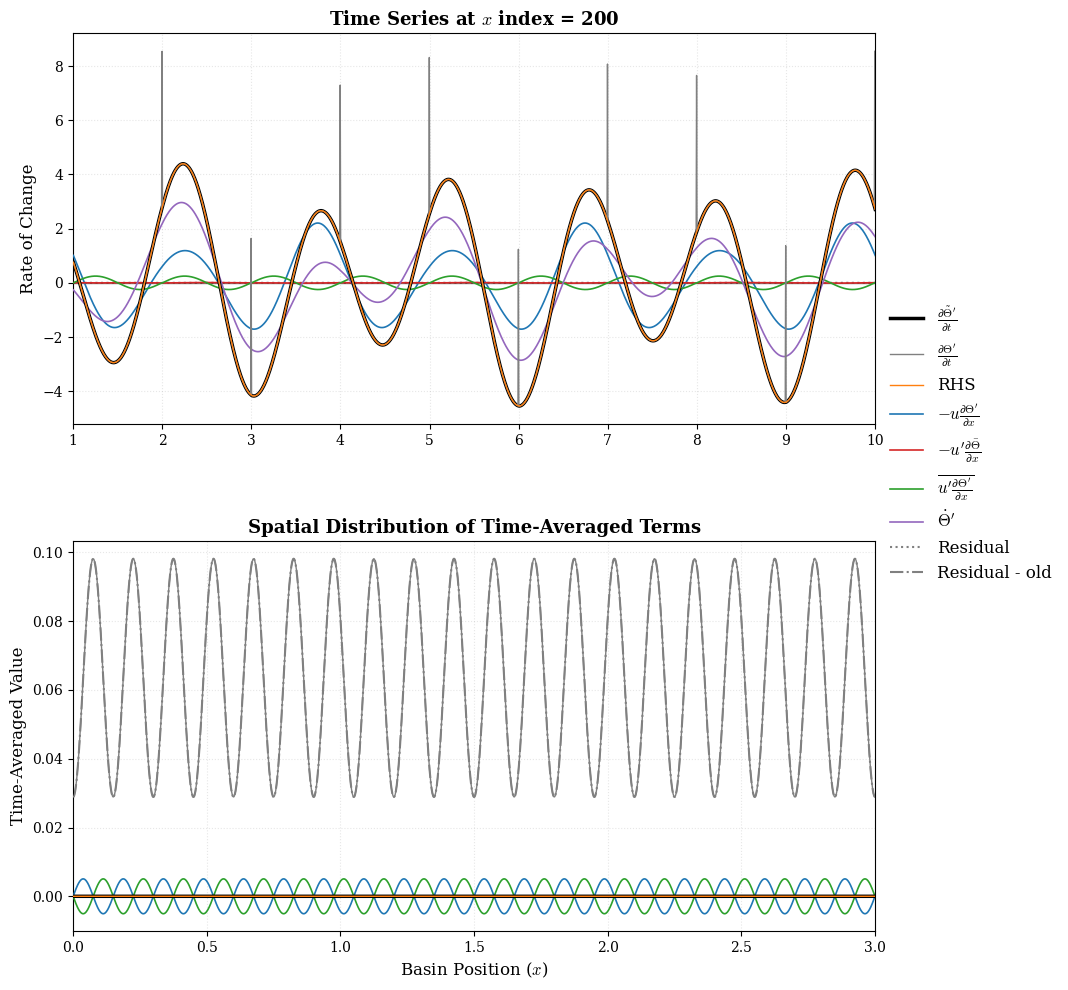

In [158]:
import matplotlib.pyplot as plt
import numpy as np

# 设置全局物理公式字体
plt.rcParams.update({
    "mathtext.fontset": "cm",
    "font.family": "serif"
})

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 10))

# 空间索引和位置
x_idx = 200 

# 定义物理项列表: (数据矩阵, 标签, 颜色, 线宽, 层级)
items = [
    (dTwadt, r'$\frac{\partial{\tilde{\Theta}^{\prime}}}{\partial{t}}$', 'black', 2.5, 9),
    (dTadt, r'$\frac{\partial{\Theta^{\prime}}}{\partial{t}}$', 'grey', 1, 9),
    (RHS, 'RHS', 'tab:orange', 1, 10),
    (uTxanom, r'$-u\frac{\partial{\Theta^{\prime}}}{\partial{x}}$', 'tab:blue', 1.2, 5),
    (upTxbar, r'$-u^{\prime}\frac{\partial{\bar{\Theta}}}{\partial{x}}$', 'tab:red', 1.2, 5),
    (upTxp_bar, r'$\overline{u^{\prime}\frac{\partial{\Theta^{\prime}}}{\partial{x}}}$', 'tab:green', 1.2, 5),
    (Tdotdaily_anom, r'$\dot{\Theta}^{\prime}$', 'tab:purple', 1.2, 5),
]

# --- 子图 1: 时间序列 (固定在 x_idx) ---
for data, label, color, lw, zo in items:
    ax1.plot(t_daily, data[x_idx], label=label, color=color, lw=lw, zorder=zo)

ax1.plot(t_daily, (dTwadt - RHS)[x_idx], color='grey', linestyle=':', alpha=1,label='Residual')
ax1.set_xlim(1, 10) # 保持你要求的时间范围
ax1.set_ylabel('Rate of Change', fontsize=12)
ax1.set_title(f'Time Series at $x$ index = {x_idx}', fontsize=13, fontweight='bold')
ax1.grid(True, linestyle=':', alpha=0.3)
ax1.axhline(0, color='black', lw=1, alpha=0.5)

# --- 子图 2: 空间分布 (时间平均量 ⟨·⟩ 沿 x 轴) ---
# 计算时间维度的平均值 (假设 axis=1 是时间轴)

for data, label, color, lw, zo in items:
    # 对所有时间步取平均，得到一根关于 x 的曲线
    spatial_data = np.mean(data, axis=1) 
    ax2.plot(x, spatial_data, label=label, color=color, lw=lw, zorder=zo)

# 残差的空间分布
res_spatial = np.mean(dTwadt - RHS, axis=1)
ax2.plot(x, res_spatial, color='grey', linestyle=':', alpha=1,label='Residual')
res_spatial2 = np.mean(dTadt - RHS, axis=1)
ax2.plot(x, res_spatial2, color='grey', linestyle='-.', alpha=1,label='Residual - old')

ax2.set_ylabel('Time-Averaged Value', fontsize=12)
ax2.set_xlabel('Basin Position ($x$)', fontsize=12)
ax2.set_title(r'Spatial Distribution of Time-Averaged Terms', fontsize=13, fontweight='bold')
ax2.grid(True, linestyle=':', alpha=0.3)
ax2.axhline(0, color='black', lw=1, alpha=0.5)
ax2.set_xlim(x[0], x[-1])

# 图例统一放置在右侧
ax2.legend(fontsize=12, loc='center left', bbox_to_anchor=(1, 1.25), frameon=False)

plt.tight_layout()
plt.subplots_adjust(right=0.8, hspace=0.3) 
plt.savefig('anomaly_budget_revisetrend.png')
plt.show()


# 3-order warming rate

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# =================================================================
# 1. Grid Configuration
# =================================================================
dt = 0.05
t_max = 41
t = np.arange(1, t_max, dt)
t = np.concatenate((t, [t[-1]+dt]))
ntotal = len(t)

dx = 0.006
x_max = 3.0
x = np.arange(0, x_max + dx, dx)
Nx = len(x)

x2, t2 = np.meshgrid(x, t, indexing='ij')

# =================================================================
# 2. Parameters (校准后的物理参数)
# =================================================================
params = {
    'omega1': 2 * np.pi,
    'omega2': 2 * np.pi / 2.7,
    'omega3': 2 * np.pi / 3,
    
    'a1': 1.0, 'a2': 0.5, 
    'a3': 2., 
    'a4': 1.,
    'a5': 4.5,                         ## MODIFIED ##: 增大流速异常比例 (u' >> u0)
    
    'c': 15.0,
    'cp': 0.1,
    'u0': 0.08,                        ## MODIFIED ##: 稍微增大平均流基数

    'b_linear': 0.03,
    'b_accel': 0.0008,
    'amp_low': 0.4,
    'omega_low': 2*np.pi/50,
    'phase_low': 1.0,

    'dTdx_back': -3.0,                 ## MODIFIED ##: 显著增大背景空间梯度 (让 u'Tx_bar 有物可抽)
}

# ## MODIFIED ##: 将波数 k 大幅减小（从 20.5 减到 3.5），模拟大尺度 Rossby 波
# 这样 Tx_prime (波梯度) 的量级会下降，从而让 Tx_bar (背景梯度) 相对凸显
params['k1'] = (2 * np.pi) / (x_max / 17.5) 
params['k2'] = params['k1'] * 0.25

# =================================================================
# 3. Core Physics and Derivatives (保持逻辑一致)
# =================================================================
p = params
phi_w1 = p['k1'] * (x2 - p['cp'] * t2)
phi_w2 = p['k2'] * (x2 - p['cp'] * t2)
phi_low = p['omega_low'] * t2 + p['phase_low']

u_t = p['u0'] * (1 + p['a5'] * np.sin(p['omega3'] * t2))

T_trend = (p['b_linear'] * t2 + p['b_accel'] * t2**2 + p['amp_low'] * np.sin(phi_low))
dT_trend_dt = (p['b_linear'] + 2 * p['b_accel'] * t2 + p['amp_low'] * p['omega_low'] * np.cos(phi_low))

T = (p['a1'] * np.cos(p['omega1'] * t2) + p['a2'] * np.cos(p['omega2'] * t2) + 
     p['a3'] * np.sin(phi_w1) + p['a4'] * np.sin(phi_w2) + 
     p['dTdx_back'] * x2 + T_trend + p['c'])

Tx = (p['a3'] * p['k1'] * np.cos(phi_w1) + p['a4'] * p['k2'] * np.cos(phi_w2) + p['dTdx_back'])

Tt = (-p['a1'] * p['omega1'] * np.sin(p['omega1'] * t2) - 
       p['a2'] * p['omega2'] * np.sin(p['omega2'] * t2) - 
       p['a3'] * p['k1'] * p['cp'] * np.cos(phi_w1) - 
       p['a4'] * p['k2'] * p['cp'] * np.cos(phi_w2) + 
       dT_trend_dt)

uTx = u_t * Tx
Tdot = Tt + uTx

# =================================================================
# 4. Analytical Antiderivatives (逻辑同前，确保解析闭合)
# =================================================================
def get_integrated_fields(x_mesh, t_mesh, p):
    phi_w1 = p['k1'] * (x_mesh - p['cp'] * t_mesh)
    phi_w2 = p['k2'] * (x_mesh - p['cp'] * t_mesh)
    phi_low = p['omega_low'] * t_mesh + p['phase_low']
    
    int_T_trend = (0.5 * p['b_linear'] * t_mesh**2 + (1/3.0) * p['b_accel'] * t_mesh**3 - 
                   (p['amp_low'] / p['omega_low']) * np.cos(phi_low))
    int_T_spatial = p['dTdx_back'] * x_mesh * t_mesh
    int_T = ( (p['a1']/p['omega1']) * np.sin(p['omega1']*t_mesh) + (p['a2']/p['omega2']) * np.sin(p['omega2']*t_mesh) +
              (p['a3']/(p['k1']*p['cp'])) * np.cos(phi_w1) + (p['a4']/(p['k2']*p['cp'])) * np.cos(phi_w2) +
              int_T_trend + int_T_spatial + p['c']*t_mesh )
    
    int_u = p['u0'] * t_mesh - (p['u0'] * p['a5'] / p['omega3']) * np.cos(p['omega3'] * t_mesh)
    
    T_current = (p['a1'] * np.cos(p['omega1'] * t_mesh) + p['a2'] * np.cos(p['omega2'] * t_mesh) + 
                 p['a3'] * np.sin(phi_w1) + p['a4'] * np.sin(phi_w2) + 
                 (p['b_linear'] * t_mesh + p['b_accel'] * t_mesh**2 + p['amp_low'] * np.sin(phi_low)) + 
                 p['dTdx_back'] * x_mesh + p['c'])
    int_Tt = T_current
    
    int_Tx = (-(p['a3'] / p['cp']) * np.sin(phi_w1) - (p['a4'] / p['cp']) * np.sin(phi_w2) + p['dTdx_back'] * t_mesh)
    
    term_u0_Tx = p['u0'] * int_Tx
    
    def calc_osc_integral(k_val, a_val):
        f_plus, f_minus = p['omega3'] - k_val*p['cp'], p['omega3'] + k_val*p['cp']
        p_plus = p['omega3']*t_mesh + k_val*(x_mesh - p['cp']*t_mesh)
        p_minus = p['omega3']*t_mesh - k_val*(x_mesh - p['cp']*t_mesh)
        coeff = (p['u0'] * p['a5'] * a_val * k_val) / 2.0
        return coeff * (-np.cos(p_plus)/f_plus - np.cos(p_minus)/f_minus)

    term_u_prime_wave = calc_osc_integral(p['k1'], p['a3']) + calc_osc_integral(p['k2'], p['a4'])
    term_u_prime_spatial = -(p['u0'] * p['a5'] * p['dTdx_back'] / p['omega3']) * np.cos(p['omega3'] * t_mesh)
    
    int_uTx = term_u0_Tx + term_u_prime_wave + term_u_prime_spatial
    int_Tdot = int_Tt + int_uTx
    return int_T, int_Tx, int_uTx, int_Tdot, int_u

# =================================================================
# 5. Output and Diagnosis
# =================================================================
int_T, int_Tx, int_uTx, int_Tdot, int_u = get_integrated_fields(x2, t2, params)


# daily average
T_daily = (int_T[:,1:]-int_T[:,0:-1])/dt
Tx_daily = (int_Tx[:,1:]-int_Tx[:,0:-1])/dt
u_daily = (int_u[:,1:]-int_u[:,0:-1])/dt
Tdot_daily = (int_Tdot[:,1:]-int_Tdot[:,0:-1])/dt
uTx_daily = (int_uTx[:,1:]-int_uTx[:,0:-1])/dt

t_daily = (t[1:] + t[:-1])/2

x2_daily, t2_daily = np.meshgrid(x, t_daily, indexing='ij')



# Method1 - minus \<at\>

In [78]:
# budget

# detrend
Tanb = ((T[:, -1] - T[:, 0]) / (t[-1] - t[0]))[:, np.newaxis] * t2
#Tanb_daily =  ((T[:, -1] - T[:, 0]) / (t[-1] - t[0]))[:, np.newaxis] * t2_daily

Tdotanb = np.mean(Tdot_daily - uTx_daily, axis=1)[:, np.newaxis] * np.ones([x.shape[0],t_daily.shape[0]])
Twave = T - Tanb   # detrend

## T anom
yearlyNt = int(2*np.pi/p['omega1']/dt)   # timesteps per year
nyear = int(len(t)/yearlyNt)       # number of years
shape_rest = T.shape[0:1] 

Twave_bar = calc_cyclic_mean(Twave.T, nyear, yearlyNt, shape_rest, smooth=0, smooth_window=1)
Twave_bar_pure = cal_cyclic_mean_pure(Twave.T, nyear, yearlyNt, shape_rest, smooth=0).T
Twave_anom = Twave - Twave_bar_pure

T_bar_pure = cal_cyclic_mean_pure(T.T, nyear, yearlyNt, shape_rest, smooth=0).T
T_anom = T - T_bar_pure

## dTdt
dTadt  =  (T_anom[:,1:] - T_anom[:,0:-1])/dt
dTwadt =  (Twave_anom[:,1:] - Twave_anom[:,0:-1])/dt

## 
Tanb_bar_pure = cal_cyclic_mean_pure(Tanb.T, nyear, yearlyNt, shape_rest, smooth=0).T
Tanb_anom = Tanb - Tanb_bar_pure

dTabadt = (Tanb_anom[:,1:] - Tanb_anom[:,0:-1])/dt

#Tanb_daily_bar_pure = cal_cyclic_mean_pure(Tanb_daily.T, nyear, yearlyNt, shape_rest, smooth=0).T
#Tanb_daily_anom = Tanb_daily - Tanb_daily_bar_pure

## u_bar Tx_bar uTx_bar
udaily_bar_pure   = cal_cyclic_mean_pure(u_daily.T, nyear, yearlyNt, shape_rest, smooth=0).T
uTxdaily_bar_pure = cal_cyclic_mean_pure(uTx_daily.T, nyear, yearlyNt, shape_rest, smooth=0).T
Txdaily_bar_pure  = cal_cyclic_mean_pure(Tx_daily.T, nyear, yearlyNt, shape_rest, smooth=0).T

udaily_anom = u_daily - udaily_bar_pure
Txdaily_anom = Tx_daily - Txdaily_bar_pure

upTxp_bar = uTxdaily_bar_pure - udaily_bar_pure*Txdaily_bar_pure
upTxbar = -(udaily_anom * Txdaily_bar_pure)
uTxanom = -(u_daily * Txdaily_anom)

## Tdot
Tdotdaily_bar_pure  = cal_cyclic_mean_pure(Tdot_daily.T, nyear, yearlyNt, shape_rest, smooth=0).T
Tdotdaily_anom = Tdot_daily - Tdotdaily_bar_pure

## RHS
RHS  = uTxanom + upTxbar + upTxp_bar + Tdotdaily_anom 
RHS2 = uTxanom + upTxbar + upTxp_bar + Tdotdaily_anom + dTabadt


# Method 2 - running-climatology

In [34]:
# budget

window_years = 10   # ruuning climatology

## T anom
yearlyNt = int(2*np.pi/p['omega1']/dt)   # timesteps per year
nyear = int(len(t)/yearlyNt)       # number of years
shape_rest = T.shape[0:1] 

T_bar_pure = compute_running_climatology_fast(T.T, yearlyNt, window_years).T
T_anom = T - T_bar_pure

## dTdt
dTadt_runsmooth  =  (T_anom[:,1:] - T_anom[:,0:-1])/dt


## u_bar Tx_bar uTx_bar
udaily_bar_pure   = compute_running_climatology_fast(u_daily.T,  yearlyNt, window_years).T
uTxdaily_bar_pure = compute_running_climatology_fast(uTx_daily.T,  yearlyNt, window_years).T
Txdaily_bar_pure  = compute_running_climatology_fast(Tx_daily.T,  yearlyNt, window_years).T

udaily_anom = u_daily - udaily_bar_pure
Txdaily_anom = Tx_daily - Txdaily_bar_pure

upTxp_bar_runsmooth = uTxdaily_bar_pure - udaily_bar_pure*Txdaily_bar_pure
upTxbar_runsmooth = -(udaily_anom * Txdaily_bar_pure)
uTxanom_runsmooth = -(u_daily * Txdaily_anom)

## Tdot
Tdotdaily_bar_pure  = compute_running_climatology_fast(Tdot_daily.T, yearlyNt, window_years ).T
Tdotdaily_anom_runsmooth = Tdot_daily - Tdotdaily_bar_pure

## RHS
RHS_runsmooth  = uTxanom_runsmooth + upTxbar_runsmooth + upTxp_bar_runsmooth + Tdotdaily_anom_runsmooth 


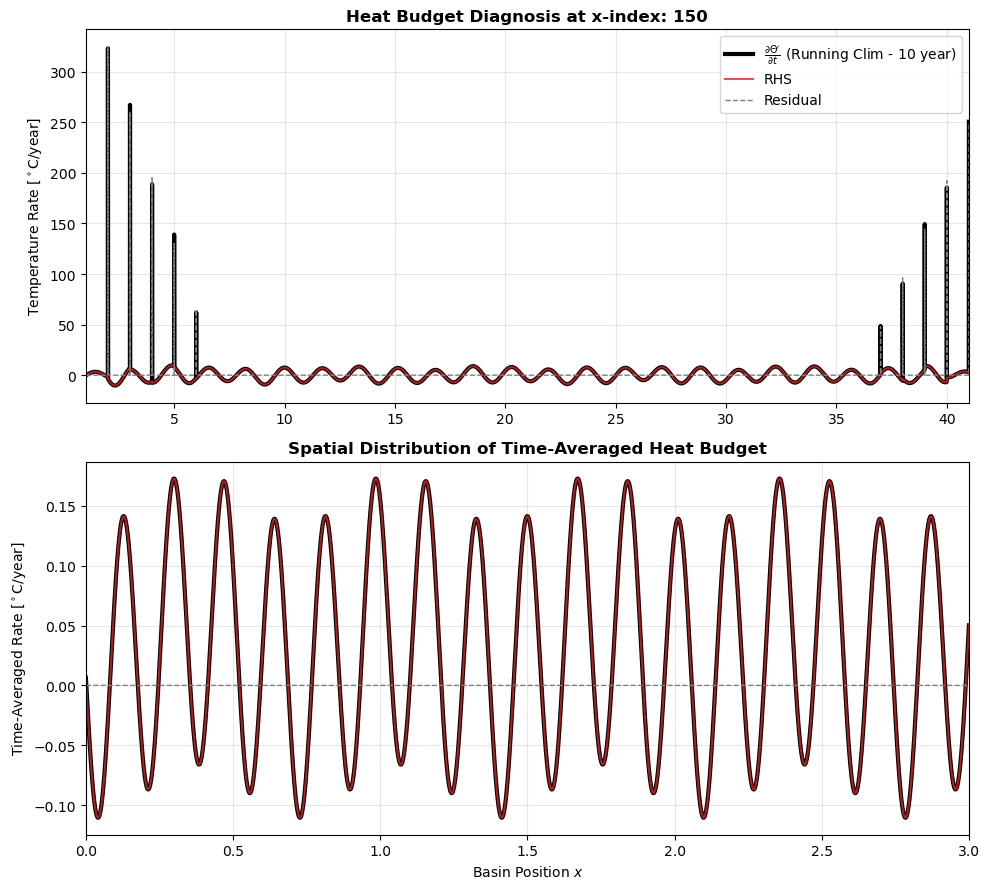

In [35]:
import matplotlib.pyplot as plt
import numpy as np

# 设置绘图参数
idx = 150
i = 6
fig, axes = plt.subplots(2, 1, figsize=(10, 9))

# --- 子图 1: 特定位置的时间序列诊断 (Time Series) ---
ax = axes[0]
ax.plot(t_daily, dTadt_runsmooth[idx], 
        label=r'$\frac{\partial{\Theta^{\prime}}}{\partial{t}}$' + ' (Running Clim - 10 year)', 
        linewidth=3, color='k')
ax.plot(t_daily, RHS_runsmooth[idx], 
        label='RHS', color='tab:red', alpha=0.8)
ax.plot(t_daily, (dTadt_runsmooth - RHS_runsmooth)[idx], 
        label='Residual', linewidth=1, color='gray', linestyle='--')

ax.set_xlim(1, 41)
ax.set_ylabel('Temperature Rate [$^\circ$C/year]')
ax.set_title(f'Heat Budget Diagnosis at x-index: {idx}', fontsize=12, fontweight='bold')
ax.legend(loc='upper right', frameon=True)
ax.grid(True, alpha=0.3)

# --- 子图 2: 时间平均的空间分布诊断 (Spatial Profile) ---
ax = axes[1]
# 注意：np.mean(..., axis=1) 假设数据形状为 [space, time]
ax.plot(x, np.mean(dTadt_runsmooth[:,i*yearlyNt:-i*yearlyNt], axis=1), 
        label=r'$\frac{\partial{\Theta^{\prime}}}{\partial{t}}$' + ' (Running Clim)', 
        linewidth=3, color='k')
ax.plot(x, np.mean(RHS_runsmooth[:,i*yearlyNt:-i*yearlyNt], axis=1), 
        label='RHS', color='tab:red', alpha=0.8)
ax.plot(x, np.mean(dTadt_runsmooth[:,i*yearlyNt:-i*yearlyNt] - RHS_runsmooth[:,i*yearlyNt:-i*yearlyNt], axis=1), 
        label='Residual', linewidth=1, color='gray', linestyle='--')

ax.set_xlim(0, 3)
ax.set_xlabel('Basin Position $x$')
ax.set_ylabel('Time-Averaged Rate [$^\circ$C/year]')
ax.set_title('Spatial Distribution of Time-Averaged Heat Budget', fontsize=12, fontweight='bold')
#ax.legend(loc='upper right', frameon=True)
ax.grid(True, alpha=0.3)

# 自动调整布局，防止标题和坐标轴重叠
plt.tight_layout()
plt.show()

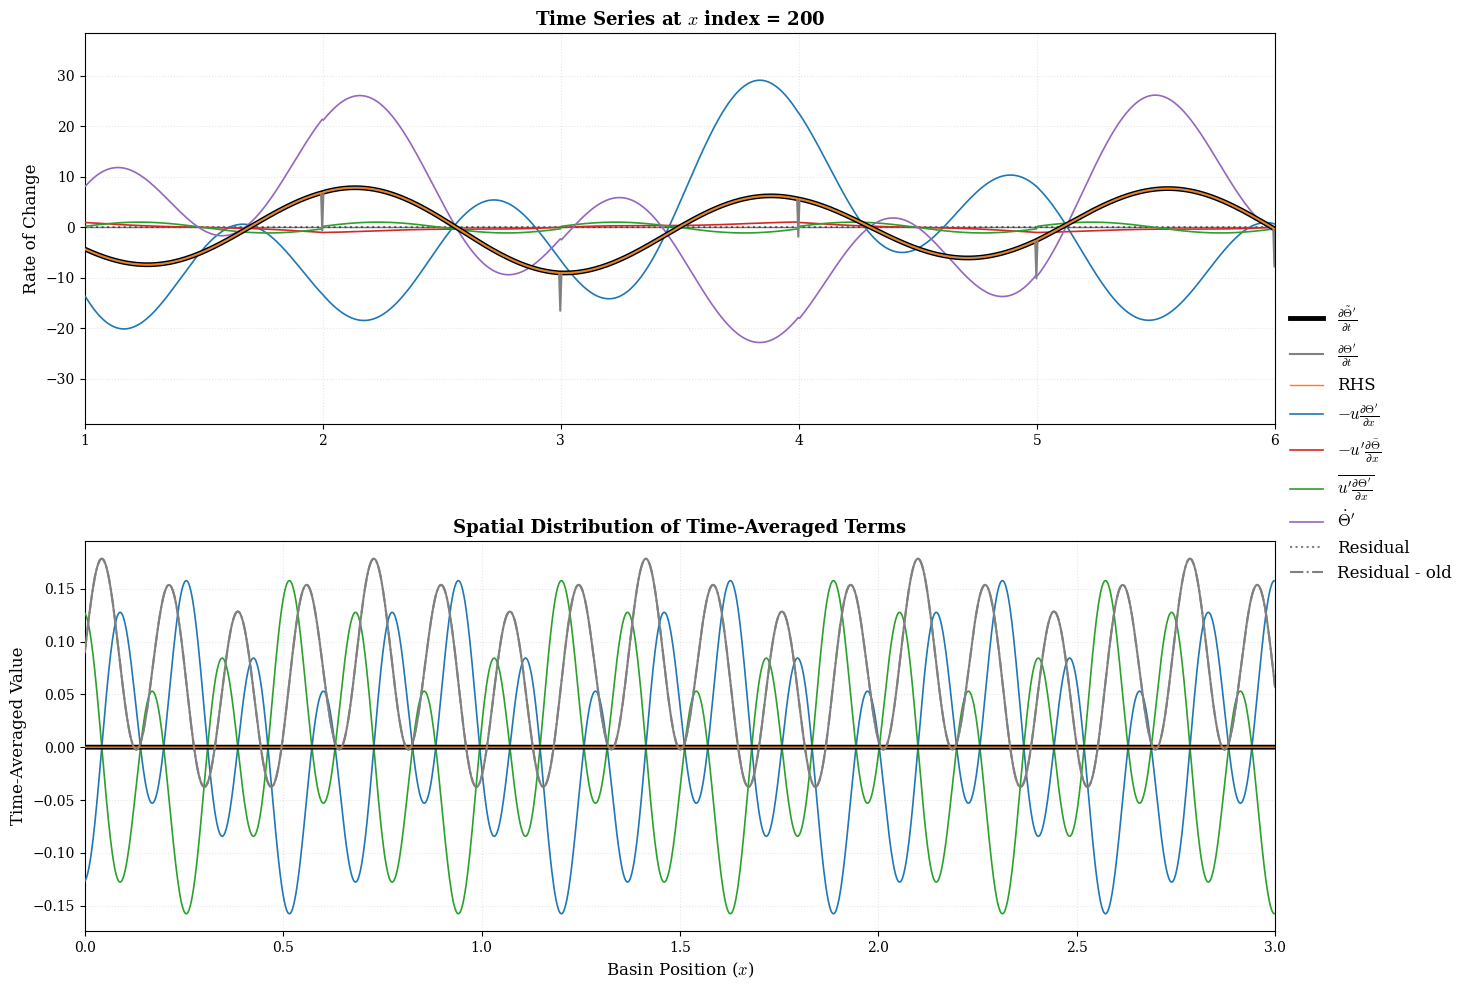

In [70]:
import matplotlib.pyplot as plt
import numpy as np

# 设置全局物理公式字体
plt.rcParams.update({
    "mathtext.fontset": "cm",
    "font.family": "serif"
})

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

# 空间索引和位置
x_idx = 200 

# 定义物理项列表: (数据矩阵, 标签, 颜色, 线宽, 层级)
items = [
    (dTwadt, r'$\frac{\partial{\tilde{\Theta}^{\prime}}}{\partial{t}}$', 'black', 3.5, 9),
    (dTadt, r'$\frac{\partial{\Theta^{\prime}}}{\partial{t}}$', 'grey', 1.5, 9),
    (RHS, 'RHS', 'tab:orange', 1, 9),
    (uTxanom, r'$-u\frac{\partial{\Theta^{\prime}}}{\partial{x}}$', 'tab:blue', 1.2, 5),
    (upTxbar, r'$-u^{\prime}\frac{\partial{\bar{\Theta}}}{\partial{x}}$', 'tab:red', 1.2, 5),
    (upTxp_bar, r'$\overline{u^{\prime}\frac{\partial{\Theta^{\prime}}}{\partial{x}}}$', 'tab:green', 1.2, 5),
    (Tdotdaily_anom, r'$\dot{\Theta}^{\prime}$', 'tab:purple', 1.2, 5),
]

# --- 子图 1: 时间序列 (固定在 x_idx) ---
for data, label, color, lw, zo in items:
    ax1.plot(t_daily, data[x_idx], label=label, color=color, lw=lw, zorder=zo)

ax1.plot(t_daily, (dTwadt - RHS)[x_idx], color='grey', linestyle=':', alpha=1,label='Residual')
ax1.set_xlim(1, 6) # 保持你要求的时间范围
ax1.set_ylabel('Rate of Change', fontsize=12)
ax1.set_title(f'Time Series at $x$ index = {x_idx}', fontsize=13, fontweight='bold')
ax1.grid(True, linestyle=':', alpha=0.3)
ax1.axhline(0, color='black', lw=1, alpha=0.5)

# --- 子图 2: 空间分布 (时间平均量 ⟨·⟩ 沿 x 轴) ---
# 计算时间维度的平均值 (假设 axis=1 是时间轴)

for data, label, color, lw, zo in items:
    # 对所有时间步取平均，得到一根关于 x 的曲线
    spatial_data = np.mean(data, axis=1) 
    ax2.plot(x, spatial_data, label=label, color=color, lw=lw, zorder=zo)

# 残差的空间分布
res_spatial = np.mean(dTwadt - RHS, axis=1)
ax2.plot(x, res_spatial, color='grey', linestyle=':', alpha=1,label='Residual')
res_spatial2 = np.mean(dTadt - RHS, axis=1)
ax2.plot(x, res_spatial2, color='grey', linestyle='-.', alpha=1,label='Residual - old')

ax2.set_ylabel('Time-Averaged Value', fontsize=12)
ax2.set_xlabel('Basin Position ($x$)', fontsize=12)
ax2.set_title(r'Spatial Distribution of Time-Averaged Terms', fontsize=13, fontweight='bold')
ax2.grid(True, linestyle=':', alpha=0.3)
ax2.axhline(0, color='black', lw=1, alpha=0.5)
ax2.set_xlim(x[0], x[-1])

# 图例统一放置在右侧
ax2.legend(fontsize=12, loc='center left', bbox_to_anchor=(1, 1.25), frameon=False)

plt.tight_layout()
plt.subplots_adjust(right=0.8, hspace=0.3) 
#plt.savefig('anomaly_budget_revisetrend.png')
plt.show()


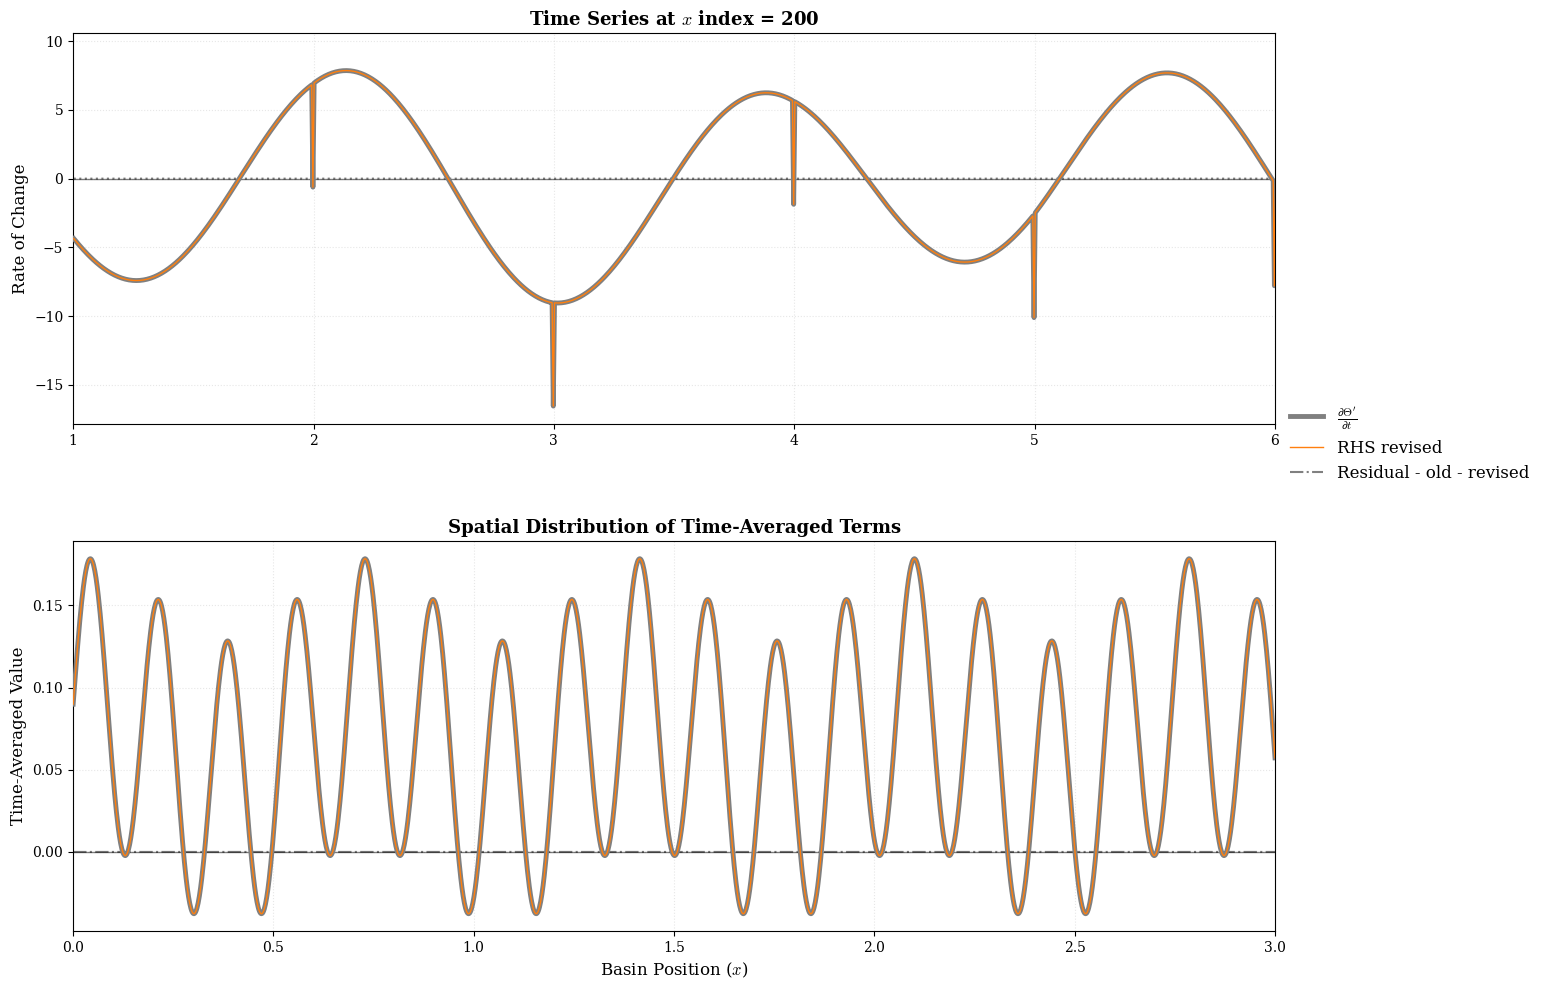

In [83]:
import matplotlib.pyplot as plt
import numpy as np

# 设置全局物理公式字体
plt.rcParams.update({
    "mathtext.fontset": "cm",
    "font.family": "serif"
})

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

# 空间索引和位置
x_idx = 200 

# 定义物理项列表: (数据矩阵, 标签, 颜色, 线宽, 层级)
items = [
    #(dTwadt, r'$\frac{\partial{\tilde{\Theta}^{\prime}}}{\partial{t}}$', 'black', 3.5, 9),
    (dTadt, r'$\frac{\partial{\Theta^{\prime}}}{\partial{t}}$', 'grey', 3.5, 9),
    (RHS2, 'RHS revised', 'tab:orange', 1, 9),
#    (uTxanom, r'$-u\frac{\partial{\Theta^{\prime}}}{\partial{x}}$', 'tab:blue', 1.2, 5),
#    (upTxbar, r'$-u^{\prime}\frac{\partial{\bar{\Theta}}}{\partial{x}}$', 'tab:red', 1.2, 5),
#    (upTxp_bar, r'$\overline{u^{\prime}\frac{\partial{\Theta^{\prime}}}{\partial{x}}}$', 'tab:green', 1.2, 5),
#    (Tdotdaily_anom, r'$\dot{\Theta}^{\prime}$', 'tab:purple', 1.2, 5),
]

# --- 子图 1: 时间序列 (固定在 x_idx) ---
for data, label, color, lw, zo in items:
    ax1.plot(t_daily, data[x_idx], label=label, color=color, lw=lw, zorder=zo)

ax1.plot(t_daily, (dTadt - RHS2)[x_idx], color='grey', linestyle=':', alpha=1,label='Residual')
ax1.set_xlim(1, 6) # 保持你要求的时间范围
ax1.set_ylabel('Rate of Change', fontsize=12)
ax1.set_title(f'Time Series at $x$ index = {x_idx}', fontsize=13, fontweight='bold')
ax1.grid(True, linestyle=':', alpha=0.3)
ax1.axhline(0, color='black', lw=1, alpha=0.5)

# --- 子图 2: 空间分布 (时间平均量 ⟨·⟩ 沿 x 轴) ---
# 计算时间维度的平均值 (假设 axis=1 是时间轴)

for data, label, color, lw, zo in items:
    # 对所有时间步取平均，得到一根关于 x 的曲线
    spatial_data = np.mean(data, axis=1) 
    ax2.plot(x, spatial_data, label=label, color=color, lw=lw, zorder=zo)

# 残差的空间分布
#res_spatial = np.mean(dTwadt - RHS, axis=1)
#ax2.plot(x, res_spatial, color='grey', linestyle=':', alpha=1,label='Residual')
res_spatial2 = np.mean(dTadt - RHS2, axis=1)
ax2.plot(x, res_spatial2, color='grey', linestyle='-.', alpha=1,label='Residual - old - revised')

ax2.set_ylabel('Time-Averaged Value', fontsize=12)
ax2.set_xlabel('Basin Position ($x$)', fontsize=12)
ax2.set_title(r'Spatial Distribution of Time-Averaged Terms', fontsize=13, fontweight='bold')
ax2.grid(True, linestyle=':', alpha=0.3)
ax2.axhline(0, color='black', lw=1, alpha=0.5)
ax2.set_xlim(x[0], x[-1])

# 图例统一放置在右侧
ax2.legend(fontsize=12, loc='center left', bbox_to_anchor=(1, 1.25), frameon=False)

plt.tight_layout()
plt.subplots_adjust(right=0.8, hspace=0.3) 
#plt.savefig('anomaly_budget_revisetrend.png')
plt.show()


# 2d [x z t] case

## dt 需要被年循环整除，否则导致每年内数据的t的相位错位

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# =================================================================
# 1. 网格配置 (3D Grid Configuration)
# =================================================================
dx, x_max = 0.0035, 3.0
x = np.arange(0, x_max + dx, dx)
Nx = len(x)

Nz, z_max, alpha = 50, 4000.0, 3.0
eta = np.linspace(0, 1, Nz)
dz_cumulative = (np.exp(alpha*eta) - 1)/(np.exp(alpha) - 1) * z_max
z_coords = np.zeros(Nz)
z_coords[0] = 0.5 * dz_cumulative[0] + 3.0
for k in range(1, Nz):
    z_coords[k] = (dz_cumulative[k] + dz_cumulative[k-1])/2
z_norm = z_coords / z_max

dt, t_max = 0.05, 41
t = np.arange(1, t_max + dt, dt)
Nt = len(t)

# 生成 3D Meshgrid: (Nx, Nz, Nt)
x3, z3, t3 = np.meshgrid(x, z_norm, t, indexing='ij')

# =================================================================
# 2. 参数与垂向结构函数
# =================================================================
p = {
    'omega1': 2*np.pi, 'omega2': 2*np.pi/2.7, 'omega3': 2*np.pi/3,
    'a1': 1.0, 'a2': 0.5, 'a3': 2.0, 'a4': 1.0, 'a5': 4.5,
    'c': 15.0, 'cp': 0.1, 'u0': 0.08,
    'b_linear': 0.04,  #0.04
    'b_accel': 0.003, #0.003
    'amp_low': 0.4, # 0.4
    'omega_low': 2*np.pi/50, 'phase_low': 1.0,
    'dTdx_back': -3.0,
}
p['k1'] = (2 * np.pi) / (x_max / 17.5)
p['k2'] = p['k1'] * 0.25

# 预计算垂向结构 (注意：这些是 3D 阵列)
f_z_3d = 1.0 * (1 - np.tanh((z3 - 100.0/z_max) / (1000.0/z_max))) 
g_z_3d = np.exp(-z3 / (1000.0/z_max))

# =================================================================
# 3. 瞬时场计算 (Snapshots)
# =================================================================
# 用于获取每一秒/每一格点的精确物理状态
phi_w1 = p['k1'] * (x3 - p['cp'] * t3)
phi_w2 = p['k2'] * (x3 - p['cp'] * t3)
phi_low = p['omega_low'] * t3 + p['phase_low']

# 瞬时 T, u, Tx
T_trend = p['b_linear'] * t3 + p['b_accel'] * t3**2 + p['amp_low'] * np.sin(phi_low)
T_snap = (p['a1'] * np.cos(p['omega1'] * t3) + p['a2'] * np.cos(p['omega2'] * t3) + 
          p['a3'] * np.sin(phi_w1) + p['a4'] * np.sin(phi_w2) + 
          p['dTdx_back'] * x3 + T_trend + p['c']) * f_z_3d

u_snap = p['u0'] * (1 + p['a5'] * np.sin(p['omega3'] * t3)) * g_z_3d
Tx_snap = (p['a3'] * p['k1'] * np.cos(phi_w1) + p['a4'] * p['k2'] * np.cos(phi_w2) + p['dTdx_back']) * f_z_3d

# 瞬时项
uTx_snap = u_snap * Tx_snap
dT_trend_dt = (p['b_linear'] + 2 * p['b_accel'] * t3 + p['amp_low'] * p['omega_low'] * np.cos(phi_low))
Tt_snap = (-p['a1'] * p['omega1'] * np.sin(p['omega1'] * t3) - 
            p['a2'] * p['omega2'] * np.sin(p['omega2'] * t3) - 
            p['a3'] * p['k1'] * p['cp'] * np.cos(phi_w1) - 
            p['a4'] * p['k2'] * p['cp'] * np.cos(phi_w2) + 
            dT_trend_dt) * f_z_3d
Tdot_snap = Tt_snap + uTx_snap

# =================================================================
# 4. 解析积分函数 (你指定的 5 项逻辑)
# =================================================================
def get_integrated_fields_3d(x_m, z_m, t_m, p, f_z, g_z):
    phi_w1 = p['k1'] * (x_m - p['cp'] * t_m)
    phi_w2 = p['k2'] * (x_m - p['cp'] * t_m)
    phi_low = p['omega_low'] * t_m + p['phase_low']
    
    # --- A. 温度 T 的时间积分 ---
    int_T_trend = (0.5 * p['b_linear'] * t_m**2 + (1/3.0) * p['b_accel'] * t_m**3 - 
                   (p['amp_low'] / p['omega_low']) * np.cos(phi_low))
    int_T_spatial = p['dTdx_back'] * x_m * t_m
    int_T_surf = ( (p['a1']/p['omega1']) * np.sin(p['omega1']*t_m) + 
                   (p['a2']/p['omega2']) * np.sin(p['omega2']*t_m) +
                   (p['a3']/(p['k1']*p['cp'])) * np.cos(phi_w1) + 
                   (p['a4']/(p['k2']*p['cp'])) * np.cos(phi_w2) +
                   int_T_trend + int_T_spatial + p['c']*t_m )
    int_T_3d = int_T_surf * f_z
    
    # --- B. 空间梯度 Tx 的时间积分 ---
    int_Tx_surf = (-(p['a3'] / p['cp']) * np.sin(phi_w1) - 
                   (p['a4'] / p['cp']) * np.sin(phi_w2) + 
                   p['dTdx_back'] * t_m)
    int_Tx_3d = int_Tx_surf * f_z
    
    # --- C. 流速 u 的时间积分 ---
    int_u_3d = (p['u0'] * t_m - (p['u0'] * p['a5'] / p['omega3']) * np.cos(p['omega3'] * t_m)) * g_z
    
    # --- D. 平流项 uTx 的时间积分 ---
    def calc_wave_adv_integral(k_val, a_val):
        f_plus, f_minus = p['omega3'] - k_val*p['cp'], p['omega3'] + k_val*p['cp']
        p_plus = p['omega3']*t_m + k_val*(x_m - p['cp']*t_m)
        p_minus = p['omega3']*t_m - k_val*(x_m - p['cp']*t_m)
        coeff = (p['u0'] * p['a5'] * a_val * k_val) / 2.0
        u_prime_wave = coeff * (-np.cos(p_plus)/f_plus - np.cos(p_minus)/f_minus)
        u0_wave = -(p['u0'] * a_val / p['cp']) * np.sin(k_val*(x_m - p['cp']*t_m))
        return u_prime_wave + u0_wave

    term_u_back_int = (p['u0'] * t_m - (p['u0'] * p['a5'] / p['omega3']) * np.cos(p['omega3'] * t_m)) * p['dTdx_back']
    int_uTx_3d = (calc_wave_adv_integral(p['k1'], p['a3']) + 
                  calc_wave_adv_integral(p['k2'], p['a4']) + 
                  term_u_back_int) * (f_z * g_z)
    
    # --- E. 全导数 Tdot 的积分 ---
    T_surf_instant = (p['a1'] * np.cos(p['omega1'] * t_m) + p['a2'] * np.cos(p['omega2'] * t_m) + 
                      p['a3'] * np.sin(phi_w1) + p['a4'] * np.sin(phi_w2) + 
                      (p['b_linear'] * t_m + p['b_accel'] * t_m**2 + p['amp_low'] * np.sin(phi_low)) + 
                      p['dTdx_back'] * x_m + p['c'])
    int_Tdot_3d = T_surf_instant * f_z + int_uTx_3d
    
    return int_T_3d, int_Tx_3d, int_u_3d, int_uTx_3d, int_Tdot_3d

# 执行积分获取原函数
int_T, int_Tx, int_u, int_uTx, int_Tdot = get_integrated_fields_3d(x3, z3, t3, p, f_z_3d, g_z_3d)

# =================================================================
# 5. 时步平均场计算 (Daily Averages)
# =================================================================
T_avg = (int_T[:,:,1:] - int_T[:,:,0:-1]) / dt
Tx_avg = (int_Tx[:,:,1:] - int_Tx[:,:,0:-1]) / dt
u_avg = (int_u[:,:,1:] - int_u[:,:,0:-1]) / dt
uTx_avg = (int_uTx[:,:,1:] - int_uTx[:,:,0:-1]) / dt
Tdot_avg = (int_Tdot[:,:,1:] - int_Tdot[:,:,0:-1]) / dt

t_daily = (t[1:] + t[:-1]) / 2

# =================================================================
# 6. 验证与诊断绘制
# =================================================================
print(f"数据准备完成。")
print(f"Snapshot 形状: {T_snap.shape}") # (Nx, Nz, Nt)
print(f"Average 形状: {T_avg.shape}")   # (Nx, Nz, Nt-1)



数据准备完成。
Snapshot 形状: (859, 50, 801)
Average 形状: (859, 50, 800)


In [2]:
0.04/1*365

14.6

In [3]:
1/0.04

25.0

In [16]:
dt/1*365*86400*(dx/dt)

110375.99999999999

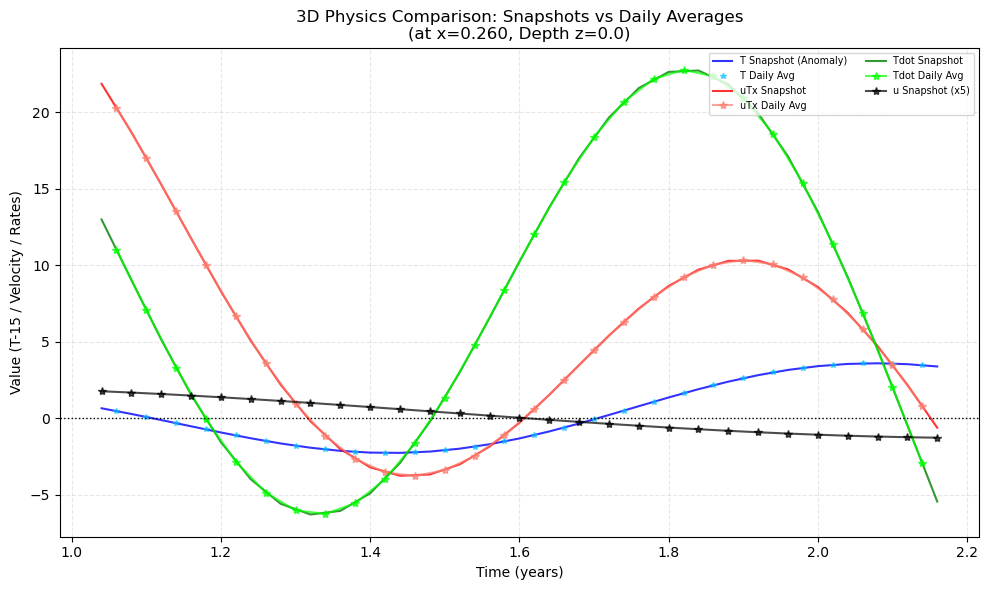

In [6]:
import matplotlib.pyplot as plt

# 调整画布大小，确保信息清晰
plt.figure(figsize=(10, 6))

# 定义索引范围和空间位置
# 为了展示波动的相位差，建议稍微扩大 idx 范围
idx_t = slice(1, 30)         # 瞬时场索引
idx_d = slice(1, 29)         # 平均场索引（比瞬时场少一个点）
x_pos = 100                  # 空间位置索引
z_pos = 5                    # 浅层索引，波动较明显

# 基准值
T_mean = 15.0

# 1. 温度 T (蓝色)
plt.plot(t[idx_t], T_snap[x_pos, z_pos, idx_t] - T_mean, 
         color='blue', linestyle='-', label='T Snapshot (Anomaly)', alpha=0.8)
plt.plot(t_daily[idx_d], T_avg[x_pos, z_pos, idx_d] - T_mean, 
         color='deepskyblue', linestyle='None', marker='*', markersize=4, label='T Daily Avg', alpha=0.6)

# 2. 平流项 uTx (红色)
plt.plot(t[idx_t], uTx_snap[x_pos, z_pos, idx_t], 
         color='red', linestyle='-', label='uTx Snapshot', alpha=0.8)
plt.plot(t_daily[idx_d], uTx_avg[x_pos, z_pos, idx_d], 
         color='salmon', marker='*', linewidth=1.5, label='uTx Daily Avg', alpha=0.7)

# 3. 全导数 Tdot (绿色)
plt.plot(t[idx_t], Tdot_snap[x_pos, z_pos, idx_t], 
         color='green', linestyle='-', label='Tdot Snapshot', alpha=0.8)
plt.plot(t_daily[idx_d], Tdot_avg[x_pos, z_pos, idx_d], 
         color='lime', marker='*', linewidth=1.5, label='Tdot Daily Avg', alpha=0.7)

# 4. 流速 u (黑色/灰色) - 放大 5 倍以适应量级
plt.plot(t[idx_t], u_snap[x_pos, z_pos, idx_t] * 5, 
         color='black', marker='*', label='u Snapshot (x5)', alpha=0.7)

# 图形修饰
plt.axhline(0, color='black', linewidth=1, linestyle=':')
plt.title(f'3D Physics Comparison: Snapshots vs Daily Averages\n(at x={x[x_pos]:.3f}, Depth z={z_norm[z_pos]:.1f})')
plt.xlabel('Time (years)')
plt.ylabel('Value (T-15 / Velocity / Rates)')
plt.legend(loc='upper right', fontsize='x-small', ncol=2, frameon=True)
plt.grid(True, which='both', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


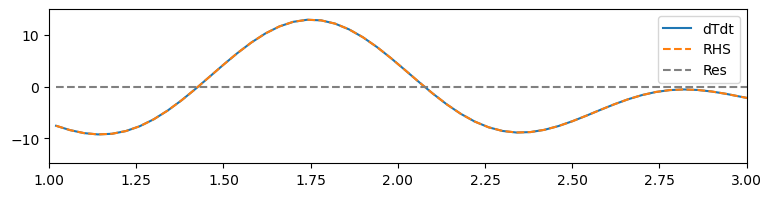

In [7]:
plt.figure(figsize=(9, 2))
plt.plot(t_daily, (T_snap[100,10,1:]-T_snap[100,10,0:-1])/dt, label='dTdt' )
plt.plot(t_daily, (Tdot_avg[100,10,:]-uTx_avg[100,10,:]), label='RHS',linestyle='--' )
plt.plot(t_daily, (T_snap[100,10,1:]-T_snap[100,10,0:-1])/dt-(Tdot_avg[100,10,:]-uTx_avg[100,10,:]), label='Res',linestyle='--',color='grey' )
plt.xlim(1,3)
plt.legend()
plt.show()

In [3]:
# =================================================================
# 3D Budget Analysis 
# =================================================================

# 1. 基本参数
yearlyNt = int(np.round(2 * np.pi / p['omega1'] / dt)) # 每年格点数
nyear = int(len(t_daily)/yearlyNt)         # 总年数
shape_rest = T_snap.shape[0:2]             # 空间维度为 (Nx, Nz)

#a.  detrend
# 1). 计算每个格点的斜率，形状为 (Nx, Nz)
slope = (T_snap[..., -1] - T_snap[..., 0]) / (t[-1] - t[0])
# 2). 将斜率在第3维增加一个轴，形状变为 (Nx, Nz, 1), 再与 t (Nt,) 进行广播相乘，结果自动变为 (Nx, Nz, Nt)
Tanb = slope[..., np.newaxis] * t3

#Tanb_daily =  ((T[:, -1] - T[:, 0]) / (t[-1] - t[0]))[:, np.newaxis] * t2_daily

Tdotanb = np.mean(Tdot_avg - uTx_avg, axis=-1)[..., np.newaxis] * t_daily
Twave = T_snap - Tanb   # detrend

## T anom 
Twave_bar = calc_cyclic_mean(Twave.transpose(2,0,1), nyear,yearlyNt, shape_rest, smooth=0, smooth_window=1).transpose(1,2,0)
Twave_bar_pure = cal_cyclic_mean_pure(Twave.transpose(2,0,1), nyear, yearlyNt, shape_rest, smooth=0).transpose(1,2,0)
Twave_anom = Twave - Twave_bar_pure

T_bar_pure = cal_cyclic_mean_pure(T_snap.transpose(2,0,1), nyear, yearlyNt, shape_rest, smooth=0).transpose(1,2,0)
T_anom = T_snap - T_bar_pure

T_avg_bar_pure = cal_cyclic_mean_pure(T_avg.transpose(2,0,1), nyear, yearlyNt, shape_rest, smooth=0).transpose(1,2,0)
T_avg_anom = T_avg - T_avg_bar_pure

## dTdt
dTadt  =  (T_anom[...,1:] - T_anom[...,0:-1])/dt
dTwadt =  (Twave_anom[...,1:] - Twave_anom[...,0:-1])/dt

## 
Tanb_bar_pure = cal_cyclic_mean_pure(Tanb.transpose(2,0,1), nyear, yearlyNt, shape_rest, smooth=0).transpose(1,2,0)
Tanb_anom = Tanb - Tanb_bar_pure

dTabadt = (Tanb_anom[...,1:] - Tanb_anom[...,0:-1])/dt

#Tanb_daily_bar_pure = cal_cyclic_mean_pure(Tanb_daily.T, nyear, yearlyNt, shape_rest, smooth=0).T
#Tanb_daily_anom = Tanb_daily - Tanb_daily_bar_pure

## u_bar Tx_bar uTx_bar
udaily_bar_pure   = cal_cyclic_mean_pure(u_avg.transpose(2,0,1), nyear, yearlyNt, shape_rest, smooth=0).transpose(1,2,0)
uTxdaily_bar_pure = cal_cyclic_mean_pure(uTx_avg.transpose(2,0,1), nyear, yearlyNt, shape_rest, smooth=0).transpose(1,2,0)
Txdaily_bar_pure  = cal_cyclic_mean_pure(Tx_avg.transpose(2,0,1), nyear, yearlyNt, shape_rest, smooth=0).transpose(1,2,0)

udaily_anom = u_avg - udaily_bar_pure
Txdaily_anom = Tx_avg - Txdaily_bar_pure

upTxp_bar = uTxdaily_bar_pure - udaily_bar_pure*Txdaily_bar_pure
upTxbar = -(udaily_anom * Txdaily_bar_pure)
uTxanom = -(u_avg * Txdaily_anom)

## Tdot
Tdotdaily_bar_pure  = cal_cyclic_mean_pure(Tdot_avg.transpose(2,0,1), nyear, yearlyNt, shape_rest, smooth=0).transpose(1,2,0)
Tdotdaily_anom = Tdot_avg - Tdotdaily_bar_pure

## RHS
RHS  = uTxanom + upTxbar + upTxp_bar + Tdotdaily_anom 
RHS2 = uTxanom + upTxbar + upTxp_bar + Tdotdaily_anom + dTabadt



In [4]:
import xarray as xr

# Create a dictionary of your data variables
# Note: Ensure time dimensions match (some of your dT/dt terms might be Nt-1)
data_vars = {
    "T_snap_anom": (["x", "z", "time_snap"], T_anom),
    "T_avg_anom": (["x", "z", "time"], T_avg_anom),
    "u_avg":   (["x", "z", "time"], u_avg),
    "dTabadt": (["x", "z", "time"], dTabadt),
    "uTxanom": (["x", "z", "time"], uTxanom),
    "upTxbar": (["x", "z", "time"], upTxbar),
    "upTxp_bar": (["x", "z", "time"], upTxp_bar),
    "Tdot_anom": (["x", "z", "time"], Tdotdaily_anom),
   
}

# Define coordinates
coords = {
    "x": x,
    "z": z_norm,
    "time": t_daily, 
    "time_snap": t  # For the forward-difference derivatives
}

# Create Dataset
ds = xr.Dataset(data_vars, coords=coords)

# Add metadata for clarity
ds.T_snap_anom.attrs = {"units": "K", "long_name": "Temperature Anomaly"}
#ds.RHS.attrs = {"units": "K/s", "long_name": "Right Hand Side Budget"}

# Save to NetCDF
#ds.to_netcdf("/pub/ranl24/2d_analytical_budgets_dx0035dt025.nc")
#ds.to_netcdf("/pub/ranl24/2d_analytical_budgets_dx0035dt01.nc")
#ds.to_netcdf("/pub/ranl24/2d_analytical_budgets_dx0025dt025_notrend.nc")
#ds.to_netcdf("/pub/ranl24/2d_analytical_budgets_dx0025dt01_notrend.nc")
#ds.to_netcdf("/pub/ranl24/2d_analytical_budgets_dx0035dt1.nc")

print("Dataset saved successfully.")

Dataset saved successfully.


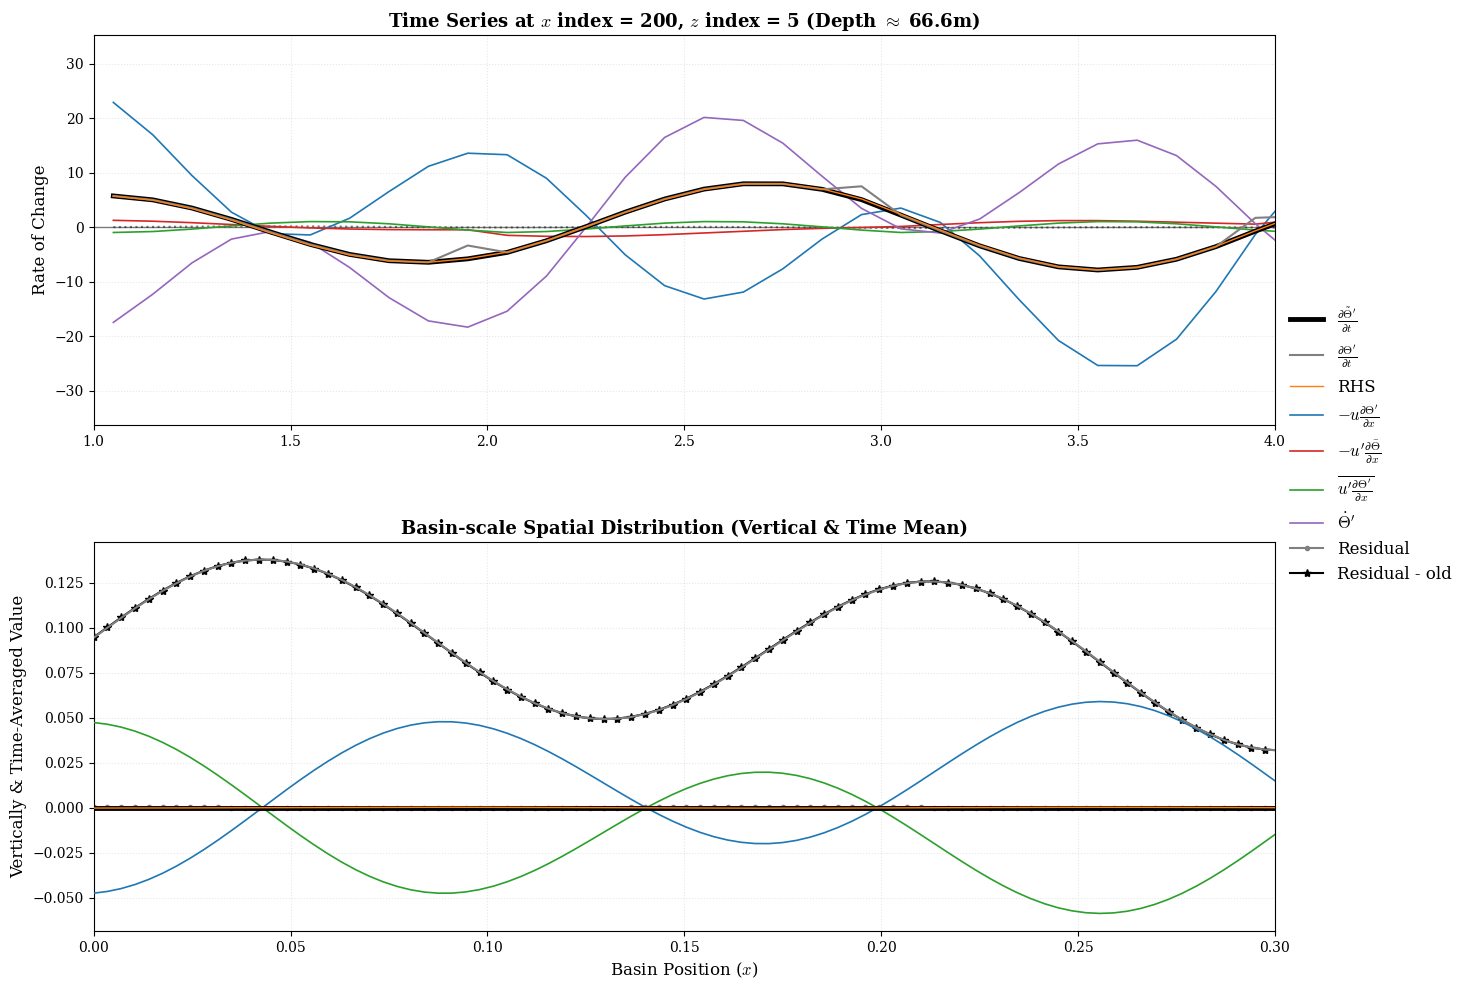

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# 设置全局物理公式字体
plt.rcParams.update({
    "mathtext.fontset": "cm",
    "font.family": "serif"
})

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

# --- 3D 索引设置 ---
x_idx = 200  
z_idx = 5    # 选择一个深度索引 (例如浅层，波动最明显)

# 定义物理项列表 (针对 3D 数据 Nx, Nz, Nt)
# 这里假设你的数据已经计算好，形状为 (Nx, Nz, Nt_daily)
items = [
    (dTwadt, r'$\frac{\partial{\tilde{\Theta}^{\prime}}}{\partial{t}}$', 'black', 3.5, 9),
    (dTadt, r'$\frac{\partial{\Theta^{\prime}}}{\partial{t}}$', 'grey', 1.5, 9),
    (RHS, 'RHS', 'tab:orange', 1, 9),
    (uTxanom, r'$-u\frac{\partial{\Theta^{\prime}}}{\partial{x}}$', 'tab:blue', 1.2, 5),
    (upTxbar, r'$-u^{\prime}\frac{\partial{\bar{\Theta}}}{\partial{x}}$', 'tab:red', 1.2, 5),
    (upTxp_bar, r'$\overline{u^{\prime}\frac{\partial{\Theta^{\prime}}}{\partial{x}}}$', 'tab:green', 1.2, 5),
    (Tdotdaily_anom, r'$\dot{\Theta}^{\prime}$', 'tab:purple', 1.2, 5),
]

# --- 子图 1: 时间序列 (固定在 x_idx, z_idx) ---
for data, label, color, lw, zo in items:
    # 提取特定格点的 1D 时间序列: data[x_idx, z_idx, :]
    ax1.plot(t_daily, data[x_idx, z_idx, :], label=label, color=color, lw=lw, zorder=zo)

# 残差计算 (注意维度匹配)
residual_ts = (dTwadt - RHS)[x_idx, z_idx, :]
ax1.plot(t_daily, residual_ts, color='grey', linestyle=':', alpha=1, label='Residual')

ax1.set_xlim(1, 4) 
ax1.set_ylabel('Rate of Change', fontsize=12)
ax1.set_title(f'Time Series at $x$ index = {x_idx}, $z$ index = {z_idx} (Depth $\\approx$ {z_coords[z_idx]:.1f}m)', fontsize=13, fontweight='bold')
ax1.grid(True, linestyle=':', alpha=0.3)
ax1.axhline(0, color='black', lw=1, alpha=0.5)

# --- 子图 2: 空间分布 (时间平均量 ⟨·⟩ 沿 x 轴) ---
# 在 3D 中，通常对时间 (axis=2) 取平均，并对垂直维度 (axis=1) 取平均以看海盆整体情况
# 如果你想看特定深度，可以改为 spatial_data = np.mean(data[:, z_idx, :], axis=1)

for data, label, color, lw, zo in items:
    # 1. 对时间轴 (axis=2) 取平均 -> 得到 (Nx, Nz)
    # 2. 对垂直轴 (axis=1) 取平均 -> 得到 (Nx,)
    spatial_mean = np.mean(np.mean(data, axis=2), axis=1)
    ax2.plot(x, spatial_mean, label=label, color=color, lw=lw, zorder=zo)

# 空间残差
res_spatial = np.mean(np.mean(dTwadt - RHS, axis=2), axis=1)
ax2.plot(x, res_spatial, color='grey', marker='.', alpha=1, label='Residual')

res_spatial2 = np.mean(np.mean(dTadt - RHS, axis=2), axis=1)
ax2.plot(x, res_spatial2, color='k', marker='*', alpha=1, label='Residual - old')

ax2.set_ylabel('Vertically & Time-Averaged Value', fontsize=12)
ax2.set_xlabel('Basin Position ($x$)', fontsize=12)
ax2.set_title(r'Basin-scale Spatial Distribution (Vertical & Time Mean)', fontsize=13, fontweight='bold')
ax2.grid(True, linestyle=':', alpha=0.3)
ax2.axhline(0, color='black', lw=1, alpha=0.5)
ax2.set_xlim(0,0.3)

# 图例统一放置
ax2.legend(fontsize=12, loc='center left', bbox_to_anchor=(1, 1.25), frameon=False)

plt.tight_layout()
plt.subplots_adjust(right=0.8, hspace=0.3) 
plt.show()

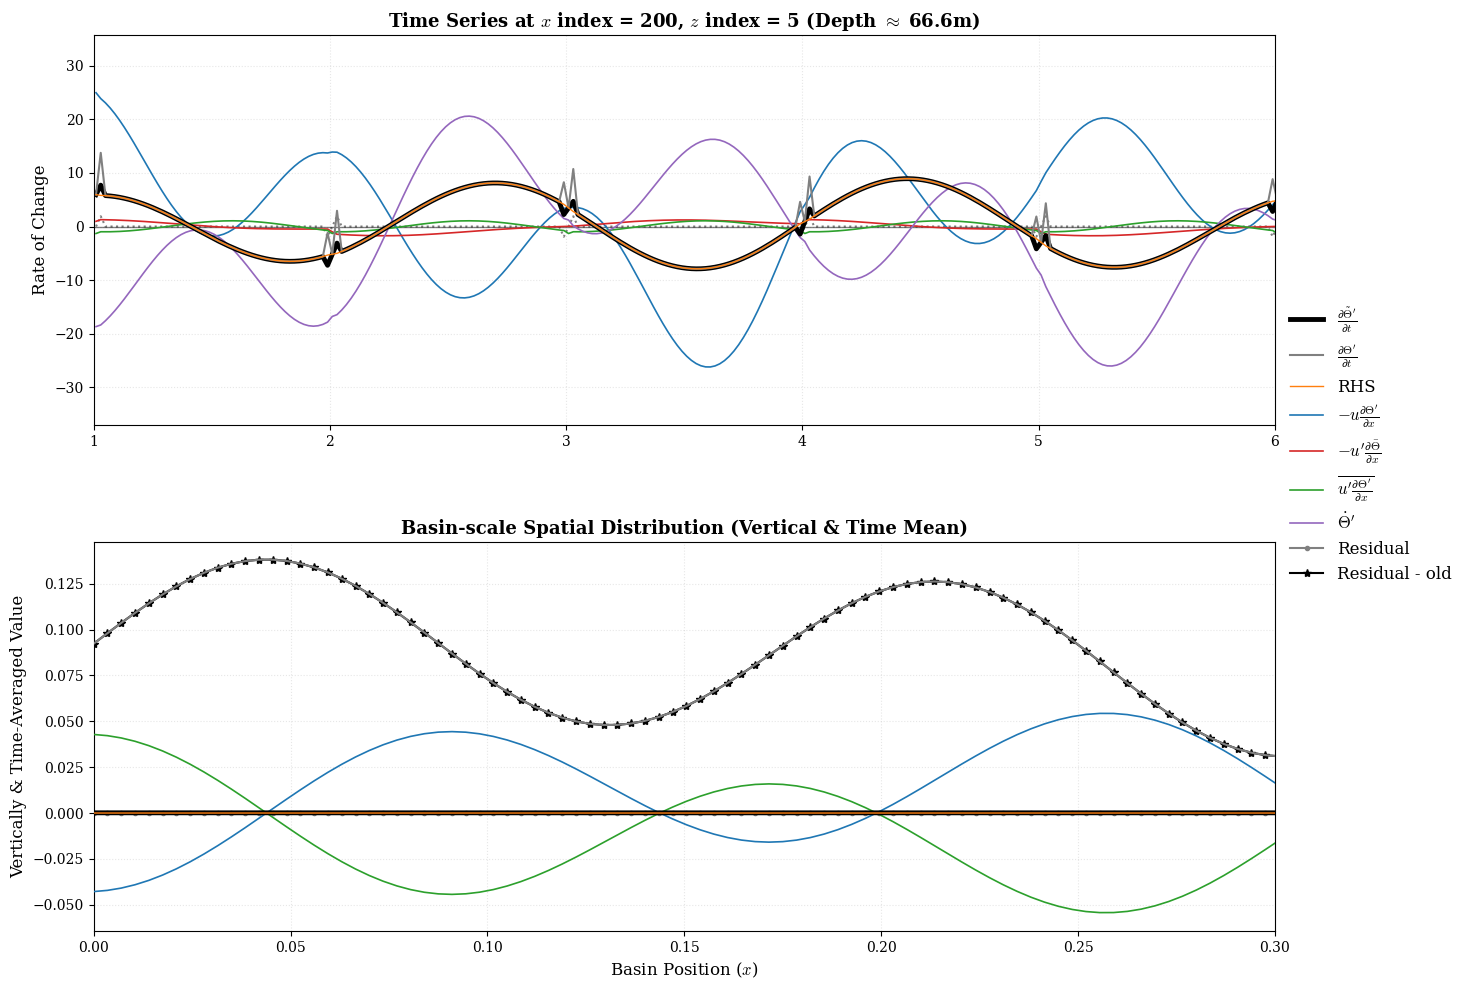

In [92]:
import matplotlib.pyplot as plt
import numpy as np

# 设置全局物理公式字体
plt.rcParams.update({
    "mathtext.fontset": "cm",
    "font.family": "serif"
})

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

# --- 3D 索引设置 ---
x_idx = 200  
z_idx = 5    # 选择一个深度索引 (例如浅层，波动最明显)

# 定义物理项列表 (针对 3D 数据 Nx, Nz, Nt)
# 这里假设你的数据已经计算好，形状为 (Nx, Nz, Nt_daily)
items = [
    (dTwadt, r'$\frac{\partial{\tilde{\Theta}^{\prime}}}{\partial{t}}$', 'black', 3.5, 9),
    (dTadt, r'$\frac{\partial{\Theta^{\prime}}}{\partial{t}}$', 'grey', 1.5, 9),
    (RHS, 'RHS', 'tab:orange', 1, 9),
    (uTxanom, r'$-u\frac{\partial{\Theta^{\prime}}}{\partial{x}}$', 'tab:blue', 1.2, 5),
    (upTxbar, r'$-u^{\prime}\frac{\partial{\bar{\Theta}}}{\partial{x}}$', 'tab:red', 1.2, 5),
    (upTxp_bar, r'$\overline{u^{\prime}\frac{\partial{\Theta^{\prime}}}{\partial{x}}}$', 'tab:green', 1.2, 5),
    (Tdotdaily_anom, r'$\dot{\Theta}^{\prime}$', 'tab:purple', 1.2, 5),
]

# --- 子图 1: 时间序列 (固定在 x_idx, z_idx) ---
for data, label, color, lw, zo in items:
    # 提取特定格点的 1D 时间序列: data[x_idx, z_idx, :]
    ax1.plot(t_daily, data[x_idx, z_idx, :], label=label, color=color, lw=lw, zorder=zo)

# 残差计算 (注意维度匹配)
residual_ts = (dTwadt - RHS)[x_idx, z_idx, :]
ax1.plot(t_daily, residual_ts, color='grey', linestyle=':', alpha=1, label='Residual')

ax1.set_xlim(1, 6) 
ax1.set_ylabel('Rate of Change', fontsize=12)
ax1.set_title(f'Time Series at $x$ index = {x_idx}, $z$ index = {z_idx} (Depth $\\approx$ {z_coords[z_idx]:.1f}m)', fontsize=13, fontweight='bold')
ax1.grid(True, linestyle=':', alpha=0.3)
ax1.axhline(0, color='black', lw=1, alpha=0.5)

# --- 子图 2: 空间分布 (时间平均量 ⟨·⟩ 沿 x 轴) ---
# 在 3D 中，通常对时间 (axis=2) 取平均，并对垂直维度 (axis=1) 取平均以看海盆整体情况
# 如果你想看特定深度，可以改为 spatial_data = np.mean(data[:, z_idx, :], axis=1)

for data, label, color, lw, zo in items:
    # 1. 对时间轴 (axis=2) 取平均 -> 得到 (Nx, Nz)
    # 2. 对垂直轴 (axis=1) 取平均 -> 得到 (Nx,)
    spatial_mean = np.mean(np.mean(data, axis=2), axis=1)
    ax2.plot(x, spatial_mean, label=label, color=color, lw=lw, zorder=zo)

# 空间残差
res_spatial = np.mean(np.mean(dTwadt - RHS, axis=2), axis=1)
ax2.plot(x, res_spatial, color='grey', marker='.', alpha=1, label='Residual')

res_spatial2 = np.mean(np.mean(dTadt - RHS, axis=2), axis=1)
ax2.plot(x, res_spatial2, color='k', marker='*', alpha=1, label='Residual - old')

ax2.set_ylabel('Vertically & Time-Averaged Value', fontsize=12)
ax2.set_xlabel('Basin Position ($x$)', fontsize=12)
ax2.set_title(r'Basin-scale Spatial Distribution (Vertical & Time Mean)', fontsize=13, fontweight='bold')
ax2.grid(True, linestyle=':', alpha=0.3)
ax2.axhline(0, color='black', lw=1, alpha=0.5)
ax2.set_xlim(0,0.3)

# 图例统一放置
ax2.legend(fontsize=12, loc='center left', bbox_to_anchor=(1, 1.25), frameon=False)

plt.tight_layout()
plt.subplots_adjust(right=0.8, hspace=0.3) 
plt.show()

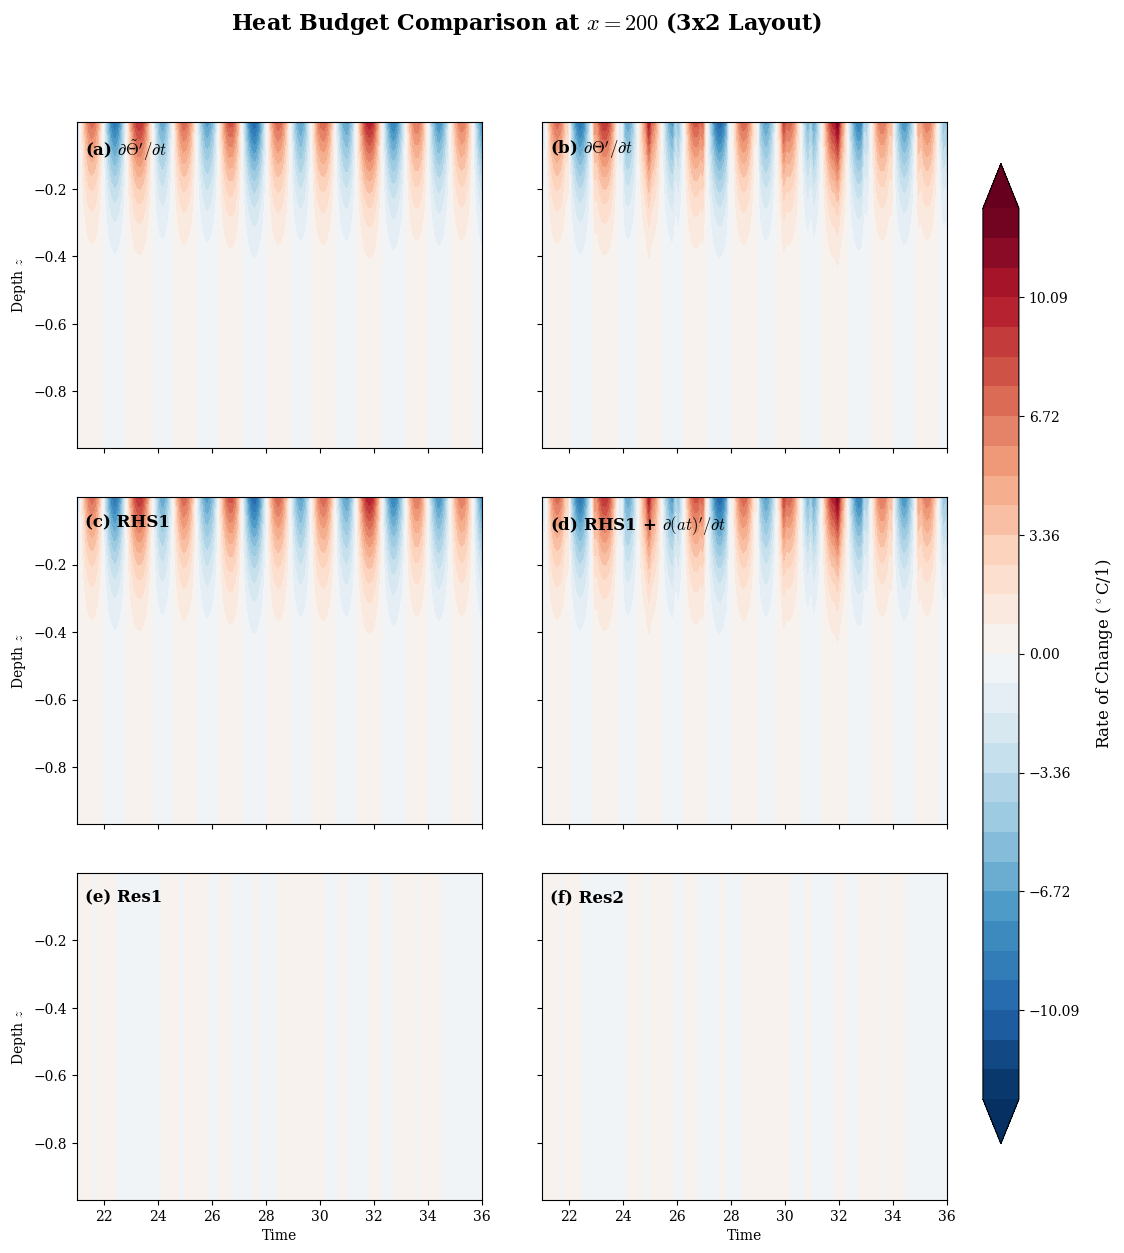

In [128]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. 数据准备 ---
x_idx = 200 

# 第一行：dTwadt vs RHS
# 第二行：dTadt vs RHS2
# 第三行：Res1 vs Res2
# 重新组织为 3行2列
plot_grid = [
    [(dTwadt[x_idx, :, :], r'$\partial{\tilde{\Theta}^{\prime}}/\partial{t}$'), 
     (dTadt[x_idx, :, :], r'$\partial{\Theta^{\prime}}/\partial{t}$')],
    
    [(RHS[x_idx, :, :], r'RHS1'), 
     (RHS2[x_idx, :, :], r'RHS1 + $\partial(at)^{\prime}/\partial t$')],
    
    [(dTwadt[x_idx, :, :] - RHS[x_idx, :, :], 'Res1'), 
     (dTadt[x_idx, :, :] - RHS2[x_idx, :, :], 'Res2')]
]

panel_labels = [['(a)', '(b)'], ['(c)', '(d)'], ['(e)', '(f)']]

# --- 2. 统一颜色刻度 ---
all_data = [dTwadt[x_idx,:,:], RHS[x_idx,:,:], dTadt[x_idx,:,:], RHS2[x_idx,:,:], 
            dTwadt[x_idx,:,:]-RHS[x_idx,:,:], dTadt[x_idx,:,:]-RHS2[x_idx,:,:]]
vmax = np.nanmax(np.abs(all_data))
levels = np.linspace(-vmax, vmax, 31)

# --- 3. 绘图 (3行2列) ---
fig, axes = plt.subplots(3, 2, figsize=(12, 14), sharex=True, sharey=True)

for r in range(3):
    for c in range(2):
        ax = axes[r, c]
        data, title = plot_grid[r][c]
        
        # 绘图 - 使用你代码中的 -z_norm
        im = ax.contourf(t_daily, -z_norm, data, levels=levels, cmap='RdBu_r', extend='both')
        
        # 图内标注 (无背景色)
        full_label = f"{panel_labels[r][c]} {title}"
        ax.text(0.02, 0.95, full_label, transform=ax.transAxes, 
                fontsize=12, fontweight='bold', verticalalignment='top')
        
        ax.set_xlim(21, 36)
        
        # 标签处理
        if r == 2: ax.set_xlabel('Time')
        if c == 0: 
            ax.set_ylabel('Depth $z$')
            # 检查是否需要翻转 (如果是 -z_norm 通常 0 在上方，无需再 invert)
            # ax.invert_yaxis() 

# --- 4. 公用 Colorbar ---
# 针对 3行 调整布局
fig.subplots_adjust(right=0.85, hspace=0.15, wspace=0.15)
cbar_ax = fig.add_axes([0.88, 0.15, 0.03, 0.7]) 
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Rate of Change ($^\circ$C/1)', fontsize=12, labelpad=10)

plt.suptitle(f'Heat Budget Comparison at $x = {x_idx}$ (3x2 Layout)', 
             fontsize=16, fontweight='bold', y=0.96)
plt.show()


# warming rate with x variable

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# =================================================================
# 1. 网格配置 (保持不变)
# =================================================================
dx, x_max = 0.0035, 3.0
x = np.arange(0, x_max + dx, dx)
Nx = len(x)

Nz, z_max, alpha = 50, 4000.0, 3.0
eta = np.linspace(0, 1, Nz)
dz_cumulative = (np.exp(alpha*eta) - 1)/(np.exp(alpha) - 1) * z_max
z_coords = np.zeros(Nz)
z_coords[0] = 0.5 * dz_cumulative[0] + 3.0
for k in range(1, Nz):
    z_coords[k] = (dz_cumulative[k] + dz_cumulative[k-1])/2
z_norm = z_coords / z_max

dt, t_max =  0.01, 41           #0.01, 41
t = np.arange(1, t_max + dt, dt)
Nt = len(t)

x3, z3, t3 = np.meshgrid(x, z_norm, t, indexing='ij')

# =================================================================
# 2. 参数与垂向结构函数
# =================================================================
p = {
    'omega1': 2*np.pi, 'omega2': 2*np.pi/2.7, 'omega3': 2*np.pi/3,
    'a1': 1.0, 'a2': 0.5, 'a3': 2.0, 'a4': 1.0, 'a5': 4.5,
    'c': 15.0, 'cp': 0.1, 'u0': 0.08,
    'b_linear': 0.04,  
    'b_accel': 0.003, 
    # --- 【修改点 1: 新增空间不均匀增暖参数】 ---
    'b_x_amp': 0.04,                   # x方向增暖波动的振幅
    'b_x_k': 2 * np.pi / (x_max / 1.5), # x方向增暖波动的波数 (周期设为 x_max的一半)
    # ----------------------------------------
    'amp_low': 0.4, 
    'omega_low': 2*np.pi/50, 'phase_low': 1.0,
    'dTdx_back': -3.0,
}
p['k1'] = (2 * np.pi) / (x_max / 17.5)
p['k2'] = p['k1'] * 0.25

f_z_3d = 1.0 * (1 - np.tanh((z3 - 100.0/z_max) / (1000.0/z_max))) 
g_z_3d = np.exp(-z3 / (1000.0/z_max))

# =================================================================
# 3. 瞬时场计算 (Snapshots)
# =================================================================
phi_w1 = p['k1'] * (x3 - p['cp'] * t3)
phi_w2 = p['k2'] * (x3 - p['cp'] * t3)
phi_low = p['omega_low'] * t3 + p['phase_low']

# --- 【修改点 2: 更新 T_trend 逻辑，引入 x 依赖】 ---
# 现在的变暖速率是 b_linear + b_x_amp * cos(k*x)
spatial_warming_mod = p['b_x_amp'] * np.cos(p['b_x_k'] * x3)
T_trend = (p['b_linear'] + spatial_warming_mod) * t3 + p['b_accel'] * t3**2 + p['amp_low'] * np.sin(phi_low)
# -----------------------------------------------

T_snap = (p['a1'] * np.cos(p['omega1'] * t3) + p['a2'] * np.cos(p['omega2'] * t3) + 
          p['a3'] * np.sin(phi_w1) + p['a4'] * np.sin(phi_w2) + 
          p['dTdx_back'] * x3 + T_trend + p['c']) * f_z_3d

u_snap = p['u0'] * (1 + p['a5'] * np.sin(p['omega3'] * t3)) * g_z_3d
Tx_snap = (p['a3'] * p['k1'] * np.cos(phi_w1) + p['a4'] * p['k2'] * np.cos(phi_w2) + p['dTdx_back']) * f_z_3d

uTx_snap = u_snap * Tx_snap

# --- 【修改点 3: 更新时间导数，包含空间调制项】 ---
dT_trend_dt = (p['b_linear'] + spatial_warming_mod + 2 * p['b_accel'] * t3 + p['amp_low'] * p['omega_low'] * np.cos(phi_low))
# -----------------------------------------------

Tt_snap = (-p['a1'] * p['omega1'] * np.sin(p['omega1'] * t3) - 
            p['a2'] * p['omega2'] * np.sin(p['omega2'] * t3) - 
            p['a3'] * p['k1'] * p['cp'] * np.cos(phi_w1) - 
            p['a4'] * p['k2'] * p['cp'] * np.cos(phi_w2) + 
            dT_trend_dt) * f_z_3d
Tdot_snap = Tt_snap + uTx_snap

# =================================================================
# 4. 解析积分函数
# =================================================================
def get_integrated_fields_3d(x_m, z_m, t_m, p, f_z, g_z):
    phi_w1 = p['k1'] * (x_m - p['cp'] * t_m)
    phi_w2 = p['k2'] * (x_m - p['cp'] * t_m)
    phi_low = p['omega_low'] * t_m + p['phase_low']
    
    # --- 【修改点 4: 更新原函数 int_T_trend】 ---
    # 对 (b_linear + amp*cos(k*x))*t 关于 t 积分得到 0.5*(...)t^2
    spatial_warming_mod_m = p['b_x_amp'] * np.cos(p['b_x_k'] * x_m)
    int_T_trend = (0.5 * (p['b_linear'] + spatial_warming_mod_m) * t_m**2 + 
                   (1/3.0) * p['b_accel'] * t_m**3 - 
                   (p['amp_low'] / p['omega_low']) * np.cos(phi_low))
    # ------------------------------------------

    int_T_spatial = p['dTdx_back'] * x_m * t_m
    int_T_surf = ( (p['a1']/p['omega1']) * np.sin(p['omega1']*t_m) + 
                   (p['a2']/p['omega2']) * np.sin(p['omega2']*t_m) +
                   (p['a3']/(p['k1']*p['cp'])) * np.cos(phi_w1) + 
                   (p['a4']/(p['k2']*p['cp'])) * np.cos(phi_w2) +
                   int_T_trend + int_T_spatial + p['c']*t_m )
    int_T_3d = int_T_surf * f_z
    
    int_Tx_surf = (-(p['a3'] / p['cp']) * np.sin(phi_w1) - 
                   (p['a4'] / p['cp']) * np.sin(phi_w2) + 
                   p['dTdx_back'] * t_m)
    int_Tx_3d = int_Tx_surf * f_z
    
    int_u_3d = (p['u0'] * t_m - (p['u0'] * p['a5'] / p['omega3']) * np.cos(p['omega3'] * t_m)) * g_z
    
    def calc_wave_adv_integral(k_val, a_val):
        f_plus, f_minus = p['omega3'] - k_val*p['cp'], p['omega3'] + k_val*p['cp']
        p_plus = p['omega3']*t_m + k_val*(x_m - p['cp']*t_m)
        p_minus = p['omega3']*t_m - k_val*(x_m - p['cp']*t_m)
        coeff = (p['u0'] * p['a5'] * a_val * k_val) / 2.0
        u_prime_wave = coeff * (-np.cos(p_plus)/f_plus - np.cos(p_minus)/f_minus)
        u0_wave = -(p['u0'] * a_val / p['cp']) * np.sin(k_val*(x_m - p['cp']*t_m))
        return u_prime_wave + u0_wave

    term_u_back_int = (p['u0'] * t_m - (p['u0'] * p['a5'] / p['omega3']) * np.cos(p['omega3'] * t_m)) * p['dTdx_back']
    int_uTx_3d = (calc_wave_adv_integral(p['k1'], p['a3']) + 
                  calc_wave_adv_integral(p['k2'], p['a4']) + 
                  term_u_back_int) * (f_z * g_z)
    
    # --- 【修改点 5: 更新 int_Tdot 中的瞬时 T_surf】 ---
    # T_surf_instant 必须包含不均匀增暖项
    T_trend_instant = (p['b_linear'] + spatial_warming_mod_m) * t_m + p['b_accel'] * t_m**2 + p['amp_low'] * np.sin(phi_low)
    T_surf_instant = (p['a1'] * np.cos(p['omega1'] * t_m) + p['a2'] * np.cos(p['omega2'] * t_m) + 
                      p['a3'] * np.sin(phi_w1) + p['a4'] * np.sin(phi_w2) + 
                      T_trend_instant + p['dTdx_back'] * x_m + p['c'])
    int_Tdot_3d = T_surf_instant * f_z + int_uTx_3d
    # -----------------------------------------------
    
    return int_T_3d, int_Tx_3d, int_u_3d, int_uTx_3d, int_Tdot_3d

# 执行积分获取原函数
int_T, int_Tx, int_u, int_uTx, int_Tdot = get_integrated_fields_3d(x3, z3, t3, p, f_z_3d, g_z_3d)

# =================================================================
# 5. 时步平均场计算 (保持不变)
# =================================================================
T_avg = (int_T[:,:,1:] - int_T[:,:,0:-1]) / dt
Tx_avg = (int_Tx[:,:,1:] - int_Tx[:,:,0:-1]) / dt
u_avg = (int_u[:,:,1:] - int_u[:,:,0:-1]) / dt
uTx_avg = (int_uTx[:,:,1:] - int_uTx[:,:,0:-1]) / dt
Tdot_avg = (int_Tdot[:,:,1:] - int_Tdot[:,:,0:-1]) / dt

t_daily = (t[1:] + t[:-1]) / 2

# =================================================================
# 6. 验证
# =================================================================
print(f"数据准备完成。增暖速率已在 x 方向以周期为 {x_max/1.5:.2f} 进行正余弦调制。")



数据准备完成。增暖速率已在 x 方向以周期为 2.00 进行正余弦调制。


In [3]:
1/0.0055

181.81818181818184

In [4]:
x_mid = (x[0:-1] + x[1:])/2
x_1 = np.concatenate( ([x[0] - dx/2], x_mid, [x[-1] + dx/2] ) )
x13, z13, t13 = np.meshgrid(x_1, z_norm, t, indexing='ij')
f_z1_3d = 1.0 * (1 - np.tanh((z13 - 100.0/z_max) / (1000.0/z_max))) 
phi_w11 = p['k1'] * (x13 - p['cp'] * t13)
phi_w21 = p['k2'] * (x13 - p['cp'] * t13)
phi_low1 = p['omega_low'] * t13 + p['phase_low']
spatial_warming_mod1 = p['b_x_amp'] * np.cos(p['b_x_k'] * x13)
T_trend1 = (p['b_linear'] + spatial_warming_mod1) * t13 + p['b_accel'] * t13**2 + p['amp_low'] * np.sin(phi_low1)
T1_snap = (p['a1'] * np.cos(p['omega1'] * t13) + p['a2'] * np.cos(p['omega2'] * t13) + 
          p['a3'] * np.sin(phi_w11) + p['a4'] * np.sin(phi_w21) + 
          p['dTdx_back'] * x13 + T_trend1 + p['c']) * f_z1_3d

slope1 = (T1_snap[..., -1] - T1_snap[..., 0]) / (t[-1] - t[0])
# 2). 将斜率在第3维增加一个轴，形状变为 (Nx, Nz, 1), 再与 t (Nt,) 进行广播相乘，结果自动变为 (Nx, Nz, Nt)
x23, z23, t23 = np.meshgrid(x_1, z_norm, t_daily, indexing='ij')
int_Tanb1 = slope1[..., np.newaxis] * t13 **2 /2.
Tanb1_avg = (int_Tanb1[:,:,1:] - int_Tanb1[:,:,0:-1])/dt

yearlyNt = int(np.round(2 * np.pi / p['omega1'] / dt)) # 每年格点数
nyear = int(len(t_daily)/yearlyNt)         # 总年数

Tanb1_bar_pure = cal_cyclic_mean_pure(Tanb1_avg.transpose(2,0,1), nyear, yearlyNt, T1_snap.shape[0:2], smooth=0).transpose(1,2,0)
Tanb1_anom = Tanb1_avg - Tanb1_bar_pure
Tanb1_anom_x = (Tanb1_anom[1:,...] - Tanb1_anom[0:-1,...] )/dx



In [ ]:
import matplotlib.pyplot as plt

# 调整画布大小，确保信息清晰
plt.figure(figsize=(10, 6))

# 定义索引范围和空间位置
# 为了展示波动的相位差，建议稍微扩大 idx 范围
idx_t = slice(1, 30)         # 瞬时场索引
idx_d = slice(1, 29)         # 平均场索引（比瞬时场少一个点）
x_pos = 100                  # 空间位置索引
z_pos = 5                    # 浅层索引，波动较明显

# 基准值
T_mean = 15.0

# 1. 温度 T (蓝色)
plt.plot(t[idx_t], T_snap[x_pos, z_pos, idx_t] - T_mean, 
         color='blue', linestyle='-', label='T Snapshot (Anomaly)', alpha=0.8)
plt.plot(t_daily[idx_d], T_avg[x_pos, z_pos, idx_d] - T_mean, 
         color='deepskyblue', linestyle='None', marker='*', markersize=4, label='T Daily Avg', alpha=0.6)

# 2. 平流项 uTx (红色)
plt.plot(t[idx_t], uTx_snap[x_pos, z_pos, idx_t], 
         color='red', linestyle='-', label='uTx Snapshot', alpha=0.8)
plt.plot(t_daily[idx_d], uTx_avg[x_pos, z_pos, idx_d], 
         color='salmon', marker='*', linewidth=1.5, label='uTx Daily Avg', alpha=0.7)

# 3. 全导数 Tdot (绿色)
plt.plot(t[idx_t], Tdot_snap[x_pos, z_pos, idx_t], 
         color='green', linestyle='-', label='Tdot Snapshot', alpha=0.8)
plt.plot(t_daily[idx_d], Tdot_avg[x_pos, z_pos, idx_d], 
         color='lime', marker='*', linewidth=1.5, label='Tdot Daily Avg', alpha=0.7)

# 4. 流速 u (黑色/灰色) - 放大 5 倍以适应量级
plt.plot(t[idx_t], u_snap[x_pos, z_pos, idx_t] * 5, 
         color='black', marker='*', label='u Snapshot (x5)', alpha=0.7)

# 图形修饰
plt.axhline(0, color='black', linewidth=1, linestyle=':')
plt.title(f'3D Physics Comparison: Snapshots vs Daily Averages\n(at x={x[x_pos]:.3f}, Depth z={z_norm[z_pos]:.1f})')
plt.xlabel('Time (years)')
plt.ylabel('Value (T-15 / Velocity / Rates)')
plt.legend(loc='upper right', fontsize='x-small', ncol=2, frameon=True)
plt.grid(True, which='both', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
plt.contourf( t_daily, x, T_avg[:,0] )
plt.colorbar()

In [5]:
# =================================================================
# 3D Budget Analysis 
# =================================================================

# 1. 基本参数
yearlyNt = int(np.round(2 * np.pi / p['omega1'] / dt)) # 每年格点数
nyear = int(len(t_daily)/yearlyNt)         # 总年数
shape_rest = T_snap.shape[0:2]             # 空间维度为 (Nx, Nz)

#a.  detrend
# 1). 计算每个格点的斜率，形状为 (Nx, Nz)
slope = (T_snap[..., -1] - T_snap[..., 0]) / (t[-1] - t[0])
# 2). 将斜率在第3维增加一个轴，形状变为 (Nx, Nz, 1), 再与 t (Nt,) 进行广播相乘，结果自动变为 (Nx, Nz, Nt)
Tanb = slope[..., np.newaxis] * t3
int_Tanb = slope[..., np.newaxis] * t3 **2 /2.
Tanb_avg = (int_Tanb[:,:,1:] - int_Tanb[:,:,0:-1])/dt


Tdotanb = np.mean(Tdot_avg - uTx_avg, axis=-1)[..., np.newaxis] * t_daily
Twave = T_snap - Tanb   # detrend
Twave_avg = T_avg - Tanb_avg   # detrend

## T anom 
Twave_bar = calc_cyclic_mean(Twave.transpose(2,0,1), nyear,yearlyNt, shape_rest, smooth=0, smooth_window=1).transpose(1,2,0)
Twave_bar_pure = cal_cyclic_mean_pure(Twave.transpose(2,0,1), nyear, yearlyNt, shape_rest, smooth=0).transpose(1,2,0)
Twave_anom = Twave - Twave_bar_pure

Twave_avg_bar_pure = cal_cyclic_mean_pure(Twave_avg.transpose(2,0,1), nyear, yearlyNt, shape_rest, smooth=0).transpose(1,2,0)
Twave_avg_anom = Twave_avg - Twave_avg_bar_pure


T_bar_pure = cal_cyclic_mean_pure(T_snap.transpose(2,0,1), nyear, yearlyNt, shape_rest, smooth=0).transpose(1,2,0)
T_anom = T_snap - T_bar_pure

T_avg_bar_pure = cal_cyclic_mean_pure(T_avg.transpose(2,0,1), nyear, yearlyNt, shape_rest, smooth=0).transpose(1,2,0)
T_avg_anom = T_avg - T_avg_bar_pure


## dTdt
dTadt  =  (T_anom[...,1:] - T_anom[...,0:-1])/dt
dTwadt =  (Twave_anom[...,1:] - Twave_anom[...,0:-1])/dt

## 
Tanb_bar_pure = cal_cyclic_mean_pure(Tanb.transpose(2,0,1), nyear, yearlyNt, shape_rest, smooth=0).transpose(1,2,0)
Tanb_anom = Tanb - Tanb_bar_pure

dTabadt = (Tanb_anom[...,1:] - Tanb_anom[...,0:-1])/dt

#Tanb_daily_bar_pure = cal_cyclic_mean_pure(Tanb_daily.T, nyear, yearlyNt, shape_rest, smooth=0).T
#Tanb_daily_anom = Tanb_daily - Tanb_daily_bar_pure

## u_bar Tx_bar uTx_bar
udaily_bar_pure   = cal_cyclic_mean_pure(u_avg.transpose(2,0,1), nyear, yearlyNt, shape_rest, smooth=0).transpose(1,2,0)
uTxdaily_bar_pure = cal_cyclic_mean_pure(uTx_avg.transpose(2,0,1), nyear, yearlyNt, shape_rest, smooth=0).transpose(1,2,0)
Txdaily_bar_pure  = cal_cyclic_mean_pure(Tx_avg.transpose(2,0,1), nyear, yearlyNt, shape_rest, smooth=0).transpose(1,2,0)

udaily_anom = u_avg - udaily_bar_pure
Txdaily_anom = Tx_avg - Txdaily_bar_pure
Txwave_anom = Txdaily_anom - Tanb1_anom_x

upTxp_bar = uTxdaily_bar_pure - udaily_bar_pure*Txdaily_bar_pure
upTxbar = -(udaily_anom * Txdaily_bar_pure)

uTxanom       = -(u_avg * Txdaily_anom )
uTxwave_anom  = -(u_avg * Txwave_anom  )
uTanb1_anom_x = -(u_avg * Tanb1_anom_x )

## Tdot
Tdotdaily_bar_pure  = cal_cyclic_mean_pure(Tdot_avg.transpose(2,0,1), nyear, yearlyNt, shape_rest, smooth=0).transpose(1,2,0)
Tdotdaily_anom = Tdot_avg - Tdotdaily_bar_pure

## RHS
RHS  = uTxanom + upTxbar + upTxp_bar + Tdotdaily_anom 
RHS2 = uTxanom + upTxbar + upTxp_bar + Tdotdaily_anom + dTabadt
RHS3 = uTxwave_anom + uTanb1_anom_x + upTxbar + upTxp_bar + Tdotdaily_anom

In [6]:
import xarray as xr

# Create a dictionary of your data variables
# Note: Ensure time dimensions match (some of your dT/dt terms might be Nt-1)
data_vars = {
    "T_snap_anom":   (["x", "z", "time_snap"], T_anom),
    "T_avg_anom":    (["x", "z", "time"], T_avg_anom),
    "Twave_anom" :    (["x", "z", "time_snap"], Twave_anom),
    "Twave_avg_anom" :    (["x", "z", "time"], Twave_avg_anom),    
    "u_avg":         (["x", "z", "time"], u_avg),
    "dTabadt":       (["x", "z", "time"], dTabadt),
    "uTxanom":       (["x", "z", "time"], uTxanom),
    "uTxwave_anom":  (["x", "z", "time"], uTxwave_anom),
    "uTanb1_anom_x": (["x", "z", "time"], uTanb1_anom_x),
    "upTxbar":       (["x", "z", "time"], upTxbar),
    "upTxp_bar":     (["x", "z", "time"], upTxp_bar),
    "Tdot_anom":     (["x", "z", "time"], Tdotdaily_anom),
   
}

# Define coordinates
coords = {
    "x": x,
    "z": z_norm,
    "time": t_daily, 
    "time_snap": t  # For the forward-difference derivatives
}

# Create Dataset
ds = xr.Dataset(data_vars, coords=coords)

# Add metadata for clarity
ds.T_snap_anom.attrs = {"units": "K", "long_name": "Temperature Anomaly"}
#ds.RHS.attrs = {"units": "K/s", "long_name": "Right Hand Side Budget"}

# Save to NetCDF
#ds.to_netcdf("/pub/ranl24/2d_analytical_budgets_dx0035dt05.nc")
#ds.to_netcdf("/pub/ranl24/2d_analytical_budgets_dx0035dt01.nc")
#ds.to_netcdf("/pub/ranl24/2d_analytical_budgets_dx0025dt025_notrend.nc")
#ds.to_netcdf("/pub/ranl24/2d_analytical_budgets_dx0025dt01_notrend.nc")
#ds.to_netcdf("/pub/ranl24/2d_analytical_budgets_dx0035dt01_utx.nc")
#ds.to_netcdf("/pub/ranl24/2d_analytical_budgets_dx0055dt0055_utx.nc")

print("Dataset saved successfully.")

Dataset saved successfully.


In [ ]:
#### figure B1 for JPO

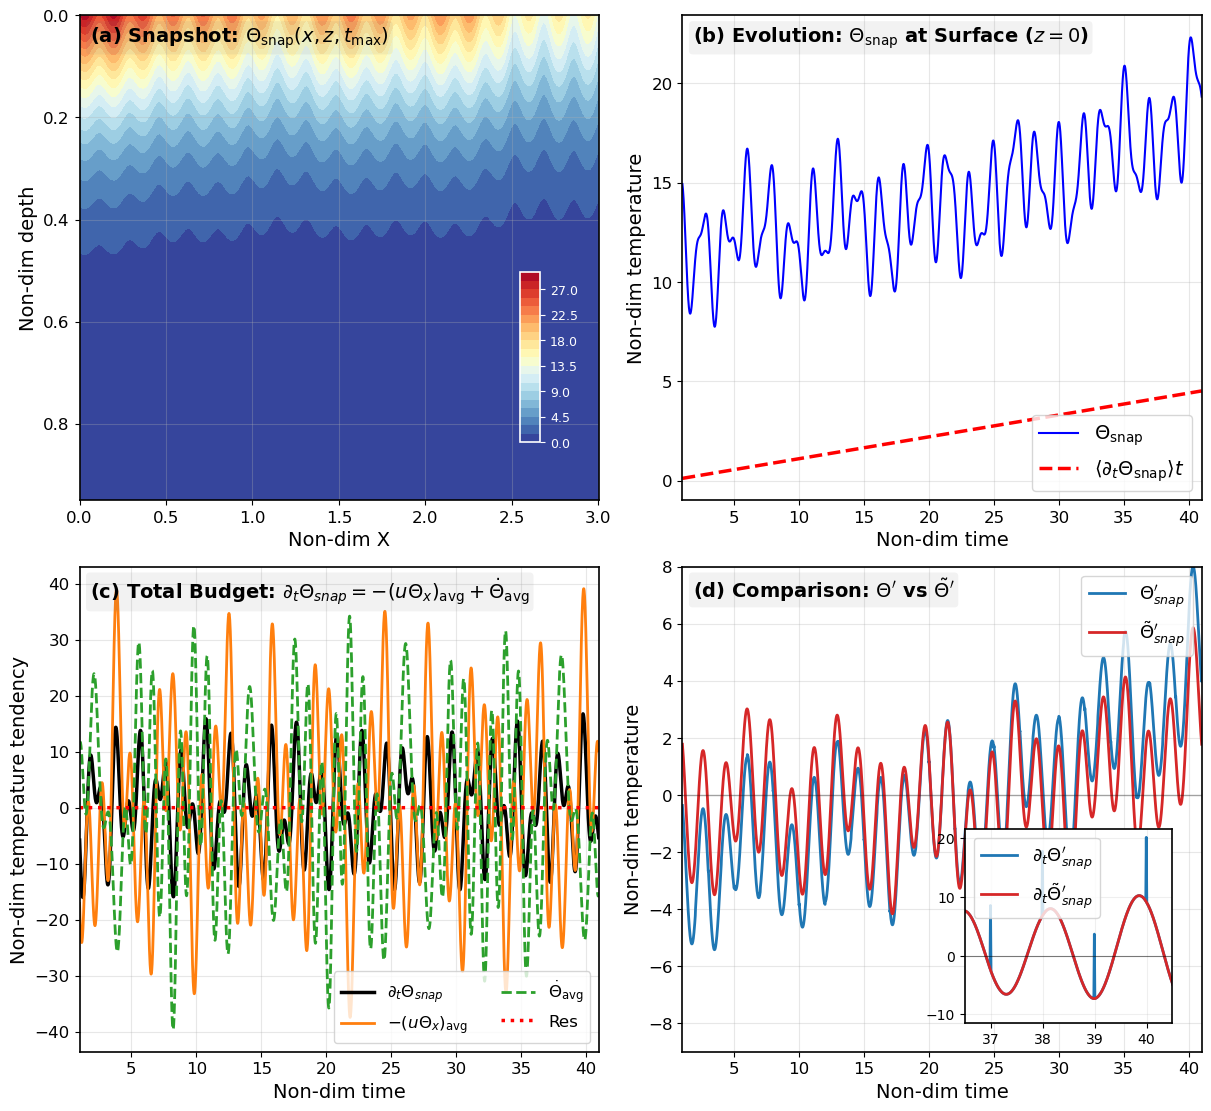

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl

# --- 风格设置 ---
#plt.rcParams.update({
#    "mathtext.fontset": "cm", 
#    "font.family": "serif",
#    "axes.unicode_minus": False,
#    "font.size": 14
#})

# ---- JPO 风格 ----
mpl.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.2,
})
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42



fig, axs = plt.subplots(2, 2, figsize=(12, 11), constrained_layout=True)

# 选取展示的位置 (表面中心)
ix, iz = Nx // 2, 0                            

# --- 内部标题内容 ---
titles = [
    r"Snapshot: $\Theta_{\mathrm{snap}}(x, z, t_{\mathrm{max}})$",
    r"Evolution: $\Theta_{\mathrm{snap}}$ at Surface ($z=0$)",
    r"Total Budget: $\partial_t \Theta_{snap} = -(u \Theta_x)_{\mathrm{avg}} + \dot{\Theta}_{\mathrm{avg}}$",
    r"Comparison: $\Theta^{\prime}$ vs $\tilde{\Theta}^{\prime}$"
]

# --- (a) Snapshot ---
im1 = axs[0, 0].contourf(x, z_norm, T_snap[:, :, -1].T, cmap='RdYlBu_r', levels=20)
axs[0, 0].set_ylabel("Non-dim depth")
axs[0, 0].set_xlabel("Non-dim X")
#plt.colorbar(im1, ax=axs[0, 0])
# 把 colorbar 放进右下角
cax1 = inset_axes(axs[0, 0],
                  width="4%",    # 宽度为父 axes 的 4%
                  height="35%",  # 高度为父 axes 的 35%
                  loc="lower right",
                  borderpad=3) # 离边框的距离
cb1 = plt.colorbar(im1, cax=cax1)
cb1.ax.tick_params(labelsize=9, colors="white")   # 字小一点，白色避免和图重叠
cb1.outline.set_edgecolor("white")                # 边框也用白色

# --- (b) Time Series ---
axs[0, 1].plot(t, T_snap[ix, iz, :], color='b', lw=1.5, label=r'$\Theta_{\mathrm{snap}}$')
axs[0, 1].plot(t, Tanb[ix, iz, :], 'r--', lw=2.5, label=r'$\langle \partial_t \Theta_{\mathrm{snap}} \rangle t$')
axs[0, 1].set_ylabel("Non-dim temperature")
axs[0, 1].legend(loc='lower right', frameon=True)
axs[0, 1].set_xlim(1, 41)
axs[0, 1].set_ylim(0, 22)
axs[0, 1].set_xlabel("Non-dim time")

# --- (c) Total Budget Closure ---
dThetadt_snap = (T_snap[:, :, 1:] - T_snap[:, :, :-1]) / dt
axs[1, 0].plot(t_daily, dThetadt_snap[ix, iz, :], 'k', lw=2.5, label=r'$\partial_t \Theta_{snap}$')
axs[1, 0].plot(t_daily, -uTx_avg[ix, iz, :], color='#ff7f0e', lw=2, label=r'$-(u\Theta_x)_{\mathrm{avg}}$')
axs[1, 0].plot(t_daily, Tdot_avg[ix, iz, :], color='#2ca02c', ls='--', lw=2, label=r'$\dot{\Theta}_{\mathrm{avg}}$')
axs[1, 0].plot(t_daily, (dThetadt_snap - (-uTx_avg + Tdot_avg))[ix, iz, :], ':', color='red', lw=2.5, label=r'Res')
axs[1, 0].set_ylabel("Non-dim temperature tendency")
axs[1, 0].legend(loc='lower right', ncol=2, fontsize=12, frameon=True)
axs[1, 0].set_xlim(1, 41)
axs[1, 0].set_xlabel("Non-dim time")

# --- (d) Comparison with Tendency Inset in Lower Right ---
ax_d = axs[1, 1]
# 主图画异常场
ax_d.plot(t, T_anom[ix, iz, :], color='#1f77b4', lw=2, label=r"$\Theta_{snap}^{\prime}$")
ax_d.plot(t, Twave_anom[ix, iz, :], color='#d62728', lw=2, label=r"$\tilde{\Theta}_{snap}^{\prime}$")
ax_d.axhline(0, color='k', lw=1, alpha=0.3)
ax_d.set_ylabel("Non-dim temperature")
ax_d.set_xlabel("Non-dim time")
ax_d.legend(loc='upper right', fontsize=13)
ax_d.set_xlim(1, 41)
ax_d.set_ylim(-9, 8)

# 在右下角创建 Inset 子图，专门画趋势项 (Tendency)
# loc=4 对应 lower right
ax_ins = inset_axes(ax_d, width="40%", height="40%", loc=4, borderpad=1.5)

# 子图画趋势项对比
ax_ins.plot(t_daily, dTadt[ix, iz, :], color='#1f77b4', ls='-', lw=2, label=r'$\partial_t \Theta_{snap}^{\prime}$')
ax_ins.plot(t_daily, dTwadt[ix, iz, :], color='#d62728', ls='-', lw=2, label=r'$\partial_t \tilde{\Theta}_{snap}^{\prime}$')
ax_ins.axhline(0, color='k', lw=0.8, alpha=0.5)
ax_ins.legend(loc='upper left', fontsize=13)

# 设置子图 Zoom-in 范围 (t from 36 to 41)
ax_ins.set_xlim(36.5, 40.5)
# 自动调整 y 轴以突出显示两条线的间距
#ax_ins.set_title(r'Tendency Zoom-in', fontsize=12, fontweight='bold')
ax_ins.tick_params(labelsize=10)
ax_ins.grid(True, alpha=0.2)

# --- 统一格式调整 ---
letters = ["a", "b", "c", "d"]
for i, ax in enumerate(axs.flat):
    full_label = f'({letters[i]}) {titles[i]}'
    ax.text(0.02, 0.98, full_label, transform=ax.transAxes, 
            fontsize=14, fontweight='bold', va='top', ha='left', 
            bbox=dict(boxstyle="round,pad=0.2", facecolor="grey", edgecolor="none", alpha=0.1))
    
    ax.grid(True, alpha=0.3)
    
    if i == 0:
        ax.set_ylim(0, 0.95); ax.invert_yaxis()
    elif i != 3: 
        ax.autoscale(enable=True, axis='y')

#plt.savefig('fig_theta_configuration.png', dpi=1000, bbox_inches="tight")
#plt.savefig('fig_theta_configuration.pdf', dpi=1000 )

plt.show()


max |Θ - Θ̄ - Θ′| = 0.0


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


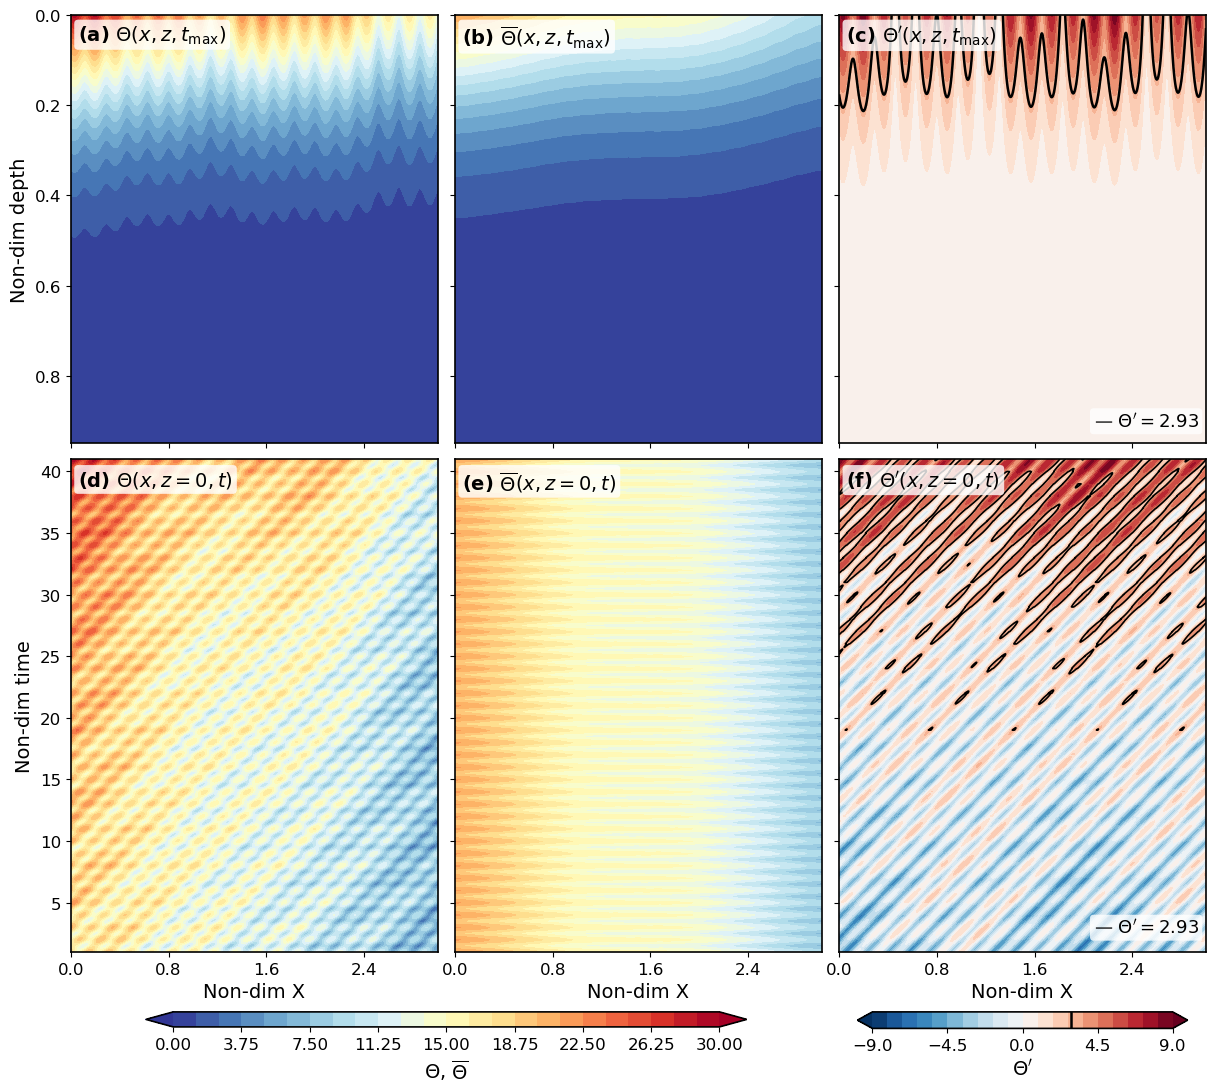

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
# ---------------- 收紧水平间距 ----------------
from matplotlib.ticker import MaxNLocator


# ---- JPO 风格 ----
mpl.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.2,
})
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

# =================================================================
# Main-text figure: Θ = Θ̄ + Θ′  (2×3)
#   top row   : (x, z) at t_max         (a) Θ   (b) Θ̄ (same phase of year)   (c) Θ′
#   bottom row: Hovmöller (x, t) at z=0  (d) Θ   (e) Θ̄                        (f) Θ′
# T_bar_pure 由 cal_cyclic_mean_pure 得到；t_max=41 与 t=1 同相位，
# handle_remainder 取相位 0，所以 T_bar_pure[..., -1] 就是 t_max 同一时刻的气候态
# 注：B1b 是 Θ′ 在 x = x[Nx//2] 的 (z, t) 剖面；本图 (c) 是 t = t_max 的 (x, z) 剖面，
#     两者在 (x = x[Nx//2], t = t_max) 这一列完全相同
# =================================================================
it, iz = -1, 0
THETA_C = 2.93     # 与 B1b 相同的水团界定等值线 Θ′ = 2.93

full_snap = T_snap[:, :, it]          # (x, z)
clim_snap = T_bar_pure[:, :, it]
anom_snap = T_anom[:, :, it]

full_hov = T_snap[:, iz, :]           # (x, t)
clim_hov = T_bar_pure[:, iz, :]
anom_hov = T_anom[:, iz, :]

# 一致性检查：Θ − Θ̄ = Θ′
print("max |Θ - Θ̄ - Θ′| =", np.abs(T_snap - T_bar_pure - T_anom).max())

# ---- 色标：Θ 与 Θ̄ 共用一套 levels，便于直接对比；Θ′ 单独对称 ----
vmin_f = min(full_snap.min(), clim_snap.min(), full_hov.min(), clim_hov.min())
vmax_f = max(full_snap.max(), clim_snap.max(), full_hov.max(), clim_hov.max())
lev_full = np.linspace(np.floor(vmin_f), np.ceil(vmax_f), 25)

amax = np.ceil(max(np.abs(anom_snap).max(), np.abs(anom_hov).max()))
lev_anom = np.linspace(-amax, amax, 21)

cmap_full, cmap_anom = 'RdYlBu_r', 'RdBu_r'

fig, axs = plt.subplots(2, 3, figsize=(12, 10.8), constrained_layout=True, sharex=True,
                        gridspec_kw={'height_ratios': [1, 1.15]})

# 栅格化：ContourSet 不支持 set_rasterized（会报 "will be ignored"），
# 改用 rasterization_zorder —— zorder < 0 的元素在 PDF 中栅格化，文字/坐标轴/等值线仍为矢量
RZ = -1
for ax in axs.flat:
    ax.set_rasterization_zorder(0)

# ---------------- top row: (x, z) at t_max ----------------
top = [(full_snap, lev_full, cmap_full),
       (clim_snap, lev_full, cmap_full),
       (anom_snap, lev_anom, cmap_anom)]
for j, (fld, lev, cm) in enumerate(top):
    ax = axs[0, j]
    im = ax.contourf(x, z_norm, fld.T, levels=lev, cmap=cm, extend='both', zorder=RZ)
    ax.set_ylim(0, 0.95); ax.invert_yaxis()
    if j == 0:
        ax.set_ylabel("Non-dim depth")
    else:
        ax.tick_params(labelleft=False)
    if j == 1: im_full_top = im
    if j == 2: im_anom_top = im

# ---------------- bottom row: Hovmöller (x, t) at z=0 ----------------
bot = [(full_hov, lev_full, cmap_full),
       (clim_hov, lev_full, cmap_full),
       (anom_hov, lev_anom, cmap_anom)]
for j, (fld, lev, cm) in enumerate(bot):
    ax = axs[1, j]
    ax.contourf(x, t, fld.T, levels=lev, cmap=cm, extend='both', zorder=RZ)
    ax.set_ylim(t[0], t[-1])
    ax.set_xlabel("Non-dim X")
    if j == 0:
        ax.set_ylabel("Non-dim time")
    else:
        ax.tick_params(labelleft=False)

# ---------------- 水团等值线 Θ′ = THETA_C（同 B1b）----------------
axs[0, 2].contour(x, z_norm, anom_snap.T, levels=[THETA_C], colors='k', linewidths=1.8)
axs[1, 2].contour(x, t, anom_hov.T, levels=[THETA_C], colors='k', linewidths=1.2)
for ax in (axs[0, 2], axs[1, 2]):
    ax.text(0.98, 0.03, r"— $\Theta^{\prime}=%.2f$" % THETA_C, transform=ax.transAxes,
            fontsize=13, ha='right', va='bottom',
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.8))

# ---------------- colorbars（横排，放在最下面）----------------
# ax= 传入整列 axes，constrained_layout 会把色标放在该列组的下方并与之等宽对齐
cb1 = fig.colorbar(im_full_top, ax=axs[:, 0:2], location='bottom',
                   shrink=0.8, pad=0.01, aspect=40)
cb1.set_label(r"$\Theta$, $\overline{\Theta}$")
cb2 = fig.colorbar(im_anom_top, ax=axs[:, 2], location='bottom',
                   shrink=0.9, pad=0.01, aspect=20)
cb2.set_label(r"$\Theta^{\prime}$")
cb2.ax.axvline(THETA_C, color='k', lw=1.8)     # 横向色标：axhline → axvline
cb2.set_ticks(np.linspace(-amax, amax, 5))      # 横排空间窄，减少刻度避免重叠

# ---------------- labels ----------------
titles = [
    r"$\Theta(x, z, t_{\mathrm{max}})$",
    r"$\overline{\Theta}(x, z, t_{\mathrm{max}})$",
    r"$\Theta^{\prime}(x, z, t_{\mathrm{max}})$",
    r"$\Theta(x, z=0, t)$",
    r"$\overline{\Theta}(x, z=0, t)$",
    r"$\Theta^{\prime}(x, z=0, t)$",
]
letters = "abcdef"
for i, ax in enumerate(axs.flat):
    ax.text(0.02, 0.98, f'({letters[i]}) {titles[i]}', transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top', ha='left', zorder=10,
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.8))

# 1) 去掉 x 轴最右端的刻度标签，避免和右侧子图最左端的标签打架
for ax in axs[1, :]:
    ax.xaxis.set_major_locator(MaxNLocator(nbins=4, prune='upper'))

# 2) 缩小 constrained_layout 的列间留白（默认 w_pad≈0.04 inch，wspace=0.02）
fig.get_layout_engine().set(w_pad=0.02, wspace=0.0)

plt.savefig('fig_theta_clim_anom.png', dpi=1000, bbox_inches="tight")
plt.savefig('fig_theta_clim_anom.pdf', dpi=1000, bbox_inches="tight")
plt.show()

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


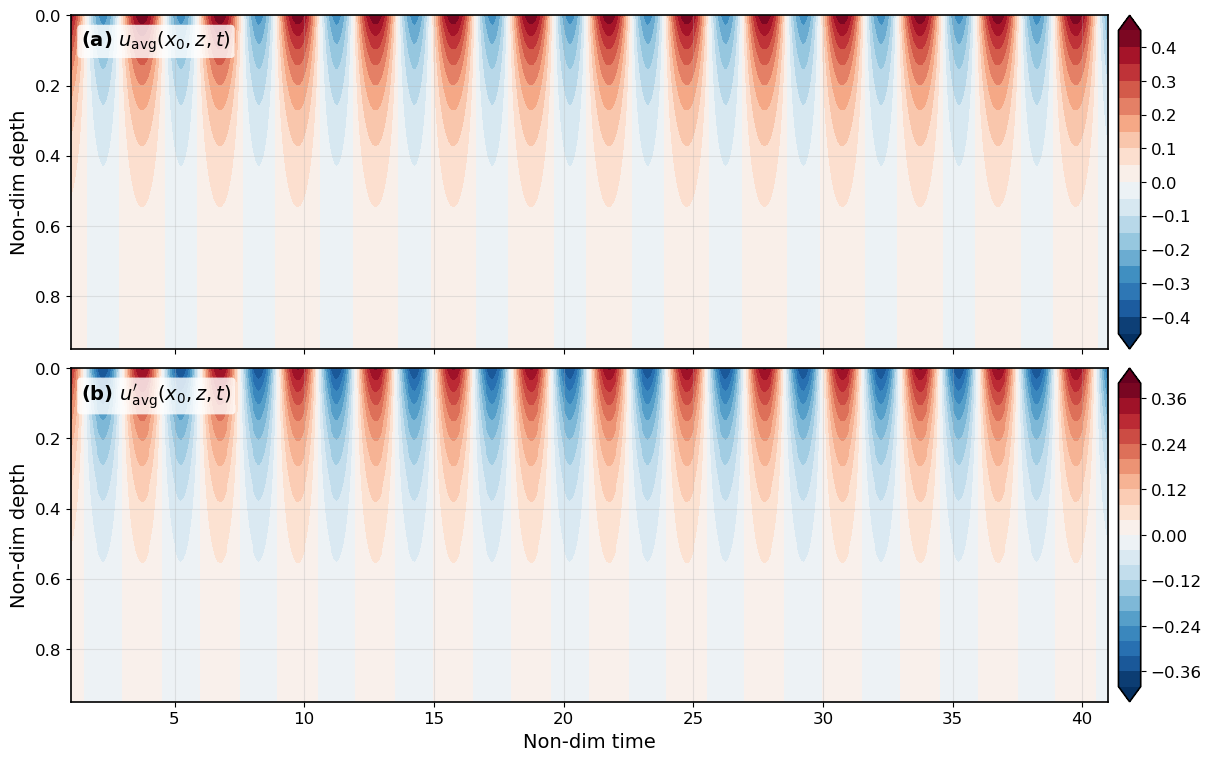

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
from matplotlib.ticker import MaxNLocator

# ---- JPO 风格 ----
mpl.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.2,
})
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

# =================================================================
# Fig. B1（拆分后）：2×1，x = x[Nx//2] 处的 (z, t) 剖面
#   (a) u_avg(z, t)      ← 原 B1c
#   (b) u′_avg(z, t)     ← 原 B1d
# 原 B1a、B1b 的温度信息已由正文图 (a)–(f) 覆盖
# =================================================================
ix = Nx // 2

# u_avg 的 anomaly：与 T_anom 用同一个 cal_cyclic_mean_pure
u_np       = ds.u_avg.values                                     # (x, z, time)
u_bar_pure = cal_cyclic_mean_pure(u_np.transpose(2, 0, 1),
                                  nyear, yearlyNt, shape_rest,
                                  smooth=0).transpose(1, 2, 0)
u_anom     = u_np - u_bar_pure


def sym_levels(arr, n=20):
    """异常场的对称 levels，端点取"整"值"""
    vmax = np.nanmax(np.abs(arr))
    return MaxNLocator(nbins=n, symmetric=True).tick_values(-vmax, vmax)


u_zt  = ds.u_avg.isel(x=ix).values            # (z, time)
ua_zt = u_anom[ix]                            # (z, time)

fig, axs = plt.subplots(2, 1, figsize=(12, 7.5), sharex=True, sharey=True,
                        constrained_layout=True)

RZ = -1                                       # contourf 栅格化
for ax in axs:
    ax.set_rasterization_zorder(0)

# --- (a) u_avg(z, t) ---
im1 = axs[0].contourf(ds.time.values, z_norm, u_zt, cmap='RdBu_r',
                      levels=sym_levels(u_zt), extend='both', zorder=RZ)
fig.colorbar(im1, ax=axs[0], pad=0.01, aspect=15)

# --- (b) u′_avg(z, t) ---
im2 = axs[1].contourf(ds.time.values, z_norm, ua_zt, cmap='RdBu_r',
                      levels=sym_levels(ua_zt), extend='both', zorder=RZ)
fig.colorbar(im2, ax=axs[1], pad=0.01, aspect=15)

# --- 统一格式 ---
titles = [
    r"$u_{\mathrm{avg}}(x_0, z, t)$",
    r"$u^{\prime}_{\mathrm{avg}}(x_0, z, t)$",
]
for i, ax in enumerate(axs):
    ax.text(0.01, 0.96, f'({"ab"[i]}) {titles[i]}', transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top', ha='left', zorder=10,
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.8))
    ax.set_ylabel("Non-dim depth")
    ax.grid(True, alpha=0.3)

axs[0].set_ylim(0.95, 0)          # sharey：只设一次，(大, 小) 让深度向下
axs[-1].set_xlabel("Non-dim time")
axs[-1].set_xlim(1, 41)

plt.savefig('fig_u.png', dpi=1000, bbox_inches="tight")
plt.savefig('fig_u.pdf', dpi=1000, bbox_inches="tight")
plt.show()


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


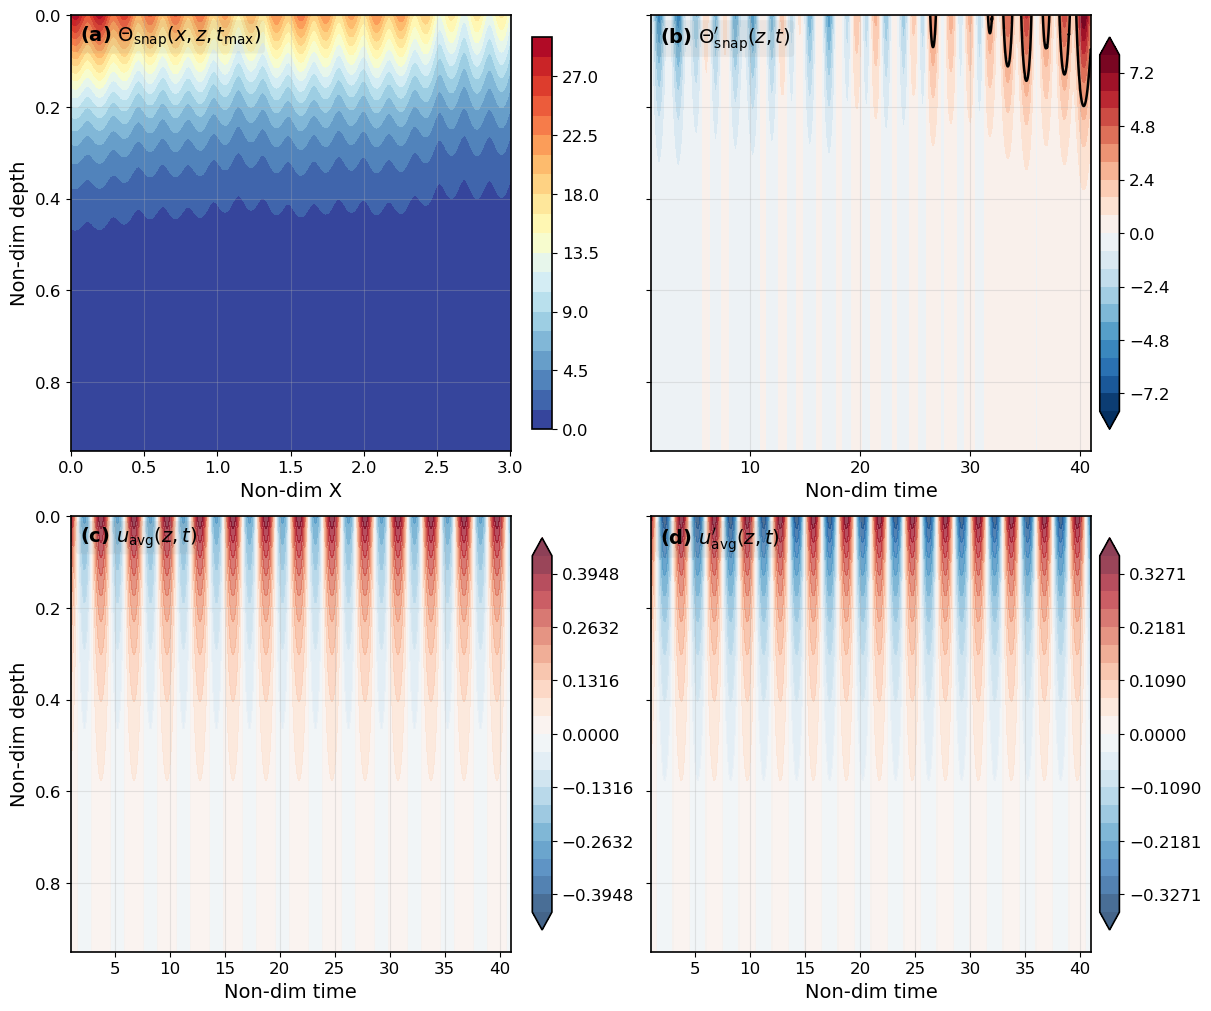

In [25]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl

# ---- JPO 风格 ----
mpl.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.2,
})
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

# =================================================================
# 第一张：场的 2×2（纵轴统一是 depth，四个面板共享 y 轴）
#   (a) Θ_snap 快照 (x, z)      (b) Θ′_snap 的 (z, t) + Θ′ = 2.93 等值线
#   (c) u_avg 的 (z, t)         (d) u′_avg 的 (z, t)
# =================================================================

# u_avg 沿 x 没有变化，(b)(c)(d) 取同一个 x 剖面
ix, iz = Nx // 2, 0

THETA_C = 2.93     # (b) 上叠加的等值线

# -----------------------------------------------------------------
# u_avg 的 anomaly：用和 T_snap_anom 完全相同的做法
#   T_bar_pure = cal_cyclic_mean_pure(...)  →  T_anom = T_snap - T_bar_pure
# （cell 里其实已有 udaily_anom，这里显式重算一遍，保证这个 cell 自洽）
# -----------------------------------------------------------------
u_np       = ds.u_avg.values                                     # (x, z, time)
u_bar_pure = cal_cyclic_mean_pure(u_np.transpose(2, 0, 1),
                                  nyear, yearlyNt, shape_rest,
                                  smooth=0).transpose(1, 2, 0)
u_anom     = u_np - u_bar_pure                                   # (x, z, time)


def sym_levels(arr, n=21):
    """给异常场做对称的 levels"""
    vmax = np.nanmax(np.abs(arr))
    return np.linspace(-vmax, vmax, n)


fig, axs = plt.subplots(2, 2, figsize=(12, 10), sharey=True, constrained_layout=True)

titles = [
    r"$\Theta_{\mathrm{snap}}(x, z, t_{\mathrm{max}})$",
    r"$\Theta^{\prime}_{\mathrm{snap}}(z, t)$",
    r"$u_{\mathrm{avg}}(z, t)$",
    r"$u^{\prime}_{\mathrm{avg}}(z, t)$",
]

# --- (a) Θ_snap 快照 (x, z) ---
im1 = axs[0, 0].contourf(x, z_norm, T_snap[:, :, -1].T, cmap='RdYlBu_r', levels=20)
axs[0, 0].set_xlabel("Non-dim X")
fig.colorbar(im1, ax=axs[0, 0], shrink=0.9, pad=0.02)

# --- (b) Θ′_snap 的 (z, t)，叠加 Θ′ = 2.93 等值线 ---
Ta_zt = ds.T_snap_anom.isel(x=ix).values                     # (z, time_snap)
im2 = axs[0, 1].contourf(ds.time_snap.values, z_norm, Ta_zt, cmap='RdBu_r',
                         levels=sym_levels(Ta_zt), extend='both')
cs2 = axs[0, 1].contour(ds.time_snap.values, z_norm, Ta_zt,
                        levels=[THETA_C], colors='k', linewidths=1.8)
axs[0, 1].clabel(cs2, fmt={THETA_C: r"$\Theta^{\prime}=%.2f$" % THETA_C},
                 fontsize=10, inline=True)
axs[0, 1].set_xlabel("Non-dim time")
fig.colorbar(im2, ax=axs[0, 1], shrink=0.9, pad=0.02)

# --- (c) u_avg 的 (z, t) ---
u_zt = ds.u_avg.isel(x=ix).values                            # (z, time)
im3 = axs[1, 0].contourf(ds.time.values, z_norm, u_zt, cmap='RdBu_r',
                         levels=sym_levels(u_zt), extend='both',alpha=0.75)
axs[1, 0].set_xlabel("Non-dim time")
fig.colorbar(im3, ax=axs[1, 0], shrink=0.9, pad=0.02)

# --- (d) u′_avg 的 (z, t) ---
ua_zt = u_anom[ix]                                           # (z, time)
im4 = axs[1, 1].contourf(ds.time.values, z_norm, ua_zt, cmap='RdBu_r',
                         levels=sym_levels(ua_zt), extend='both',alpha=0.75)
axs[1, 1].set_xlabel("Non-dim time")
fig.colorbar(im4, ax=axs[1, 1], shrink=0.9, pad=0.02)

# --- 统一格式调整 ---
letters = ["a", "b", "c", "d"]
for i, ax in enumerate(axs.flat):
    ax.text(0.02, 0.98, f'({letters[i]}) {titles[i]}', transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top', ha='left',
            bbox=dict(boxstyle="round,pad=0.2", facecolor="grey", edgecolor="none", alpha=0.1))
    ax.grid(True, alpha=0.3)

# y 轴：四个面板共享，所以 ylim / 翻转只做一次（做多次会来回翻）
axs[0, 0].set_ylim(0, 0.95)
axs[0, 0].invert_yaxis()          # 深度向下

# ylabel 只有左列 (a)(c) 显示
axs[0, 0].set_ylabel("Non-dim depth")
axs[1, 0].set_ylabel("Non-dim depth")

plt.savefig('fig_theta_u_fields.png', dpi=1000, bbox_inches="tight")
plt.savefig('fig_theta_u_fields.pdf', dpi=1000 )

plt.show()


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


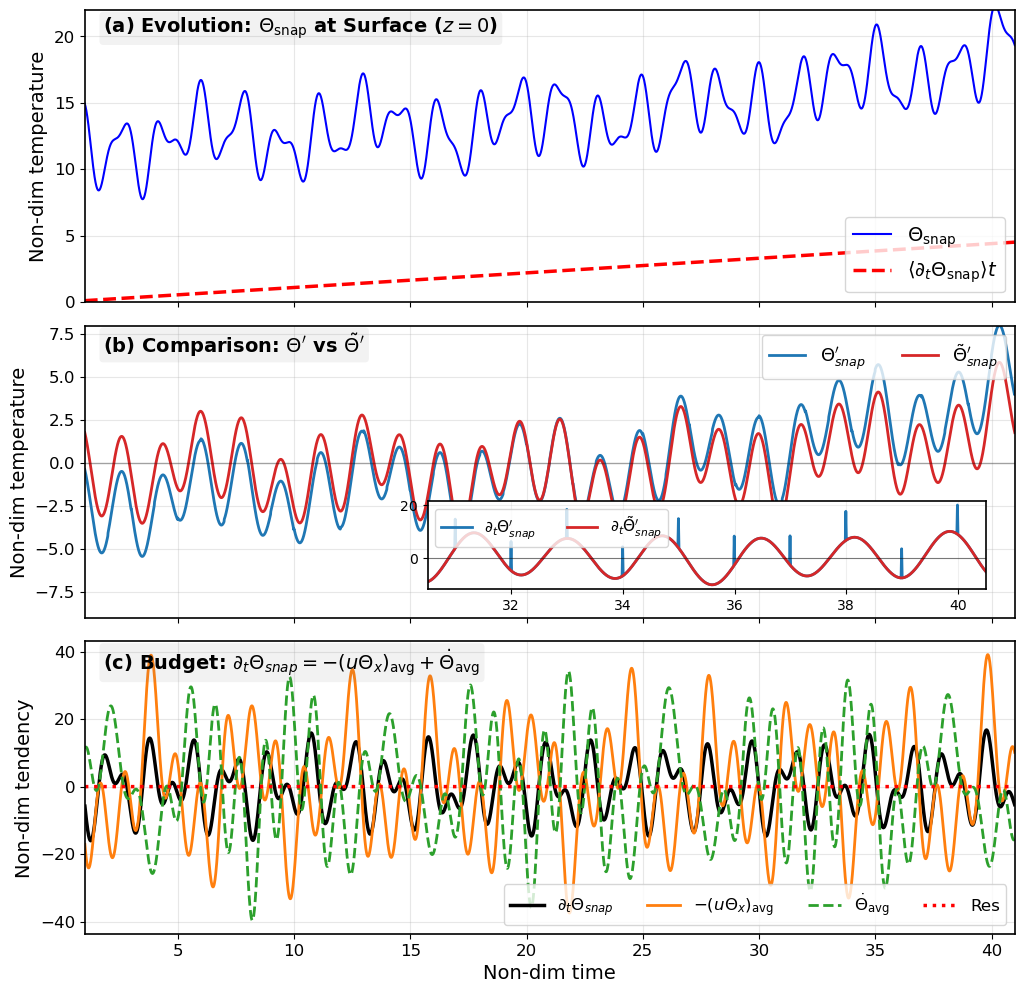

In [37]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl

# ---- JPO 风格 ----
mpl.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.2,
})
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

# =================================================================
# 第二张：时间序列 3×1（原来的 (b)(c)(d)，标号重排成 (a)(b)(c)）
# =================================================================
fig, axs = plt.subplots(3, 1, figsize=(12, 12), sharex=True,
                        gridspec_kw={'hspace': 0.08})

ix, iz = Nx // 2, 0        # 表面中心

titles = [
    r"Evolution: $\Theta_{\mathrm{snap}}$ at Surface ($z=0$)",
    r"Comparison: $\Theta^{\prime}$ vs $\tilde{\Theta}^{\prime}$",
    r"Budget: $\partial_t \Theta_{snap} = -(u \Theta_x)_{\mathrm{avg}} + \dot{\Theta}_{\mathrm{avg}}$",
]

# --- (a) Time Series ---
axs[0].plot(t, T_snap[ix, iz, :], color='b', lw=1.5, label=r'$\Theta_{\mathrm{snap}}$')
axs[0].plot(t, Tanb[ix, iz, :], 'r--', lw=2.5, label=r'$\langle \partial_t \Theta_{\mathrm{snap}} \rangle t$')
axs[0].set_ylabel("Non-dim temperature")
axs[0].legend(loc='lower right', frameon=True)
axs[0].set_ylim(0, 22)

# --- (b) Total Budget Closure ---
dThetadt_snap = (T_snap[:, :, 1:] - T_snap[:, :, :-1]) / dt
axs[2].plot(t_daily, dThetadt_snap[ix, iz, :], 'k', lw=2.5, label=r'$\partial_t \Theta_{snap}$')
axs[2].plot(t_daily, -uTx_avg[ix, iz, :], color='#ff7f0e', lw=2, label=r'$-(u\Theta_x)_{\mathrm{avg}}$')
axs[2].plot(t_daily, Tdot_avg[ix, iz, :], color='#2ca02c', ls='--', lw=2, label=r'$\dot{\Theta}_{\mathrm{avg}}$')
axs[2].plot(t_daily, (dThetadt_snap - (-uTx_avg + Tdot_avg))[ix, iz, :], ':', color='red', lw=2.5, label=r'Res')
axs[2].set_ylabel("Non-dim tendency")
axs[2].legend(loc='lower right', ncol=4, fontsize=12, frameon=True)
axs[2].set_xlabel("Non-dim time")

# --- (c) Comparison with Tendency Inset in Lower Right ---
ax_d = axs[1]
ax_d.plot(t, T_anom[ix, iz, :], color='#1f77b4', lw=2, label=r"$\Theta_{snap}^{\prime}$")
ax_d.plot(t, Twave_anom[ix, iz, :], color='#d62728', lw=2, label=r"$\tilde{\Theta}_{snap}^{\prime}$")
ax_d.axhline(0, color='k', lw=1, alpha=0.3)
ax_d.set_ylabel("Non-dim temperature")
ax_d.legend(loc='upper right', fontsize=13, ncol=4)
ax_d.set_ylim(-9, 8)

# 在右下角创建 Inset 子图，专门画趋势项 (Tendency)
ax_ins = inset_axes(ax_d, width="60%", height="30%", loc=4, borderpad=1.5)
ax_ins.plot(t_daily, dTadt[ix, iz, :], color='#1f77b4', ls='-', lw=2, label=r'$\partial_t \Theta_{snap}^{\prime}$')
ax_ins.plot(t_daily, dTwadt[ix, iz, :], color='#d62728', ls='-', lw=2, label=r'$\partial_t \tilde{\Theta}_{snap}^{\prime}$')
ax_ins.axhline(0, color='k', lw=0.8, alpha=0.5)
ax_ins.legend(loc='upper left', fontsize=11, ncol=2)
ax_ins.set_xlim(30.5, 40.5)
ax_ins.tick_params(labelsize=10)
ax_ins.grid(True, alpha=0.2)

# --- 统一格式调整 ---
letters = ["a", "b", "c"]
for i, ax in enumerate(axs):
    ax.text(0.02, 0.98, f'({letters[i]}) {titles[i]}', transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top', ha='left',
            bbox=dict(boxstyle="round,pad=0.2", facecolor="grey", edgecolor="none", alpha=0.1))
    ax.grid(True, alpha=0.3)
    ax.set_xlim(1, 41)

plt.savefig('fig_theta_timeseries.png', dpi=1000, bbox_inches="tight")
plt.savefig('fig_theta_timeseries.pdf', dpi=1000, bbox_inches="tight")

plt.show()


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


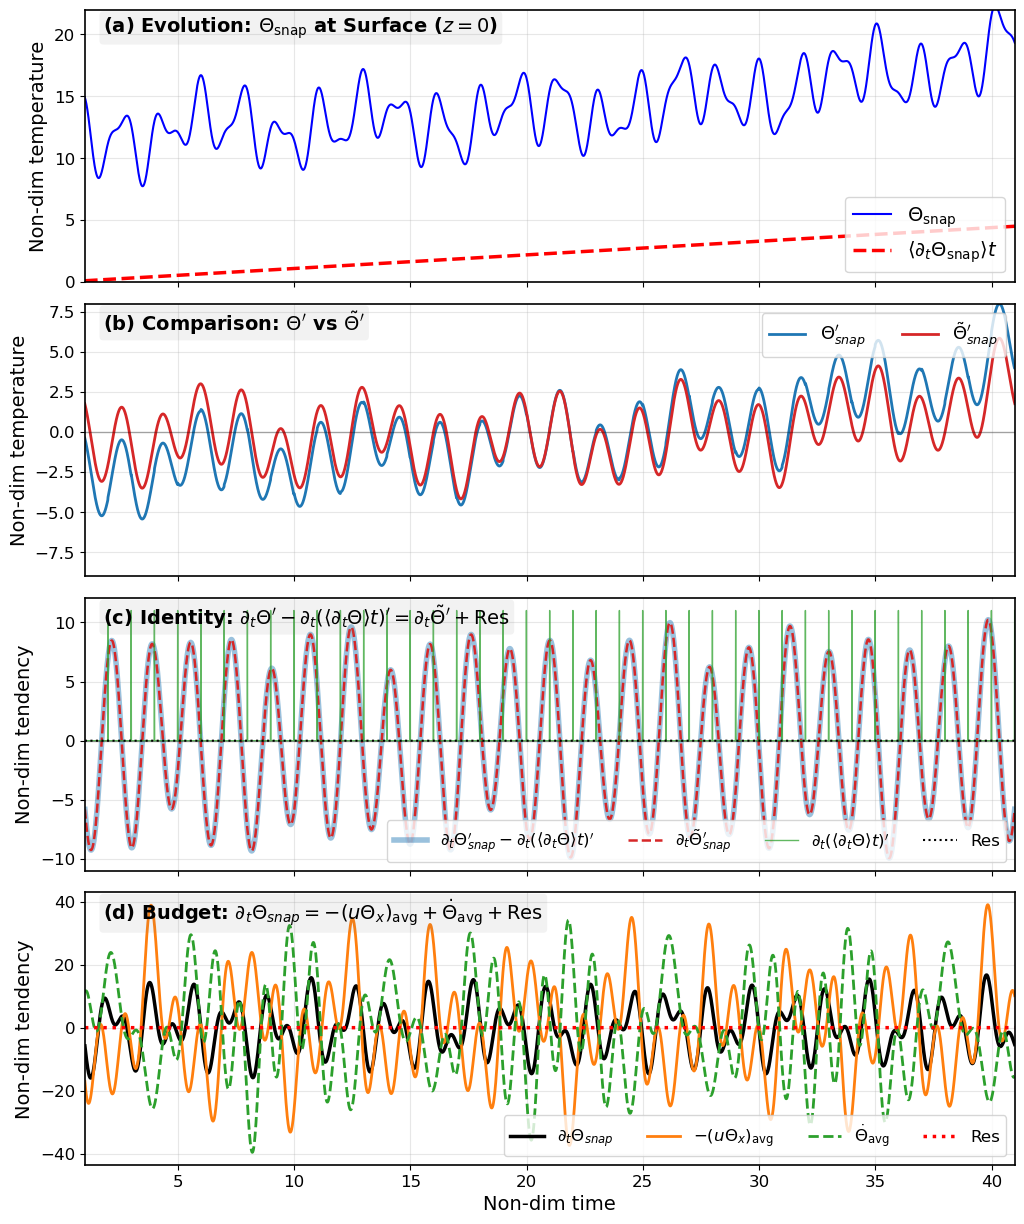

max |Res|            = 1.132e-12
max |rhs|            = 1.023e+01
relative max error   = 1.107e-13


In [11]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

# ---- JPO 风格 ----
mpl.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.2,
})
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

# =================================================================
# 时间序列 4×1
#   (a) Evolution
#   (b) Comparison Θ′ vs Θ̃′            ← 删掉了原来的 inset
#   (c) 恒等式检验：∂Θ′/∂t − ∂(at)′/∂t  ==  ∂Θ̃′/∂t + Res     ← 新增
#   (d) Budget closure                  ← 原来的 (c)
# =================================================================
fig, axs = plt.subplots(4, 1, figsize=(12, 15), sharex=True,
                        gridspec_kw={'hspace': 0.08})

ix, iz = Nx // 2, 0        # 表面中心

titles = [
    r"Evolution: $\Theta_{\mathrm{snap}}$ at Surface ($z=0$)",
    r"Comparison: $\Theta^{\prime}$ vs $\tilde{\Theta}^{\prime}$",
    r"Identity: $\partial_t \Theta^{\prime} - \partial_t (\langle \partial_t \Theta \rangle t)^{\prime} = \partial_t \tilde{\Theta}^{\prime} + \mathrm{Res}$",
    r"Budget: $\partial_t \Theta_{snap} = -(u \Theta_x)_{\mathrm{avg}} + \dot{\Theta}_{\mathrm{avg}} + \mathrm{Res}$",
]

# --- (a) Time Series ---
axs[0].plot(t, T_snap[ix, iz, :], color='b', lw=1.5, label=r'$\Theta_{\mathrm{snap}}$')
axs[0].plot(t, Tanb[ix, iz, :], 'r--', lw=2.5, label=r'$\langle \partial_t \Theta_{\mathrm{snap}} \rangle t$')
axs[0].set_ylabel("Non-dim temperature")
axs[0].legend(loc='lower right', frameon=True)
axs[0].set_ylim(0, 22)

# --- (b) Comparison（inset 已删除）---
axs[1].plot(t, T_anom[ix, iz, :], color='#1f77b4', lw=2, label=r"$\Theta_{snap}^{\prime}$")
axs[1].plot(t, Twave_anom[ix, iz, :], color='#d62728', lw=2, label=r"$\tilde{\Theta}_{snap}^{\prime}$")
axs[1].axhline(0, color='k', lw=1, alpha=0.3)
axs[1].set_ylabel("Non-dim temperature")
axs[1].legend(loc='upper right', fontsize=13, ncol=4)
axs[1].set_ylim(-9, 8)

# --- (c) 新增：两个 tendency 完全重合 ---
#     Θ̃′ = Θ′ − (⟨∂tΘ⟩t)′  ⇒  ∂tΘ′ − ∂t(⟨∂tΘ⟩t)′ 应当逐点等于 ∂tΘ̃′，残差 Res 贴着 0
lhs = (dTadt - dTabadt)[ix, iz, :]
rhs = dTwadt[ix, iz, :]
res = lhs - rhs

# 粗的半透明线在下、细虚线在上 —— 完全重合时会看到虚线正好压在粗线中间
axs[2].plot(t_daily, lhs, color='#1f77b4', lw=4.0, alpha=0.45,
            label=r'$\partial_t \Theta_{snap}^{\prime} - \partial_t (\langle \partial_t \Theta \rangle t)^{\prime}$')
axs[2].plot(t_daily, rhs, color='#d62728', ls='--', lw=1.8,
            label=r'$\partial_t \tilde{\Theta}_{snap}^{\prime}$')
axs[2].plot(t_daily, dTabadt[ix, iz, :], color='#2ca02c', lw=1, alpha=0.75,
            label=r'$\partial_t (\langle \partial_t \Theta \rangle t)^{\prime}$')
axs[2].plot(t_daily, res, color='k', ls=':', lw=1.5,
            label=r'Res')
axs[2].axhline(0, color='k', lw=1, alpha=0.3)
axs[2].set_ylabel("Non-dim tendency")
axs[2].legend(loc='lower right', ncol=4, fontsize=12, frameon=True)

# --- (d) Total Budget Closure（原来的 (c)）---
dThetadt_snap = (T_snap[:, :, 1:] - T_snap[:, :, :-1]) / dt
axs[3].plot(t_daily, dThetadt_snap[ix, iz, :], 'k', lw=2.5, label=r'$\partial_t \Theta_{snap}$')
axs[3].plot(t_daily, -uTx_avg[ix, iz, :], color='#ff7f0e', lw=2, label=r'$-(u\Theta_x)_{\mathrm{avg}}$')
axs[3].plot(t_daily, Tdot_avg[ix, iz, :], color='#2ca02c', ls='--', lw=2, label=r'$\dot{\Theta}_{\mathrm{avg}}$')
axs[3].plot(t_daily, (dThetadt_snap - (-uTx_avg + Tdot_avg))[ix, iz, :], ':', color='red', lw=2.5, label=r'Res')
axs[3].set_ylabel("Non-dim tendency")
axs[3].legend(loc='lower right', ncol=4, fontsize=12, frameon=True)
axs[3].set_xlabel("Non-dim time")

# --- 统一格式调整 ---
letters = ["a", "b", "c", "d"]
for i, ax in enumerate(axs):
    ax.text(0.02, 0.98, f'({letters[i]}) {titles[i]}', transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top', ha='left',
            bbox=dict(boxstyle="round,pad=0.2", facecolor="grey", edgecolor="none", alpha=0.1))
    ax.grid(True, alpha=0.3)
    ax.set_xlim(1, 41)

plt.savefig('fig_theta_timeseries_4panel.png', dpi=1000, bbox_inches="tight")
plt.savefig('fig_theta_timeseries_4panel.pdf', dpi=1000, bbox_inches="tight")

plt.show()

# --- 定量确认 (c) 的两条线确实重合 ---
print("max |Res|            = %.3e" % np.nanmax(np.abs(res)))
print("max |rhs|            = %.3e" % np.nanmax(np.abs(rhs)))
print("relative max error   = %.3e" % (np.nanmax(np.abs(res)) / np.nanmax(np.abs(rhs))))


(1.0, 5.0)

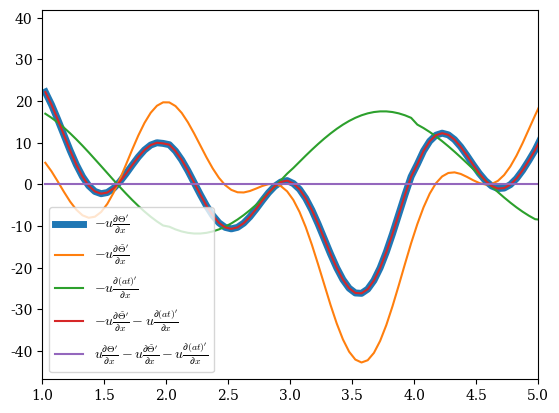

In [48]:
plt.plot(t_daily, uTxanom[100, 10, :], label=r'$-u\frac{\partial{\Theta^{\prime}}}{\partial{x}}$',linewidth=5)
plt.plot(t_daily, uTxwave_anom[100, 10, :], label=r'$-u\frac{\partial{\tilde{\Theta}^{\prime}}}{\partial{x}}$')
plt.plot(t_daily, uTanb1_anom_x[100, 10, :], label= r'$-u\frac{\partial{(at)^{\prime}}}{\partial{x}}$' )
plt.plot(t_daily, (uTanb1_anom_x+uTxwave_anom)[100, 10, :], label= r'$-u\frac{\partial{\tilde{\Theta}^{\prime}}}{\partial{x}}-u\frac{\partial{(at)^{\prime}}}{\partial{x}}$' )
plt.plot(t_daily, (uTanb1_anom_x+uTxwave_anom-uTxanom)[100, 10, :], label= r'$u\frac{\partial{\Theta^{\prime}}}{\partial{x}}-u\frac{\partial{\tilde{\Theta}^{\prime}}}{\partial{x}}-u\frac{\partial{(at)^{\prime}}}{\partial{x}}$' )
plt.legend()
plt.xlim(1,5)

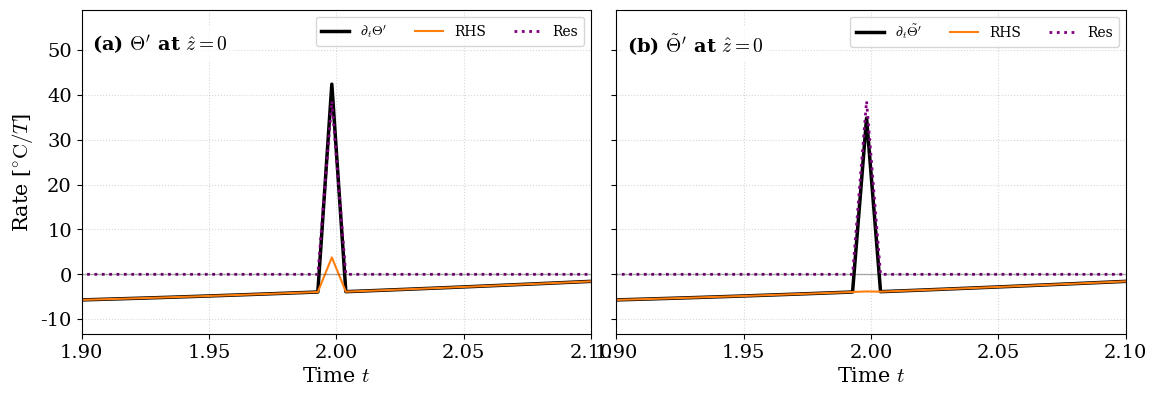

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. 基础参数与风格设置 ---
plt.rcParams.update({
    "mathtext.fontset": "cm", 
    "font.family": "serif",
    "axes.unicode_minus": False,
    "font.size": 14
})

# 关键修改：增加 sharex=True, sharey=True 确保两图刻度完全一致
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True, sharey=True)

# 调整边距，由于共用 y 轴，wspace 可以设小一点
plt.subplots_adjust(left=0.08, right=0.95, top=0.90, bottom=0.18, wspace=0.05)

x_idx = 2
z_idx_surf = 0
letters = "ab"

# --- 2. 循环绘图 ---
for c in range(2):
    ax = axes[c]
    
    # 根据列选择数据
    if c == 0:
        lhs = dTadt[x_idx, z_idx_surf, :]
        rhs = RHS2[x_idx, z_idx_surf, :]
        lhs_label = r'$\partial_t \Theta^{\prime}$'
        title_ts = r"$\Theta^{\prime}$ at $\hat{z}=0$"
    else:
        lhs = dTwadt[x_idx, z_idx_surf, :]
        rhs = RHS[x_idx, z_idx_surf, :]
        lhs_label = r'$\partial_t \tilde{\Theta}^{\prime}$'
        title_ts = r"$\tilde{\Theta}^{\prime}$ at $\hat{z}=0$"
    
    res_val = lhs - rhs

    # 绘制
    ax.plot(t_daily, lhs, label=lhs_label, color='black', lw=2.5)
    ax.plot(t_daily, rhs, label='RHS', color='tab:orange', lw=1.5)
    ax.plot(t_daily, res_val, ':', color='purple', lw=2, label='Res')
    
    # --- 坐标轴优化 ---
    # 删除了固定的 set_xlim(1.5, 4.5)，改为自动适配数据
    # 如果你确定要限制时间范围，请确保数值在 t_daily 范围内，例如：
    # ax.set_xlim(t_daily.min(), t_daily.max()) 
    
    ax.set_xlabel(r'Time $t$', fontsize=15)
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.axhline(0, color='black', lw=1, alpha=0.3)
    
    if c == 0:
        ax.set_ylabel('Rate [$^{\circ}\mathrm{C}/T$]', fontsize=15)
    else:
        # sharey 开启后，右侧图通常不需要重复的 y 轴刻度文字
        ax.tick_params(labelleft=False)
    
    # 标注文本
    ax.text(0.02, 0.93, f"({letters[c]}) {title_ts}", transform=ax.transAxes, 
            fontsize=14, fontweight='bold', va='top', 
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
    
    ax.legend(loc='upper right', fontsize=10, ncol=3, frameon=True)
    ax.set_xlim(1.9,2.1)
    
plt.show()

In [ ]:
#### figure B2 for JPO

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


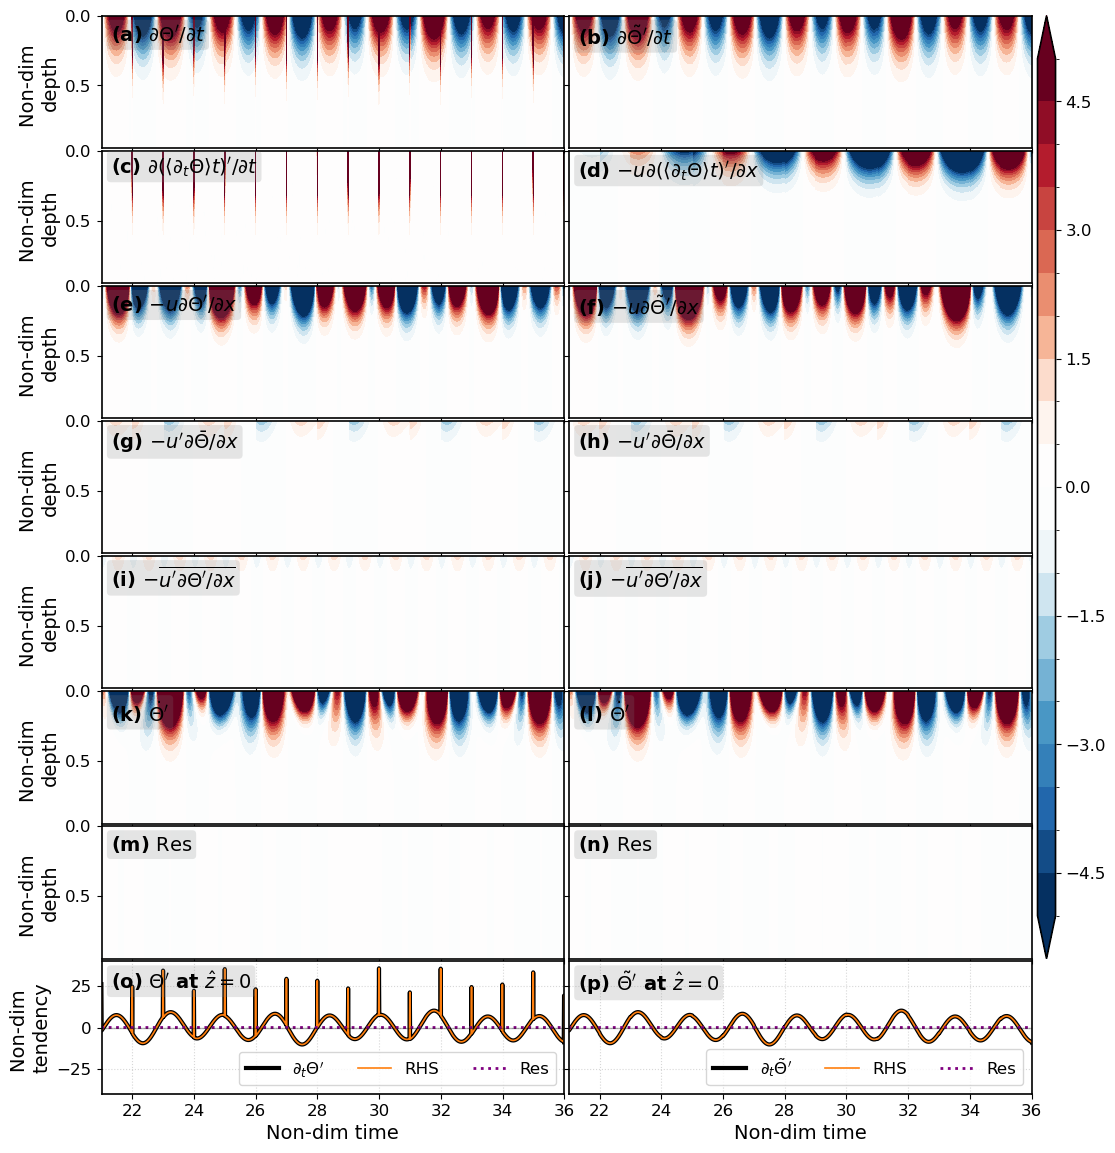

In [34]:
import matplotlib.pyplot as plt
import numpy as np

from matplotlib.colors import TwoSlopeNorm
import matplotlib.colors as mcolors
from matplotlib.colors import BoundaryNorm

levels = np.arange(-5, 5.5, 0.5)

# 在循环外创建一次，让所有子图共享
#norm = TwoSlopeNorm(vmin=-10, vcenter=0, vmax=10)

# 把 RdBu_r 中间附近改成纯白
cmap_base = plt.cm.RdBu_r
colors = cmap_base(np.linspace(0, 1, 256))
# 中间 ±10% 范围（约索引 115~140）渐变到白色
mid = 128
half_white = 50  # 控制白色区域宽度，越大越宽
for i in range(mid - half_white, mid + half_white):
    alpha = 1 - abs(i - mid) / half_white  # 越靠近中心越白
    colors[i, :3] = colors[i, :3] * (1 - alpha) + np.array([1, 1, 1]) * alpha
cmap_white = mcolors.LinearSegmentedColormap.from_list("RdBu_white", colors)

norm = BoundaryNorm(levels, ncolors=cmap_white.N, clip=False)

# --- 1. 基础参数与风格设置 ---
# 假设这些变量已在您的环境中定义，若没有请根据实际数据修改

x_idx = 2
z_idx_surf = 0

#plt.rcParams.update({
#    "mathtext.fontset": "cm", 
#    "font.family": "serif",
#    "axes.unicode_minus": False,
#    "font.size": 14
#})

# ---- JPO 风格 ----
mpl.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.2,
})
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42




# 创建 8行2列 布局
# sharex=True 确保时间轴对齐
fig, axes = plt.subplots(8, 2, figsize=(12, 14), sharex=True)

# 调整子图间距：left/right/top/bottom 决定了内容在画布上的占比
# wspace 为左右子图间距，hspace 为上下子图间距
plt.subplots_adjust( wspace=0.01, hspace=0.02)

# --- 2. 标签与数据列表定义 ---
term_drift = r'$\partial \left( \langle \partial_t \Theta \rangle t \right)^{\prime} / \partial t$'

# 第一列：Full Anomaly (Theta')
col1_hov = [
    (dTadt[x_idx, :, :], r'$\partial \Theta^{\prime} / \partial t$'),
    (dTabadt[x_idx, :, :], term_drift),
    (uTxanom[x_idx, :, :], r'$-u \partial \Theta^{\prime} / \partial x$'),
    (upTxbar[x_idx, :, :], r'$-u^{\prime} \partial \bar{\Theta} / \partial x$'),
    (upTxp_bar[x_idx, :, :], r'$-\overline{u^{\prime} \partial \Theta^{\prime} / \partial x}$'),
    (Tdotdaily_anom[x_idx, :, :], r'$\dot{\Theta}^{\prime}$'),
    (dTadt[x_idx, :, :] - RHS2[x_idx, :, :], r'$\mathrm{Res}$')
]

# 第二列：Wave Anomaly (Theta_tilde')
col2_hov = [
    (dTwadt[x_idx, :, :], r'$\partial \tilde{\Theta}^{\prime} / \partial t$'),
    (uTanb1_anom_x[x_idx, :, :], r'$-u \partial (\langle \partial_t \Theta \rangle t)^{\prime} / \partial x$'),
    (uTxwave_anom[x_idx, :, :], r'$-u \partial \tilde{\Theta}^{\prime} / \partial x$'),
    (upTxbar[x_idx, :, :], r'$-u^{\prime} \partial \bar{\Theta} / \partial x$'),
    (upTxp_bar[x_idx, :, :], r'$-\overline{u^{\prime} \partial \Theta^{\prime} / \partial x}$'),
    (Tdotdaily_anom[x_idx, :, :], r'$\dot{\Theta}^{\prime}$'),
    (dTwadt[x_idx, :, :] - RHS[x_idx, :, :], r'$\mathrm{Res}$')
]

# --- 3. 循环绘图 (1-7行: Hovmöller 图) ---
letters = "abcdefghijklmnopqr"
idx = 0

for r in range(7):
    for c in range(2):
        ax = axes[r, c]
        data, label_text = col1_hov[r] if c == 0 else col2_hov[r]
        
        # 绘制等值线填充图
        im = ax.contourf(t_daily, z_norm, data, levels=levels, cmap=cmap_white, norm=norm, extend='both')
        
        ax.set_xlim(21, 36)
        ax.set_ylim(0, 0.95)
        ax.invert_yaxis() 
        
        # 标注文本 (根据行列微调位置)
        y_pos = 0.94 if not (r == 1 and c == 0) else 0.97
        full_label = f"({letters[idx]}) {label_text}"
        ax.text(0.02, y_pos, full_label, transform=ax.transAxes, 
                fontsize=14, fontweight='bold', va='top', 
            bbox=dict(boxstyle="round,pad=0.2", facecolor="grey", edgecolor="none", alpha=0.2))
        
        if c == 0:
            ax.set_ylabel("Non-dim \ndepth", multialignment='center')
        else:
            ax.tick_params(labelleft=False) 
            
        idx += 1

# --- 4. 绘制第 8 行: 时间序列 ---
ts_items_col1 = [
    (dTadt[x_idx, z_idx_surf, :], r'$\partial_t \Theta^{\prime}$', 'black', 3.0),
    (RHS2[x_idx, z_idx_surf, :], 'RHS', 'tab:orange', 1.2),
]

ts_items_col2 = [
    (dTwadt[x_idx, z_idx_surf, :], r'$\partial_t \tilde{\Theta}^{\prime}$', 'black', 3.0),
    (RHS[x_idx, z_idx_surf, :], 'RHS', 'tab:orange', 1.2),
]

for c in range(2):
    ax = axes[7, c]
    ts_items = ts_items_col1 if c == 0 else ts_items_col2
    for data, label, color, lw in ts_items:
        ax.plot(t_daily, data, label=label, color=color, lw=lw)
    
    # 残差计算与绘制
    res_val = (dTadt[x_idx, z_idx_surf, :] - RHS2[x_idx, z_idx_surf, :]) if c == 0 else \
              (dTwadt[x_idx, z_idx_surf, :] - RHS[x_idx, z_idx_surf, :])
    ax.plot(t_daily, res_val, ':', color='purple', lw=2, label='Res')
    
    ax.set_xlim(21, 36)
    ax.set_xlabel("Non-dim time", fontsize=14)
    ax.set_ylim(-40, 40)

    if c == 0:
        ax.set_ylabel('Non-dim \ntendency', multialignment='center')
    else:
        ax.tick_params(labelleft=False)
    
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.axhline(0, color='black', lw=1, alpha=0.3)
    
    title_ts = r"$\Theta^{\prime}$ at $\hat{z}=0$" if c == 0 else r"$\tilde{\Theta}^{\prime}$ at $\hat{z}=0$"
    ax.text(0.02, 0.94, f"({letters[idx]}) {title_ts}", transform=ax.transAxes, 
            fontsize=14, fontweight='bold', va='top', 
            bbox=dict(boxstyle="round,pad=0.2", facecolor="grey", edgecolor="none", alpha=0.2))
    
    ax.legend(loc='lower right', fontsize=12, ncol=3, frameon=True)
    idx += 1

# --- 5. 全局 Colorbar 布局优化 ---
# 明确获取第 1 行和第 7 行的物理位置
pos_top = axes[0, 1].get_position()
pos_bottom = axes[6, 1].get_position()

# 手动添加坐标轴给 Colorbar：[left, bottom, width, height]
# 设置在子图右侧 0.02 处，宽度为 0.015
cbar_ax = fig.add_axes([pos_top.x1 + 0.005, pos_bottom.y0, 0.015, pos_top.y1 - pos_bottom.y0])
cb = fig.colorbar(im, cax=cbar_ax, orientation='vertical', extend='both')
#cb.set_label(r'Tendency ($^{\circ}\mathrm{C}/T$)', fontsize=12)

# --- 6. 保存设置 ---
# 使用 bbox_inches='tight' 自动裁剪掉画布边缘多余的空白
# pad_inches=0.02 进一步压缩图形到图片边缘的距离

plt.savefig('fig_HeatBudget_Comparison_Optimized_cmapwhite.png', dpi=1000, bbox_inches='tight', pad_inches=0.05)
plt.savefig('fig_HeatBudget_Comparison_Optimized_cmapwhite.pdf', dpi=1000, bbox_inches='tight')

plt.show()

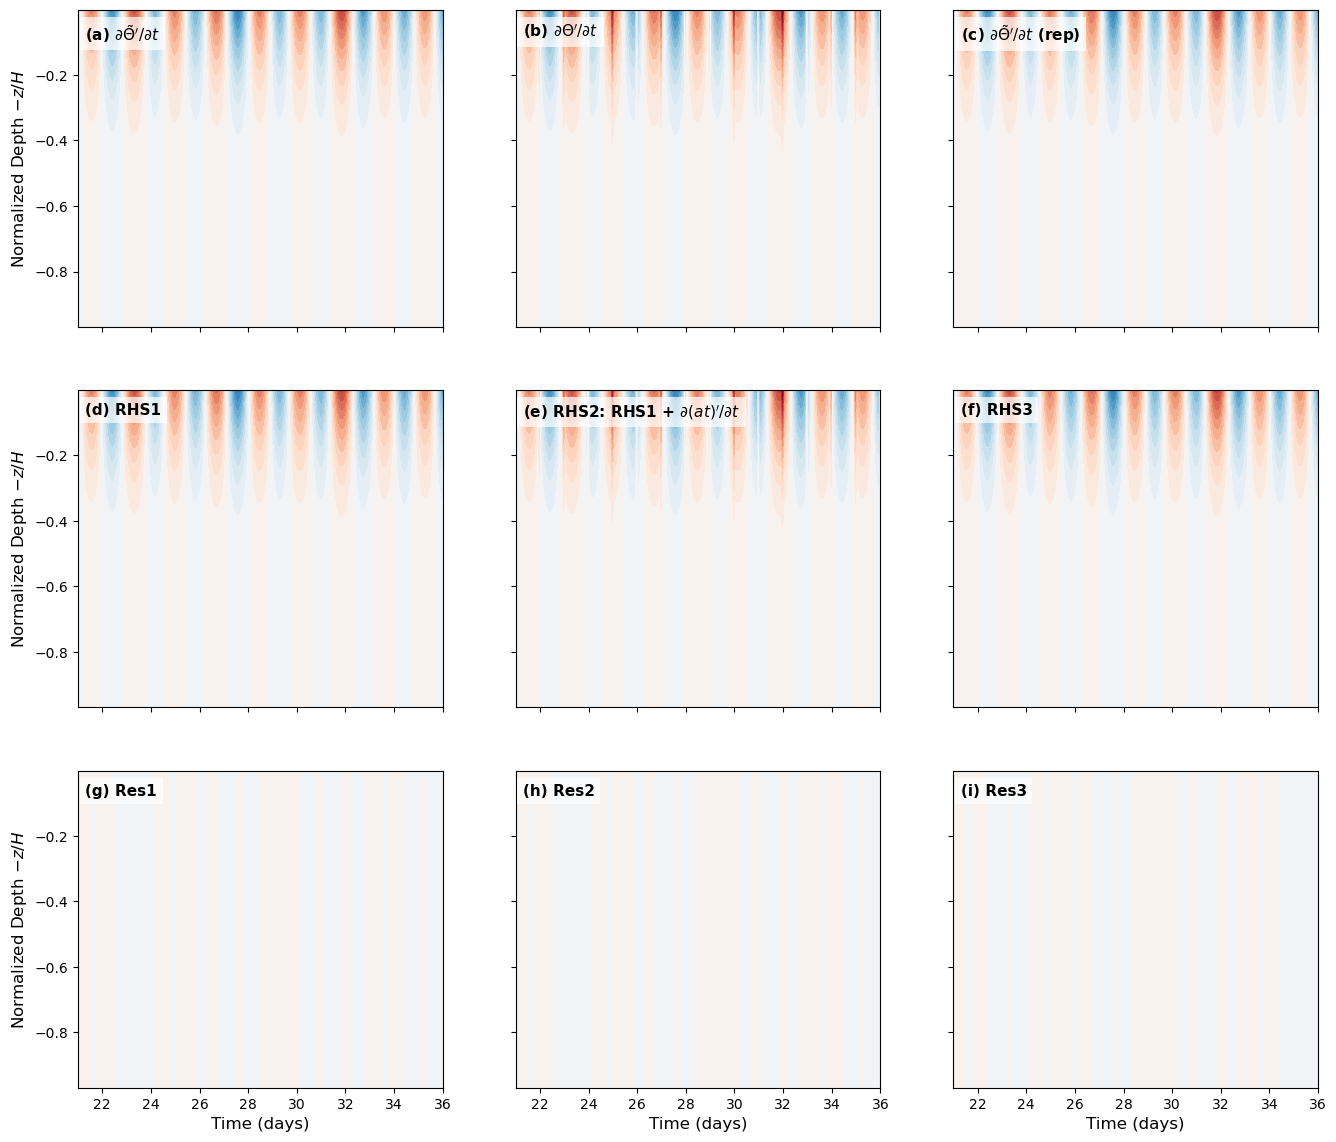

In [37]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. 数据准备 ---
x_idx = 200 

# 定义 3x3 的布局逻辑
# 第一列：趋势 1 系列 (dTwadt, RHS1, Res1)
# 第二列：趋势 2 系列 (dTadt, RHS2, Res2)
# 第三列：趋势 3 系列 (dTwadt, RHS3, Res3) - 示例新增
plot_grid = [
    [
        (dTwadt[x_idx, :, :], r'$\partial{\tilde{\Theta}^{\prime}}/\partial{t}$'), 
        (dTadt[x_idx, :, :], r'$\partial{\Theta^{\prime}}/\partial{t}$'),
        (dTwadt[x_idx, :, :], r'$\partial{\tilde{\Theta}^{\prime}}/\partial{t}$ (rep)')
    ],
    [
        (RHS[x_idx, :, :], r'RHS1'), 
        (RHS2[x_idx, :, :], r'RHS2: RHS1 + $\partial(at)^{\prime}/\partial t$'),
        (RHS3[x_idx, :, :], r'RHS3')
    ],
    [
        (dTwadt[x_idx, :, :] - RHS[x_idx, :, :], 'Res1'), 
        (dTadt[x_idx, :, :] - RHS2[x_idx, :, :], 'Res2'),
        (dTwadt[x_idx, :, :] - RHS3[x_idx, :, :], 'Res3')
    ]
]

# 对应面板标签
panel_labels = [
    ['(a)', '(b)', '(c)'],
    ['(d)', '(e)', '(f)'],
    ['(g)', '(h)', '(i)']
]

# --- 2. 统一颜色刻度 ---
# 将所有需要对比的数据放入列表计算最大绝对值
all_compare_data = [
    dTwadt[x_idx,:,:], RHS[x_idx,:,:], dTadt[x_idx,:,:], 
    RHS2[x_idx,:,:], RHS3[x_idx,:,:],
    dTwadt[x_idx,:,:] - RHS[x_idx,:,:], 
    dTadt[x_idx,:,:] - RHS2[x_idx,:,:]
]
vmax = np.nanmax(np.abs(all_compare_data))
levels = np.linspace(-vmax, vmax, 31)

# --- 3. 绘图 (3行3列) ---
fig, axes = plt.subplots(3, 3, figsize=(16, 14), sharex=True, sharey=True)

for r in range(3):
    for c in range(3):
        ax = axes[r, c]
        data, title = plot_grid[r][c]
        
        # 绘图
        im = ax.contourf(t_daily, -z_norm, data, levels=levels, cmap='RdBu_r', extend='both')
        
        # 图内标注
        full_label = f"{panel_labels[r][c]} {title}"
        ax.text(0.02, 0.96, full_label, transform=ax.transAxes, 
                fontsize=11, fontweight='bold', verticalalignment='top',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')) # 增加微弱背景增强可读性
        
        ax.set_xlim(21, 36)
        
        # 坐标轴标签处理
        if r == 2: 
            ax.set_xlabel('Time (days)', fontsize=12)
        if c == 0: 
            ax.set_ylabel('Normalized Depth $-z/H$', fontsize=12)

# --- 4. 优化布局与 Colorbar ---
#

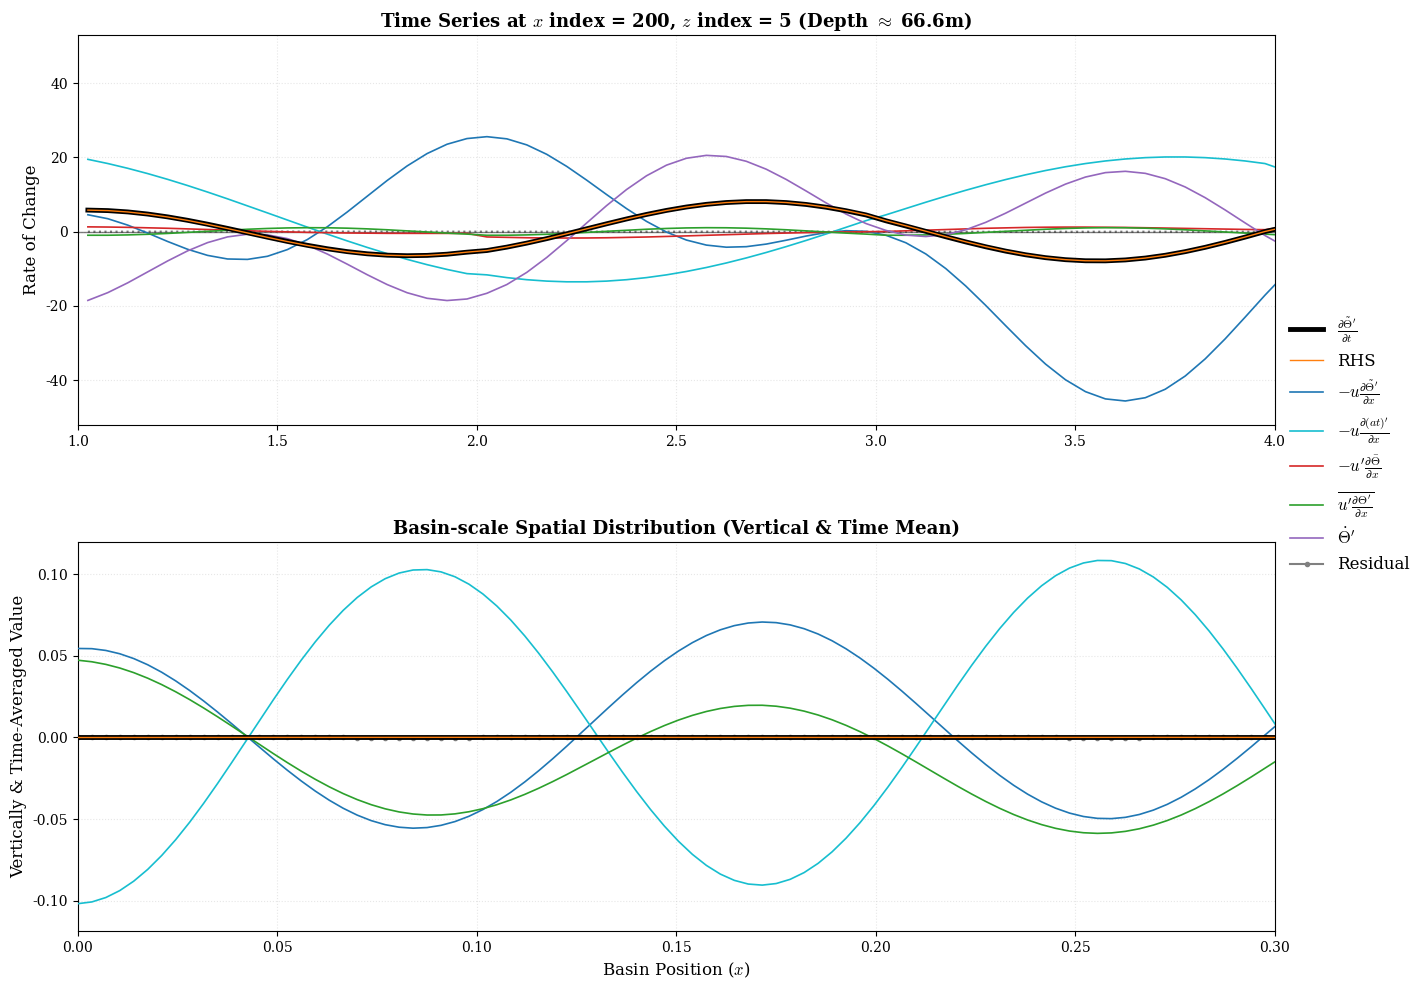

In [49]:
import matplotlib.pyplot as plt
import numpy as np

# 设置全局物理公式字体
plt.rcParams.update({
    "mathtext.fontset": "cm",
    "font.family": "serif"
})

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

# --- 3D 索引设置 ---
x_idx = 200  
z_idx = 5    # 选择一个深度索引 (例如浅层，波动最明显)

# 定义物理项列表 (针对 3D 数据 Nx, Nz, Nt)
# 这里假设你的数据已经计算好，形状为 (Nx, Nz, Nt_daily)
items = [
    (dTwadt, r'$\frac{\partial{\tilde{\Theta}^{\prime}}}{\partial{t}}$', 'black', 3.5, 9),
#    (dTadt, r'$\frac{\partial{\Theta^{\prime}}}{\partial{t}}$', 'grey', 1.5, 9),
    (RHS3, 'RHS', 'tab:orange', 1, 9),
    (uTxwave_anom, r'$-u\frac{\partial{\tilde{\Theta}^{\prime}}}{\partial{x}}$', 'tab:blue', 1.2, 5),
    (uTanb1_anom_x, r'$-u\frac{\partial{(at)^{\prime}}}{\partial{x}}$', 'tab:cyan', 1.2, 5),

    (upTxbar, r'$-u^{\prime}\frac{\partial{\bar{\Theta}}}{\partial{x}}$', 'tab:red', 1.2, 5),
    (upTxp_bar, r'$\overline{u^{\prime}\frac{\partial{\Theta^{\prime}}}{\partial{x}}}$', 'tab:green', 1.2, 5),
    (Tdotdaily_anom, r'$\dot{\Theta}^{\prime}$', 'tab:purple', 1.2, 5),
]

# --- 子图 1: 时间序列 (固定在 x_idx, z_idx) ---
for data, label, color, lw, zo in items:
    # 提取特定格点的 1D 时间序列: data[x_idx, z_idx, :]
    ax1.plot(t_daily, data[x_idx, z_idx, :], label=label, color=color, lw=lw, zorder=zo)

# 残差计算 (注意维度匹配)
residual_ts = (dTwadt - RHS)[x_idx, z_idx, :]
ax1.plot(t_daily, residual_ts, color='grey', linestyle=':', alpha=1, label='Residual')

ax1.set_xlim(1, 4) 
ax1.set_ylabel('Rate of Change', fontsize=12)
ax1.set_title(f'Time Series at $x$ index = {x_idx}, $z$ index = {z_idx} (Depth $\\approx$ {z_coords[z_idx]:.1f}m)', fontsize=13, fontweight='bold')
ax1.grid(True, linestyle=':', alpha=0.3)
ax1.axhline(0, color='black', lw=1, alpha=0.5)

# --- 子图 2: 空间分布 (时间平均量 ⟨·⟩ 沿 x 轴) ---
# 在 3D 中，通常对时间 (axis=2) 取平均，并对垂直维度 (axis=1) 取平均以看海盆整体情况
# 如果你想看特定深度，可以改为 spatial_data = np.mean(data[:, z_idx, :], axis=1)

for data, label, color, lw, zo in items:
    # 1. 对时间轴 (axis=2) 取平均 -> 得到 (Nx, Nz)
    # 2. 对垂直轴 (axis=1) 取平均 -> 得到 (Nx,)
    spatial_mean = np.mean(np.mean(data, axis=2), axis=1)
    ax2.plot(x, spatial_mean, label=label, color=color, lw=lw, zorder=zo)

# 空间残差
res_spatial = np.mean(np.mean(dTwadt - RHS3, axis=2), axis=1)
ax2.plot(x, res_spatial, color='grey', marker='.', alpha=1, label='Residual')

#res_spatial2 = np.mean(np.mean(dTadt - RHS, axis=2), axis=1)
#ax2.plot(x, res_spatial2, color='k', marker='*', alpha=1, label='Residual - old')

ax2.set_ylabel('Vertically & Time-Averaged Value', fontsize=12)
ax2.set_xlabel('Basin Position ($x$)', fontsize=12)
ax2.set_title(r'Basin-scale Spatial Distribution (Vertical & Time Mean)', fontsize=13, fontweight='bold')
ax2.grid(True, linestyle=':', alpha=0.3)
ax2.axhline(0, color='black', lw=1, alpha=0.5)
ax2.set_xlim(0,0.3)

# 图例统一放置
ax2.legend(fontsize=12, loc='center left', bbox_to_anchor=(1, 1.25), frameon=False)

plt.tight_layout()
plt.subplots_adjust(right=0.8, hspace=0.3) 
plt.show()